# RBF training

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from scipy.spatial import distance_matrix
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
from scipy.optimize import minimize
from scipy.interpolate import RBFInterpolator
from scipy.interpolate import LinearNDInterpolator
from scipy.optimize import differential_evolution, minimize, NonlinearConstraint, Bounds
import pandas as pd
from numpy.linalg import solve, LinAlgError

# Load data (example)
ethanol_conversion_factor = 90.4
ton_to_kg = 1000
gal_to_MMgal = 1e6
a = 11.07



## Dividing cost and size training

In [3]:
N_rand = 500_000
N_farms = 100

Limit_refineries = 500_000
Limit_farms = 100

ethanol_conversion_factor = 90.4
ton_to_kg = 1000
gal_to_MMgal = 1e6
a = 11.07


inputs = np.load("inputs_rand_500k_Rs_2perc.npy", allow_pickle=True).T[:Limit_refineries]
# costs_load = np.load("Costs_biorefinery_500k_Rs_2perc.npy")[:Limit_refineries, :Limit_farms]
# yields_load = np.load("production_biorefineries_farm_sample_500k_Rs_2perc.npy")[:Limit_refineries, :Limit_farms]
costs_load = np.load("Costs_biorefinery_500k_Rs_2perc.npy")[:Limit_refineries, :Limit_farms]
yields_load = np.load("production_biorefineries_farm_sample_500k_Rs_2perc.npy")[:Limit_refineries, :Limit_farms]
areas_input = np.load("areas_rand_500k_Rs_2perc.npy")

costs_mean = np.mean(costs_load, axis = 1)
production_mean = np.mean(yields_load, axis = 1)

In [4]:
y1_total = costs_mean  # Total costs in $/yr 
y2_total = production_mean # total production in tons/yr

/var/folders/fg/n4ts742d2ls_47tpj0bp79yh0000gp/T/ipykernel_62231/1143312251.py:4: RuntimeWarning: divide by zero encountered in divide
  plt.scatter(inputs[mask_1][:,0],inputs[mask_1][:,1],c=(y1_total/y2_total)[mask_1],alpha = 0.2, vmax = 200)


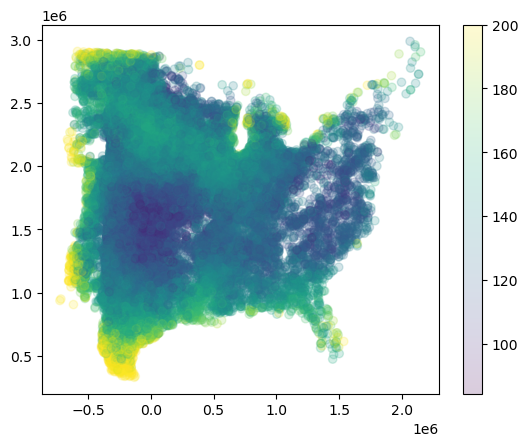

In [5]:
mean_r = np.mean(inputs[:,2:],axis = 1)
mask_1 = np.arange(len(mean_r))<40000#np.abs(mean_r-150000)<5000
# plt.scatter(inputs[mask_1][:,0],inputs[mask_1][:,1],c=(y2_total/areas_input)[mask_1],alpha = 0.2)
plt.scatter(inputs[mask_1][:,0],inputs[mask_1][:,1],c=(y1_total/y2_total)[mask_1],alpha = 0.2, vmax = 200)
plt.colorbar()

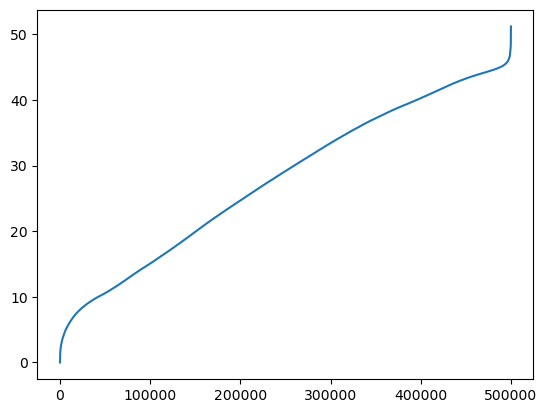

In [6]:
plt.plot(np.sort(y2_total/areas_input))

In [7]:
# 1. Basic Masking
mask = (~np.any(np.isnan(inputs), axis=1)) & (~np.isnan(y1_total)) & (~np.isnan(y2_total)) # & (y1_total > 0) & (y2_total > 0)
X = inputs[mask]
y1_total_clean = y1_total[mask]
y2_total_clean = y2_total[mask]

# 2. Feature Normalization (X stays the same for both)
X_min, X_max = X.min(axis=0), X.max(axis=0)
Xn = (X - X_min) / (X_max - X_min)

# 3. Separate Target Normalization
# We store mins/maxes individually to use during the inversion in the optimization loop
y1_input = y1_total_clean/areas_input[mask]
y2_input = y2_total_clean/areas_input[mask]

y1_min, y1_max = y1_input.min(), y1_input.max()
y2_min, y2_max = y2_input.min(), y2_input.max()

yn1 = (y1_max - y1_input) / (y1_max - y1_min)
yn2 = (y2_input - y2_min) / (y2_max - y2_min)


# 4. Train/Test/Val Split
# We split Xn, yn1, and yn2 simultaneously to keep indices synced
# Using a combined yn for the split simplifies the code
yn_combined = np.vstack([yn1, yn2]).T
y_real_combined = np.vstack([y1_total_clean, y2_total_clean]).T

# First split: 90% Train, 10% Temp
Xn_train, Xn_temp, yn_train, yn_temp, y_train, y_temp, areas_train, areas_temp  = train_test_split(
    Xn, yn_combined, y_real_combined, areas_input[mask],
    test_size=0.1,
    random_state=42
)

# Second split: 90% Val, 10% Test (of the 10% temp)
Xn_val, Xn_test, yn_val, yn_test, y_val, y_test, areas_val, areas_test = train_test_split(
    Xn_temp, yn_temp, y_temp, areas_temp,
    test_size=0.1,
    random_state=42
)

# Extract 1D targets for Model 1 (Costs) and Model 2 (Size)
yn1_train, yn2_train = yn_train[:, 0], yn_train[:, 1]
yn1_val, yn2_val     = yn_val[:, 0], yn_val[:, 1]
y1_val_real, y2_val_real = y_val[:, 0], y_val[:, 1]


In [31]:

def gaussian_rbf(r, epsilon):
    return np.exp(-(epsilon * r)**2)
class GaussianRBFInterpolator:
    def __init__(
        self,
        X,
        y,
        epsilon=1.0,
        smoothing=0.0,
        neighbors=30
    ):
        """
        X : (N, d) array of training points
        y : (N,) array of targets
        """
        self.X = np.asarray(X, dtype=float)
        self.y = np.asarray(y, dtype=float)
        self.epsilon = float(epsilon)
        self.smoothing = float(smoothing)
        self.neighbors = int(neighbors)

        self.tree = cKDTree(self.X)
    def _local_weights(self, Xn, yn):
        """Solve local RBF system"""
        dists = np.linalg.norm(Xn[:, None, :] - Xn[None, :, :], axis=2)
        K = gaussian_rbf(dists, self.epsilon)

        if self.smoothing > 0:
            K += self.smoothing * np.eye(len(Xn))

        try:
            return solve(K, yn)
        except LinAlgError:
            return np.zeros(len(yn))
    def predict(self, Xq):
        Xq = np.atleast_2d(Xq)
        y_pred = np.zeros(len(Xq))

        for i, x in enumerate(Xq):
            # 1. Find nearest neighbors
            dists, idx = self.tree.query(x, k=self.neighbors)

            Xn = self.X[idx]
            yn = self.y[idx]

            # 2. Solve local RBF system
            w = self._local_weights(Xn, yn)

            # 3. Evaluate RBF at query point
            r = np.linalg.norm(Xn - x, axis=1)
            phi = gaussian_rbf(r, self.epsilon)

            y_pred[i] = np.dot(w, phi)

        return y_pred
    __call__ = predict

In [8]:
## New faster version
import numpy as np
from scipy.spatial import cKDTree
from scipy.linalg import cho_factor, cho_solve


class GaussianRBFInterpolator_new:
    def __init__(self, X, y, epsilon=1.0, smoothing=0.0, neighbors=30):
        self.X = np.asarray(X, dtype=float)
        self.y = np.asarray(y, dtype=float)
        self.epsilon = float(epsilon)
        self.smoothing = float(smoothing)
        self.neighbors = int(neighbors)

        self.tree = cKDTree(self.X)

        N, d = self.X.shape
        k = self.neighbors

        # Precompute neighbors for each training point
        _, self.neigh_idx = self.tree.query(self.X, k=k)

        # Store weights only (small: N x k)
        self.weights = np.zeros((N, k), dtype=np.float32)

        eye_k = np.eye(k)

        for i in range(N):
            idx = self.neigh_idx[i]
            Xi = self.X[idx]
            yi = self.y[idx]

            # Build local kernel matrix (k x k)
            diffs = Xi[:, None, :] - Xi[None, :, :]
            dist_sq = np.sum(diffs**2, axis=-1)

            K = np.exp(-(self.epsilon**2) * dist_sq)

            if self.smoothing > 0:
                K += self.smoothing * eye_k

            try:
                c, low = cho_factor(K, overwrite_a=True, check_finite=False)
                self.weights[i] = cho_solve((c, low), yi, check_finite=False)
            except np.linalg.LinAlgError:
                self.weights[i] = 0.0


    # -------------------------------------------------------------
    # FAST prediction: NO linear solves
    # -------------------------------------------------------------
    def predict(self, Xq):
        Xq = np.atleast_2d(Xq)

        # Find nearest training center for each query
        _, center_idx = self.tree.query(Xq, k=1)

        neigh = self.neigh_idx[center_idx]     # (Nq, k)
        Xn = self.X[neigh]                     # (Nq, k, d)
        w = self.weights[center_idx]           # (Nq, k)

        # Kernel between query and neighbors
        diff = Xq[:, None, :] - Xn
        dist_sq = np.sum(diff**2, axis=-1)
        phi = np.exp(-(self.epsilon**2) * dist_sq)

        return np.sum(w * phi, axis=1)

    __call__ = predict


In [9]:

def train_rbf_model(target_idx, name,sm = 1e-3):
    # 1. Cap the data for optimization to save memory
    # Only use up to 2000 points for the 'search' phase
    max_opt_points = 3000 
    if len(Xn_train) > max_opt_points:
        idx = np.random.choice(len(Xn_train), max_opt_points, replace=False)
        X_opt = Xn_train[idx]
        y_opt = yn_train[idx, target_idx]
    else:
        X_opt = Xn_train
        y_opt = yn_train[:, target_idx]

    y_val_real = y_val[:, target_idx]
    # bounds = [(-4, 3), (-12, -2), (-3, 3)] 
    # bounds = [(-6, 0), (-12, -2), (-3, 3)] 
    bounds = [(-3, 0), (-4, 0)] 
    def objective(params):
        # log_h, log_sm, log_r = params
        log_h, log_r = params
        # h, sm, r = 10**log_h, 10**log_sm, 10**log_r
        h, r = 10**log_h, 10**log_r
        scale_vec = np.array([1.0, 1.0, r, r, r, r])
        try:
            # 2. Use a fixed number of neighbors to limit matrix size
            # rbf = RBFInterpolator(
            #     X_opt * scale_vec, y_opt,
            #     kernel='gaussian', epsilon=h, smoothing=sm, 
            #     neighbors=30  # Optimized for memory/smoothness balance
            # )

            rbf = GaussianRBFInterpolator_new(
                    Xn_train * scale_vec, y_opt,
                    epsilon=1/h**2, smoothing=sm,
                    neighbors=50 # 50 instead of 100
                )
            
            yn_pred = rbf(Xn_val * scale_vec)
            if target_idx == 0:
                y_pred = y1_max - yn_pred * (y1_max - y1_min)

            elif target_idx ==1:
                y_pred = (y2_max - y2_min) *yn_pred + y2_min
            
            # error = np.mean(np.abs(y_pred / y_val_real - 1))
            # error = np.mean((y_pred / y_val_real - 1)**2) # RMSE approach
            error = np.mean((y_pred - y_val_real)**2) # RMSE
            return error if np.isfinite(error) else 1e6
        except MemoryError:
            return 1e6 # Tell the optimizer this area is "too expensive"
        except:
            return 1e6

    print(f"Optimizing Model for: {name}...")
    result = differential_evolution(
        objective, bounds, strategy='best1bin', 
        maxiter=100, popsize=15, seed=123
        # maxiter=50, popsize=15, seed=123
    )
    
    # best_h, best_sm, best_r = 10**result.x
    best_h, best_r = 10**result.x
    best_scale = np.array([1.0, 1.0, best_r, best_r, best_r, best_r])
    
    print(best_h, best_r)
    
    # 3. Final model uses all data but keeps neighbor limit to prevent crash
    # final_model = RBFInterpolator(
    #     Xn_train * best_scale, yn_train[:, target_idx],
    #     kernel='gaussian', epsilon=best_h, smoothing=best_sm,
    #     neighbors=50 
    # )

    final_model = GaussianRBFInterpolator_new(
        Xn_train * best_scale, yn_train[:, target_idx],
        epsilon=1/best_h**2, smoothing=sm,
        neighbors=80 # 80 instead of 100
    )
    
    return final_model, best_scale

In [10]:
%%time
# Train the two models

model_costs_total, scale_costs_total = train_rbf_model(0, "Feedstock Costs",sm=3e-3)
model_size_total, scale_size_total = train_rbf_model(1, "Refinery Size",sm=3e-3)

Optimizing Model for: Feedstock Costs...
0.166740055969875 0.002313825994548632
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Optimizing Model for: Refinery Size...
0.166740055969875 0.002313825994548632
CPU times: user 29min 32s, sys: 1.3 s, total: 29min 33s
Wall time: 49min 43s


In [637]:
import pickle
import os

# 1. Create the directory if it doesn't exist
folder_name = "RBF_models"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)
    print(f"Directory '{folder_name}' created.")

## SAVE MODEL
# Create a dictionary containing the models and the normalization constants
model_package = {
    "costs": {
        "model": model_costs_total,
        "scale": scale_costs_total,
        "y_min": y1_min,
        "y_max": y1_max
    },
    "size": {
        "model": model_size_total,
        "scale": scale_size_total,
        "y_min": y2_min,
        "y_max": y2_max
    },
    "X_min": X_min, 
    "X_max": X_max
}

# 2. Define the full path
file_path = os.path.join(folder_name, "rbf_models_package_total_2perc.pkl")

# 3. Save to the file
with open(file_path, "wb") as f:
    pickle.dump(model_package, f)

print(f"Models and scaling parameters saved successfully to '{file_path}'")

Models and scaling parameters saved successfully to 'RBF_models/rbf_models_package_total_2perc.pkl'


In [12]:
import pickle
import numpy as np

# Load the package
with open("../rbf_models/rbf_models_package_total_2perc.pkl", "rb") as f:
    loaded_data = pickle.load(f)

# Extract Cost model data
model_costs_total = loaded_data["costs"]["model"]
scale_costs_total = loaded_data["costs"]["scale"]
y1_min= loaded_data["costs"]["y_min"]
y1_max = loaded_data["costs"]["y_max"]

# Extract Size model data
model_size_total = loaded_data["size"]["model"]
scale_size_total = loaded_data["size"]["scale"]
y2_min = loaded_data["size"]["y_min"]
y2_max = loaded_data["size"]["y_max"]

X_min = loaded_data["X_min"]
X_max = loaded_data["X_max"]

print("Models loaded and ready for prediction.")

Models loaded and ready for prediction.


In [13]:
def predict_batch_rbf_costs(X_norm_batch, rbf_model, scale_vec, y_min, y_max):
    X_scaled = X_norm_batch * scale_vec
    yn_pred = rbf_model(X_scaled)
    
    # 1. Back-transform from Normalized to Log space
    y_pred = y_max - yn_pred * (y_max - y_min)
    y_real = np.maximum(y_pred, y_min)
    
    return y_real
    
def predict_batch_rbf_size(X_norm_batch, rbf_model, scale_vec, y_min, y_max):
    X_scaled = X_norm_batch * scale_vec
    yn_pred = rbf_model(X_scaled)
    # 1. Back-transform from Normalized to Log space
    y_pred = y_min + yn_pred * (y_max - y_min)
    y_real = np.maximum(y_pred, y_min)
    
    return y_real


In [14]:
def evaluate_model(model, scale_vec, X_norm, y_real, target_y_min, target_y_max, name):
    # 1. Predict in the normalized space
    yn_pred = model(X_norm * scale_vec)
    
    # 2. Invert normalization to get real units
    # Matches: yn = 1.0 - (log_y - min) / (max - min)
    # So: log_y = (1.0 - yn) * (max - min) + min
    if name == "Feedstock Costs":
        y_pred = target_y_max - yn_pred * (target_y_max - target_y_min)
    # log_y_pred = (1.0 - yn_pred) * (target_y_max - target_y_min) + target_y_min
    # y_pred = np.exp(log_y_pred)
    elif name == "Refinery Size":
        y_pred = (target_y_max - target_y_min)*yn_pred + target_y_min
 
    # 3. Calculate Metrics
    r2 = r2_score(y_real, y_pred)
    rel_rmse = np.sqrt(np.mean(((y_pred - y_real) / y_real)**2))
    mae_pct = np.mean(np.abs((y_pred - y_real) / y_real)) * 100
    
    print(f"--- Metrics for {name} ---")
    print(f"R² Score:      {r2:.4f}")
    print(f"Relative RMSE: {rel_rmse:.4f}")
    print(f"Mean Abs %:    {mae_pct:.2f}%")
    print("-" * 30)
    
    return y_pred, r2, rel_rmse

# Create Density-based validation targets for proper comparison
y1_val_density = y1_val_real / areas_val
y2_val_density = y2_val_real / areas_val

# Execute evaluation using the specific min/max variables we created earlier
y1_pred_val, r2_costs, rel_rmse_costs = evaluate_model(
    model_costs_total, scale_costs_total, Xn_val, y1_val_density, y1_min, y1_max, "Feedstock Costs"
)

y2_pred_val, r2_size, rel_rmse_size = evaluate_model(
    model_size_total, scale_size_total, Xn_val, y2_val_density, y2_min, y2_max, "Refinery Size"
)

--- Metrics for Feedstock Costs ---
R² Score:      0.9915
Relative RMSE: 0.1366
Mean Abs %:    3.94%
------------------------------
--- Metrics for Refinery Size ---
R² Score:      0.9925
Relative RMSE: 0.0690
Mean Abs %:    3.75%
------------------------------


In [16]:
# Final Final Test!
def evaluate_model_test(model, scale_vec, X_norm, y_real, target_y_min, target_y_max, name, areas):
    # 1. Predict in the normalized space
    yn_pred = model(X_norm * scale_vec)
    
    # 2. Invert normalization to get real units
    # Matches: yn = 1.0 - (log_y - min) / (max - min)
    # So: log_y = (1.0 - yn) * (max - min) + min
    if name == "Feedstock Costs":
        y_pred = target_y_max - yn_pred * (target_y_max - target_y_min)
    # log_y_pred = (1.0 - yn_pred) * (target_y_max - target_y_min) + target_y_min
    # y_pred = np.exp(log_y_pred)
    elif name == "Refinery Size":
        y_pred = (target_y_max - target_y_min)*yn_pred + target_y_min

    y_pred = y_pred*areas
    # 3. Calculate Metrics
    r2 = r2_score(y_real, y_pred)
    rel_rmse = np.sqrt(np.mean(((y_pred - y_real) / y_real)**2))
    mae_pct = np.mean(np.abs((y_pred - y_real) / y_real)) * 100
    
    print(f"--- Metrics for {name} ---")
    print(f"R² Score:      {r2:.4f}")
    print(f"Relative RMSE: {rel_rmse:.4f}")
    print(f"Mean Abs %:    {mae_pct:.2f}%")
    print("-" * 30)
    
    return y_pred, r2, rel_rmse
# For Costs (Model 0)
y1_pred_test, r2_c_test, rmse_c_test = evaluate_model_test(
    model_costs_total, 
    scale_costs_total, 
    Xn_test, 
    y_test[:, 0], 
    y1_min,       # target_y_min
    y1_max,       # target_y_max
    "Feedstock Costs",
    areas_test
)

# For Size (Model 1)
y2_pred_test, r2_s_test, rmse_s_test = evaluate_model_test(
    model_size_total, 
    scale_size_total, 
    Xn_test, 
    y_test[:, 1], 
    y2_min,       # target_y_min
    y2_max,       # target_y_max
    "Refinery Size",
    areas_test
)

--- Metrics for Feedstock Costs ---
R² Score:      0.9959
Relative RMSE: 0.0596
Mean Abs %:    3.84%
------------------------------
--- Metrics for Refinery Size ---
R² Score:      0.9961
Relative RMSE: 0.0597
Mean Abs %:    3.66%
------------------------------


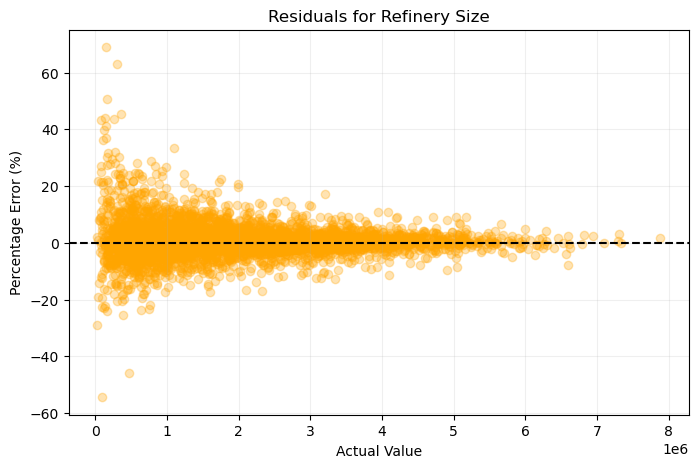

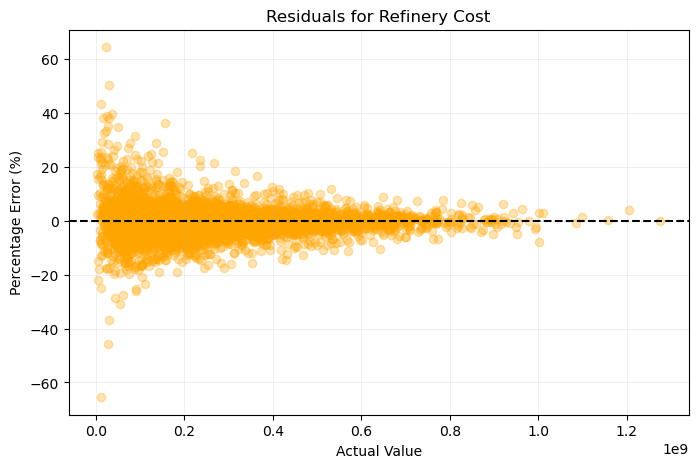

In [17]:
def plot_residuals(y_true, y_pred, name):
    residuals = (y_pred - y_true) / y_true * 100 # Percentage error
    plt.figure(figsize=(8, 5))
    plt.scatter(y_true, residuals, alpha=0.3, color='orange')
    plt.axhline(0, color='black', linestyle='--')
    plt.title(f'Residuals for {name}')
    plt.xlabel('Actual Value')
    plt.ylabel('Percentage Error (%)')
    plt.grid(True, alpha=0.2)
    plt.show()

plot_residuals(y_test[:, 1], y2_pred_test, "Refinery Size")
plot_residuals(y_test[:, 0], y1_pred_test, "Refinery Cost")

--- Metrics for Size < 400 ---
R² Score:      0.9948
Relative RMSE: 0.0592 (5.9%)
------------------------------


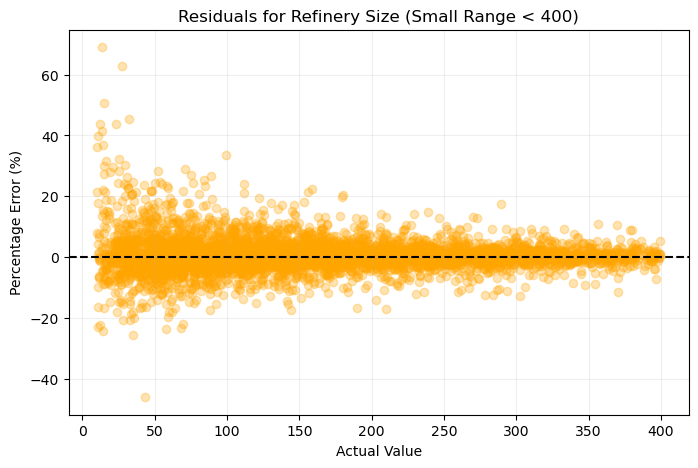

--- Metrics for Size < 400 ---
R² Score:      0.9944
Relative RMSE: 0.0587 (5.9%)
------------------------------


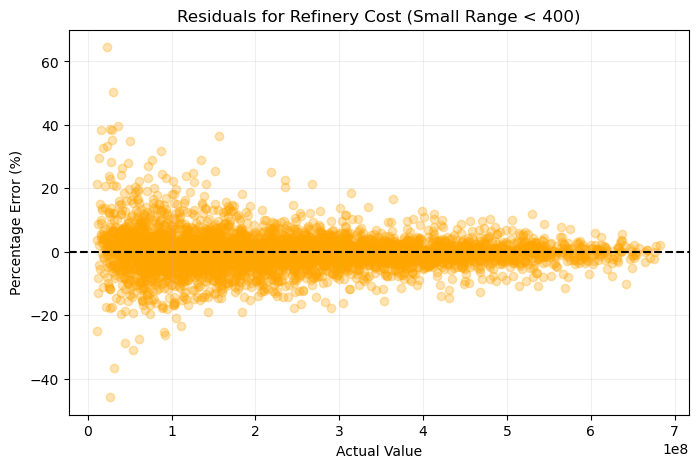

In [18]:
# 1. Create a mask for sizes less than 400
mask_small = ((y_test[:, 1] * ethanol_conversion_factor / gal_to_MMgal)< 400) & ((y_test[:, 1]* ethanol_conversion_factor / gal_to_MMgal) > 10)

# 2. Filter actual and predicted values
y_true_small = y_test[mask_small, 1]* ethanol_conversion_factor / gal_to_MMgal
y_pred_small = y2_pred_test[mask_small]* ethanol_conversion_factor / gal_to_MMgal

# 3. (Optional) Calculate metrics for just this small range
r2_small = r2_score(y_true_small, y_pred_small)
rel_rmse_small = np.sqrt(np.mean(((y_pred_small - y_true_small) / y_true_small)**2))

print(f"--- Metrics for Size < 400 ---")
print(f"R² Score:      {r2_small:.4f}")
print(f"Relative RMSE: {rel_rmse_small:.4f} ({rel_rmse_small*100:.1f}%)")
print("-" * 30)

# 4. Plot the filtered residuals
plot_residuals(y_true_small, y_pred_small, "Refinery Size (Small Range < 400)")

## Same for costs
# 2. Filter actual and predicted values
y_true_small = y_test[mask_small, 0]
y_pred_small = y1_pred_test[mask_small]

# 3. (Optional) Calculate metrics for just this small range
r2_small = r2_score(y_true_small, y_pred_small)
rel_rmse_small = np.sqrt(np.mean(((y_pred_small - y_true_small) / y_true_small)**2))

print(f"--- Metrics for Size < 400 ---")
print(f"R² Score:      {r2_small:.4f}")
print(f"Relative RMSE: {rel_rmse_small:.4f} ({rel_rmse_small*100:.1f}%)")
print("-" * 30)

# 4. Plot the filtered residuals
plot_residuals(y_true_small, y_pred_small, "Refinery Cost (Small Range < 400)")

In [19]:
# To see the parameters for your trained models:
print(f"Feedstock Costs - best_h: {model_costs_total.epsilon}, best_sm: {model_costs_total.smoothing}")
# The 'r' (radius scale) is stored in the scale_costs_total vector (index 2-5)
print(f"Feedstock Costs - best_r: {scale_costs_total[2]}")

print(f"Refinery Size - best_h: {model_size_total.epsilon}, best_sm: {model_size_total.smoothing}")
print(f"Refinery Size - best_r: {scale_size_total[2]}")

Feedstock Costs - best_h: 35.968316749454594, best_sm: 0.003
Feedstock Costs - best_r: 0.002313825994548632
Refinery Size - best_h: 35.968316749454594, best_sm: 0.003
Refinery Size - best_r: 0.002313825994548632


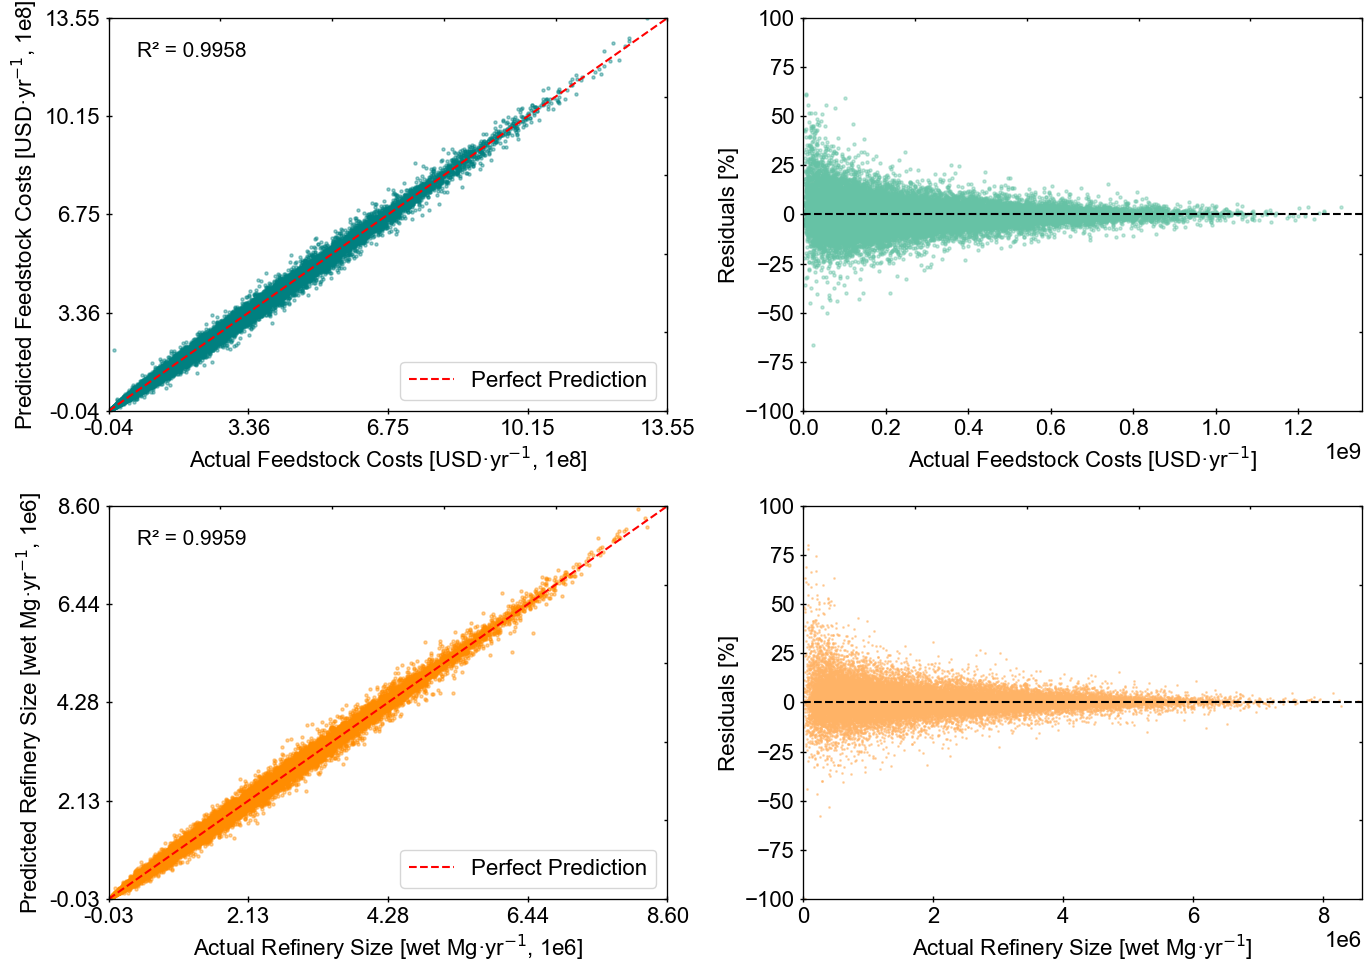

In [20]:
# ---- Global style ----
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 16
plt.rcParams['axes.titleweight'] = 'bold'

# ---- Colors ----
cost_color = 'teal'
size_color = 'darkorange'
residual_cost_color = '#66c2a5'  # lighter teal
residual_size_color = '#ffb366'  # lighter orange

# Custom formatter for 1e8 scale with 2 decimals
def scale_formatter(x, pos):
    return f"{x/1e8:.2f}"  # scales by 1e8 and shows 2 decimals

def scale_formatter_2(x, pos):
    return f"{x/1e6:.2f}"  # scales by 1e8 and shows 2 decimals


# ---- Combined plot function ----
def plot_pred_vs_residuals(y_true_c, y_pred_c, y_true_s, y_pred_s):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # --- Feedstock Costs Pred vs Actual ---
    ax = axes[0, 0]
    min_val = min(y_true_c.min(), y_pred_c.min())
    max_val = max(y_true_c.max(), y_pred_c.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')
    ax.scatter(y_true_c, y_pred_c, alpha=0.4, s=5, color=cost_color)
    r2 = r2_score(y_true_c, y_pred_c)
    ax.text(0.05, 0.9, f'R² = {r2:.4f}', transform=ax.transAxes, fontsize=15)

    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)
    # xticks = np.linspace(min_val, max_val, 6)
    # ax.set_xticks(xticks)
    # ax.set_yticks(xticks)
    # ax.set_xticklabels([f"{x:.2f}" for x in xticks])
    # ax.set_yticklabels([f"{y:.2f}" for y in xticks])
    # Use ScalarFormatter for scientific notation
    ax.xaxis.set_major_formatter(scale_formatter)
    ax.yaxis.set_major_formatter(scale_formatter)
    
    # Optional: Set ticks manually in 1e8 units
    ticks = np.linspace(min_val, max_val, 5)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

    
    ax.set_xlabel('Actual Feedstock Costs [USD·yr$^{-1}$, 1e8]')
    ax.set_ylabel('Predicted Feedstock Costs [USD·yr$^{-1}$, 1e8]')
    # ax.set_title('Feedstock Costs: Predicted vs Actual')
    ax.legend()
    ax.tick_params(direction='inout', length=5, width=1, bottom=True, top=False, left=True, right=False)
    # ax.grid(True, alpha=0.3)
    # top/right ticks
    ax_right = ax.twinx()
    ax_right.tick_params(direction='in', length=2.5, width=1, labelright=False, bottom=False, top=False, left=False, right=True)
    ax_top = ax.twiny()
    ax_top.tick_params(direction='in', length=2.5, width=1, labeltop=False, bottom=False, top=True, left=False, right=False)
    
    
    # --- Feedstock Costs Residuals ---
    ax = axes[0, 1]
    # residuals = (y_pred_c/(y_pred_s*ton_to_kg) - y_true_c/(y_true_s* ton_to_kg)) / (y_true_c/(y_true_s* ton_to_kg)) * 100
    residuals = (y_pred_c- y_true_c) / (y_true_c) * 100
    v_min_residuals = np.min(residuals)
    v_max_residuals = np.max(residuals)
    ax.scatter(y_true_c, residuals, alpha=0.4, s=5, color=residual_cost_color)
    ax.axhline(0, color='black', linestyle='--')
    ax.set_xlabel('Actual Feedstock Costs [USD·yr$^{-1}$]')
    ax.set_ylabel('Residuals [%]')
    ax.tick_params(direction='inout', length=5, width=1, bottom=True, top=False, left=True, right=False)
    # ax.set_title('Feedstock Costs Residuals')
    ax.set_xlim(0, max_val)
    # ax.set_ylim(v_min_residuals, v_max_residuals)
    # ax.grid(True, alpha=0.3)
    ax_right = ax.twinx()
    ax_right.tick_params(direction='in', length=2.5, width=1, labelright=False, bottom=False, top=False, left=False, right=True)
    ax_top = ax.twiny()
    ax_top.tick_params(direction='in', length=2.5, width=1, labeltop=False, bottom=False, top=True, left=False, right=False)
    ax.set_ylim(-100,100)
    
    # --- Refinery Size Pred vs Actual ---
    ax = axes[1, 0]
    min_val = min(y_true_s.min(), y_pred_s.min())
    max_val = max(y_true_s.max(), y_pred_s.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')
    ax.scatter(y_true_s, y_pred_s, alpha=0.4, s=5, color=size_color)
    r2 = r2_score(y_true_s, y_pred_s)
    ax.text(0.05, 0.9, f'R² = {r2:.4f}', transform=ax.transAxes, fontsize=15)

    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)
    # xticks = np.linspace(min_val, max_val, 6)
    ax.xaxis.set_major_formatter(scale_formatter_2)
    ax.yaxis.set_major_formatter(scale_formatter_2)
    ax.tick_params(direction='inout', length=5, width=1, bottom=True, top=False, left=True, right=False)

    # top/right ticks
    ax_right = ax.twinx()
    ax_right.tick_params(direction='in', length=2.5, width=1, labelright=False, bottom=False, top=False, left=False, right=True)
    ax_top = ax.twiny()
    ax_top.tick_params(direction='in', length=2.5, width=1, labeltop=False, bottom=False, top=True, left=False, right=False)
    
    # Optional: Set ticks manually in 1e8 units
    ticks = np.linspace(min_val, max_val, 5)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    # ax.set_xticks(xticks)
    # ax.set_yticks(xticks)
    # ax.set_xticklabels([f"{x:.2f}" for x in xticks])
    # ax.set_yticklabels([f"{y:.2f}" for y in xticks])
    
    ax.set_xlabel('Actual Refinery Size [wet Mg·yr$^{-1}$, 1e6]')
    ax.set_ylabel('Predicted Refinery Size [wet Mg·yr$^{-1}$, 1e6]')
    # ax.set_title('Refinery Size: Predicted vs Actual')
    ax.legend()
    # ax.grid(True, alpha=0.3)
    
    # --- Refinery Size Residuals ---
    ax = axes[1, 1]
    # residuals = (y_pred_s* ethanol_conversion_factor / gal_to_MMgal - y_true_s* ethanol_conversion_factor / gal_to_MMgal) / (y_true_s* ethanol_conversion_factor / gal_to_MMgal) * 100
    residuals = (y_pred_s - y_true_s) / (y_true_s) * 100
    ax.scatter(y_true_s, residuals, alpha=0.5, s=1, color=residual_size_color)
    ax.axhline(0, color='black', linestyle='--')
    ax.set_xlabel('Actual Refinery Size [wet Mg·yr$^{-1}$]')
    ax.set_ylabel('Residuals [%]')
    ax.tick_params(direction='inout', length=5, width=1, bottom=True, top=False, left=True, right=False)
    # ax.set_title('Refinery Size Residuals')
    # ax.grid(True, alpha=0.3)
    ax_right = ax.twinx()
    ax_right.tick_params(direction='in', length=2.5, width=1, labelright=False, bottom=False, top=False, left=False, right=True)
    ax_top = ax.twiny()
    ax_top.tick_params(direction='in', length=2.5, width=1, labeltop=False, bottom=False, top=True, left=False, right=False)
    ax.set_xlim(0, max_val)#* ethanol_conversion_factor / gal_to_MMgal)
    ax.set_ylim(-100,100)
    
    plt.tight_layout()
    plt.savefig('PredictedvsActual.png', dpi = 1200, transparent = True)
    plt.show()
    
# * ethanol_conversion_factor / gal_to_MMgal
y1_pred_val_times_area = y1_pred_val* areas_val
y1_real_density = y1_val_real/areas_val
y2_pred_val_times_area = y2_pred_val * areas_val
y2_real_density = y2_val_real/areas_val
# ---- Call the function with your validation/test data ----
plot_pred_vs_residuals(y1_val_real, y1_pred_val_times_area, y2_val_real, y2_pred_val_times_area)

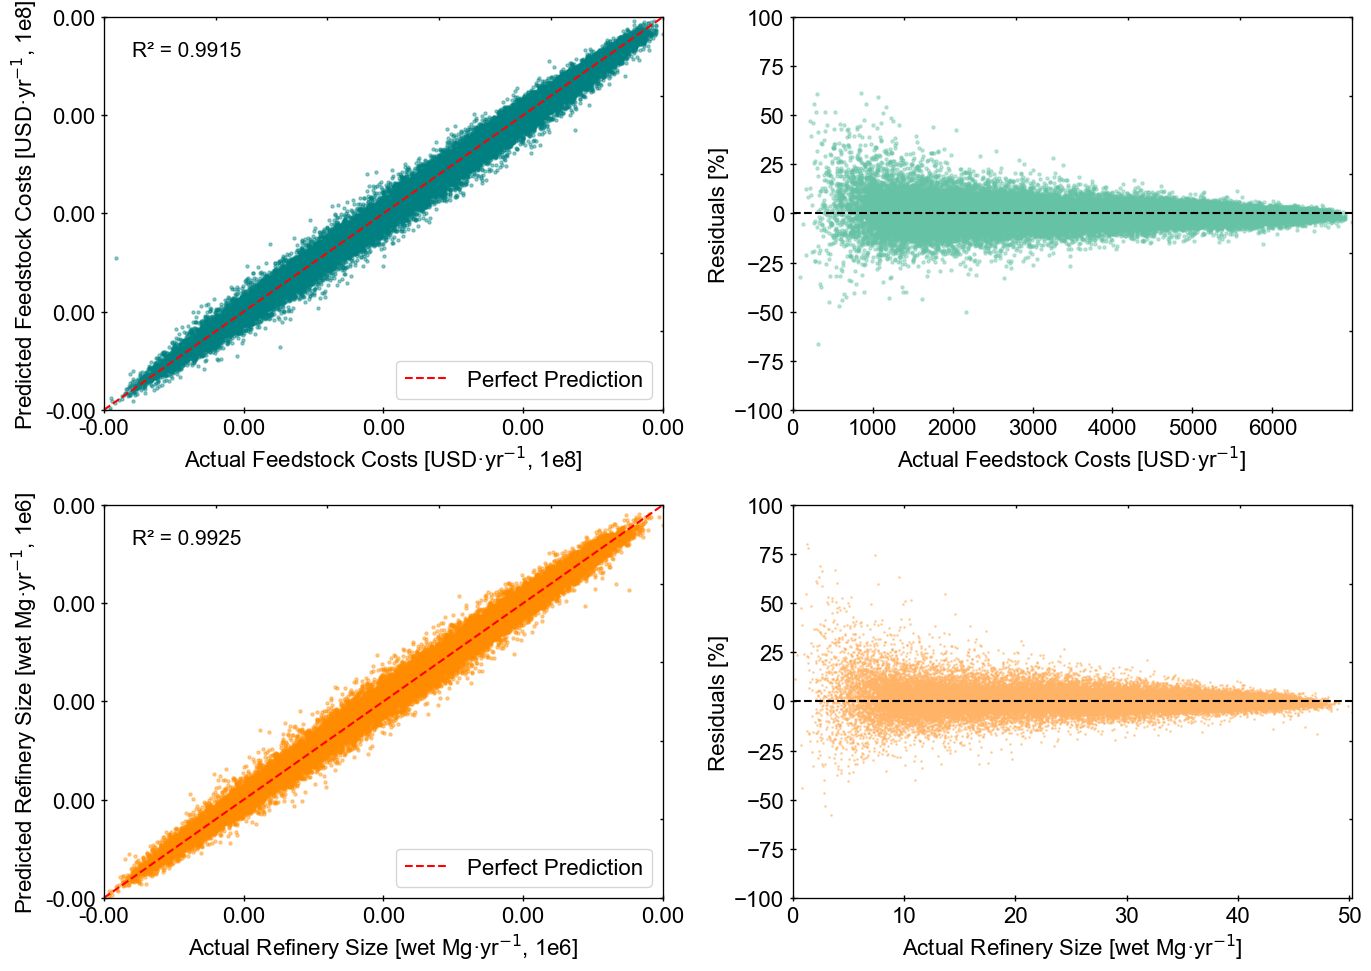

In [21]:
plot_pred_vs_residuals(y1_real_density, y1_pred_val, y2_real_density, y2_pred_val)

### Moran's I

In [22]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

def manual_moran_i(coords, y_real, y_pred, k=8):
    # 1. Calculate Percentage Residuals (The "Variable" for Moran's I)
    z = ((y_pred - y_real) / y_real) * 100
    z = z - np.mean(z)  # Mean-center the residuals
    
    # 2. Find Neighbors
    knn = NearestNeighbors(n_neighbors=k+1).fit(coords)
    distances, indices = knn.kneighbors(coords)
    
    # 3. Calculate Spatial Lag (Average error of neighbors)
    # indices[:, 0] is the point itself, so we use [:, 1:]
    neighbor_indices = indices[:, 1:] 
    z_lag = np.mean(z[neighbor_indices], axis=1)
    
    # 4. Moran's I Formula: (n / W) * [sum(zi * z_lag_i) / sum(zi^2)]
    # Since we use row-standardized weights (mean of neighbors), W = n
    numerator = np.sum(z * z_lag)
    denominator = np.sum(z**2)
    moran_i = numerator / denominator
    
    return moran_i, z, z_lag

# Use your actual validation coordinates (Lon, Lat or X, Y)
# Assuming Xn_val[:, 0:2] are the coordinates
coords_val = Xn_val[:, 0:2]

i_costs, z_c, z_lag_c = manual_moran_i(coords_val, y1_val_real, y1_pred_val)
i_size, z_s, z_lag_s = manual_moran_i(coords_val, y2_val_real, y2_pred_val)

print(f"Manual Moran's I (Costs): {i_costs:.4f}")
print(f"Manual Moran's I (Size):  {i_size:.4f}")

i_costs, z_c, z_lag_c = manual_moran_i(coords_val, y1_real_density, y1_pred_val)
i_size, z_s, z_lag_s = manual_moran_i(coords_val, y2_real_density, y2_pred_val)

print(f"Manual Moran's I (Costs): {i_costs:.4f}")
print(f"Manual Moran's I (Size):  {i_size:.4f}")

Manual Moran's I (Costs): 0.0071
Manual Moran's I (Size):  0.0079
Manual Moran's I (Costs): -0.0026
Manual Moran's I (Size):  0.0114


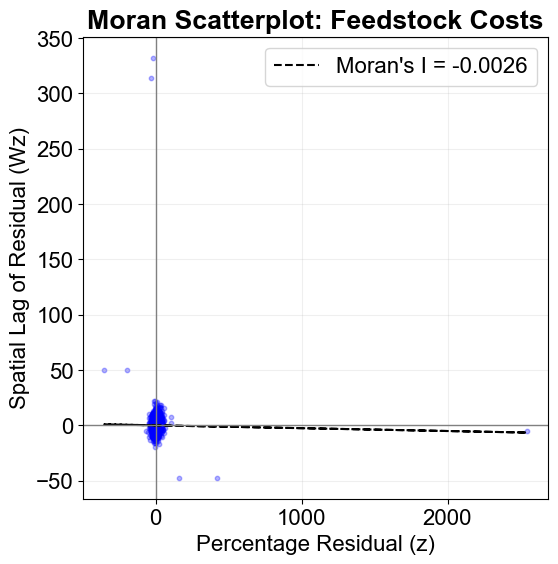

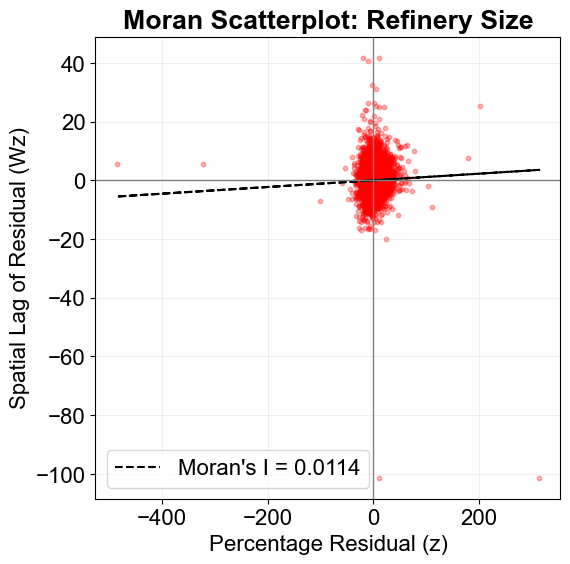

In [23]:
def plot_moran_scatterplot(z, z_lag, name, color):
    plt.figure(figsize=(6, 6))
    plt.scatter(z, z_lag, alpha=0.3, color=color, s=10)
    
    # Add the regression line (The slope is exactly Moran's I!)
    m, b = np.polyfit(z, z_lag, 1)
    plt.plot(z, m*z + b, color='black', linestyle='--', label=f"Moran's I = {m:.4f}")
    
    plt.axhline(0, color='grey', lw=1); plt.axvline(0, color='grey', lw=1)
    plt.title(f"Moran Scatterplot: {name}")
    plt.xlabel("Percentage Residual (z)")
    plt.ylabel("Spatial Lag of Residual (Wz)")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

plot_moran_scatterplot(z_c, z_lag_c, "Feedstock Costs", "blue")
plot_moran_scatterplot(z_s, z_lag_s, "Refinery Size", "red")

### Function to calculate areas

In [78]:
def calculate_areas_vectorized(inputs_rand, n_interp_points):
    """
    Efficiently calculate area values based on random input samples.

    Parameters
    ----------
    inputs_rand : np.ndarray
        2D array of random input values (shape: [num_variables, N_rand]).
    n_interp_points : int
        Number of interpolation points.

    Returns
    -------
    np.ndarray
        Array of calculated areas for each random sample.
    """
    # Extract relevant radii: shape (N_rand, n_interp_points)
    R = inputs_rand.T[:, -n_interp_points:]

    # Shifted version of R to get Rk (wrap last to first)
    Rk = np.roll(R, -1, axis=1)

    # Compute area terms (vectorized)
    term1 = np.pi / n_interp_points * R**2
    term2 = np.pi / n_interp_points * R * (Rk - R)
    term3 = np.pi / (3 * n_interp_points) * (Rk - R)**2

    # Sum over interpolation points
    areas = np.sum(term1 + term2 + term3, axis=1)

    return areas

## Justify 500k samples

In [478]:
def train_rbf_model_subsample(
    Xn_train_sub, yn_train_sub,
    Xn_val_sub, y_val_sub,
    y_min, y_max,
    target_idx,
    is_inverted=False,
    sm=1e-3,
    max_opt_points=3000,
    neighbors_opt=50,
    neighbors_final=80
):
    
    # --- optimization subset (memory safe)
    if len(Xn_train_sub) > max_opt_points:
        idx = np.random.choice(len(Xn_train_sub), max_opt_points, replace=False)
        X_opt = Xn_train_sub[idx]
        y_opt = yn_train_sub[idx, target_idx]
    else:
        X_opt = Xn_train_sub
        y_opt = yn_train_sub[:, target_idx]

    y_val_real = y_val_sub[:, target_idx]

    bounds = [(-3, 0), (-4, 0)]  # log10(h), log10(r)

    def objective(params):
        log_h, log_r = params
        h, r = 10**log_h, 10**log_r
        scale_vec = np.array([1.0, 1.0, r, r, r, r])

        try:
            rbf = GaussianRBFInterpolator_new(
                X_opt * scale_vec, y_opt,
                epsilon=1/h**2,
                smoothing=sm,
                neighbors=neighbors_opt
            )

            yn_pred = rbf(Xn_val_sub * scale_vec)

            # inverse normalization
            if is_inverted:
                y_pred = y_max - yn_pred * (y_max - y_min)
            else:
                y_pred = (y_max - y_min) * yn_pred + y_min

            error = np.mean((y_pred - y_val_real)**2)
            return error if np.isfinite(error) else 1e6

        except:
            return 1e6

    result = differential_evolution(
        objective, bounds,
        strategy='best1bin',
        maxiter=60,   # faster for learning curve
        popsize=12,
        seed=123
    )

    best_h, best_r = 10**result.x
    best_scale = np.array([1.0, 1.0, best_r, best_r, best_r, best_r])

    # --- final model on subsample
    final_model = GaussianRBFInterpolator_new(
        Xn_train_sub * best_scale,
        yn_train_sub[:, target_idx],
        epsilon=1/best_h**2,
        smoothing=sm,
        neighbors=neighbors_final
    )

    return final_model, best_scale, best_h, best_r


In [480]:
np.random.seed(123)

def safe_mape(y_true, y_pred, eps=1e-8):
    mask = np.abs(y_true) > eps
    return np.mean(np.abs(y_pred[mask] / y_true[mask] - 1)) * 100


# sample_sizes = np.arange(100_000, 450_001, 100_000)
# Check the actual size of your training data
max_train_size = len(Xn_train)
print(f"Total available training samples: {max_train_size}")

# Define sample sizes that are within the available range
# We use max_train_size as the final point
sample_sizes = [100000, 200000, 300000, 
                400000, 
                max_train_size]
results = []

y_val_density = y_val / areas_val[:, None]

for size in sample_sizes:
    print(f"\nTraining with {size} samples")

    idx = np.random.choice(len(Xn_train), size, replace=False)

    X_train_sub = Xn_train[idx]
    y_train_sub = y_train[idx]
    yn_train_sub = yn_train[idx]
    areas_sub = areas_train[idx]

    # ================= COST =================
    model_c, scale_c, h_c, r_c = train_rbf_model_subsample(
        X_train_sub, yn_train_sub,
        Xn_val, y_val_density,
        y1_min, y1_max,
        target_idx=0,
        is_inverted=True
    )

    yn_pred_c = model_c(Xn_val * scale_c)
    y_pred_c = y1_max - yn_pred_c * (y1_max - y1_min)

    yn_pred_c_train = model_c(X_train_sub * scale_c)
    y_pred_c_train = y1_max - yn_pred_c_train * (y1_max - y1_min)

    y_true_c_train = y_train_sub[:, 0] / areas_sub
    y_true_c_val   = y_val[:, 0] / areas_val

    train_mape_c = np.mean(np.abs(y_pred_c_train / y_true_c_train - 1)) * 100
    mape_c = np.mean(np.abs(y_pred_c / y_true_c_val - 1)) * 100
    rel_rmse_c = np.sqrt(np.mean(((y_pred_c - y_true_c_val) / y_true_c_val)**2)) * 100
    r2_c = r2_score(y_true_c_val, y_pred_c)

    # ================= SIZE =================
    model_s, scale_s, h_s, r_s = train_rbf_model_subsample(
        X_train_sub, yn_train_sub,
        Xn_val, y_val_density,
        y2_min, y2_max,
        target_idx=1,
        is_inverted=False
    )

    yn_pred_s = model_s(Xn_val * scale_s)
    y_pred_s = (y2_max - y2_min) * yn_pred_s + y2_min

    yn_pred_s_train = model_s(X_train_sub * scale_s)
    y_pred_s_train = (y2_max - y2_min) * yn_pred_s_train + y2_min

    y_true_s_train = y_train_sub[:, 1] / areas_sub
    y_true_s_val   = y_val[:, 1] / areas_val

    # train_mape_s = np.mean(np.abs(y_pred_s_train / y_true_s_train - 1)) * 100
    # mape_s = np.mean(np.abs(y_pred_s / y_true_s_val - 1)) * 100
    train_mape_s = safe_mape(y_true_s_train, y_pred_s_train)
    mape_s       = safe_mape(y_true_s_val, y_pred_s)

    rel_rmse_s = np.sqrt(np.mean(((y_pred_s - y_true_s_val) / y_true_s_val)**2)) * 100
    r2_s = r2_score(y_true_s_val, y_pred_s)

    results.append({
        'Training_Samples': size,
        'Cost_MAPE_Train': train_mape_c,
        'Cost_MAPE_Val': mape_c,
        'Cost_RelRMSE_Val': rel_rmse_c,
        'Cost_R2_Val': r2_c,
        'Size_MAPE_Train': train_mape_s,
        'Size_MAPE_Val': mape_s,
        'Size_RelRMSE_Val': rel_rmse_s,
        'Size_R2_Val': r2_s,
        # 'h_cost': h_c,
        # 'r_cost': r_c,
        # 'h_size': h_s,
        # 'r_size': r_s
    })


# --- print table
df_learning = pd.DataFrame(results)
print(df_learning.to_string(index=False))


Total available training samples: 450000

Training with 100000 samples

Training with 200000 samples

Training with 300000 samples

Training with 400000 samples

Training with 450000 samples
 Training_Samples  Cost_MAPE_Train  Cost_MAPE_Val  Cost_RelRMSE_Val  Cost_R2_Val  Size_MAPE_Train  Size_MAPE_Val  Size_RelRMSE_Val  Size_R2_Val
           100000         3.089794       3.460618          6.550846     0.993580         2.754111       3.277101          7.007987     0.994560
           200000         2.961368       3.281274          5.901097     0.994095         2.774071       3.170646          5.810764     0.994842
           300000         2.949390       3.218055          5.387629     0.994247         2.789636       3.150370          5.730164     0.994838
           400000         2.994156       3.179742          5.732558     0.994399         2.739445       3.043622          5.348111     0.995171
           450000         2.950820       3.160331          5.063381     0.994406         

In [75]:
# 2. Convert to DataFrame and Save
df_convergence = pd.DataFrame(results)
# df_convergence.to_csv("rbf_convergence_data.csv", index=False)
print("Convergence analysis complete. Results saved.")



Convergence analysis complete. Results saved.


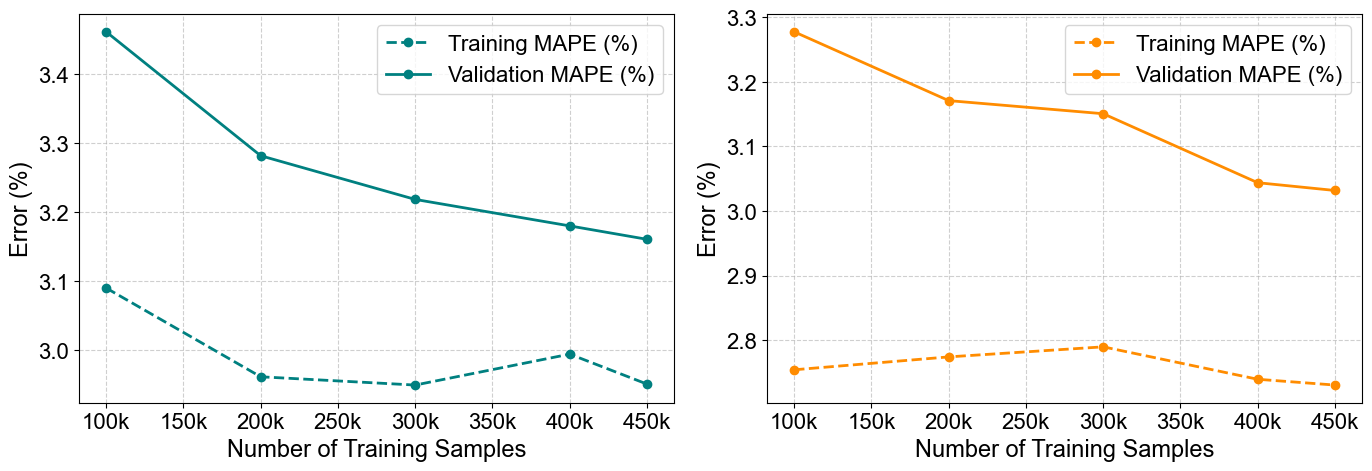

In [487]:
import matplotlib as mpl
from matplotlib.ticker import FuncFormatter

# ---- Global style ----
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['font.size'] = 16
mpl.rcParams['axes.titleweight'] = 'bold'

# ---- Colors ----
cost_color = 'teal'
size_color = 'darkorange'

def k_formatter(x, pos):
    return f'{int(x/1000)}k'

# 1. Create the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 2. Plot Costs (Left Subplot)
ax1.plot(df_learning['Training_Samples'], df_learning['Cost_MAPE_Train'], 
         'o--', label='Training MAPE (%)', color=cost_color, linewidth=2)
# ax1.plot(df_convergence['Training_Samples'], df_convergence['Cost_RelRMSE'], 
#          's--', label='Rel. RMSE (%)', color='teal', alpha=0.7)
ax1.plot(df_learning['Training_Samples'], df_learning['Cost_MAPE_Val'], 
         'o-', label='Validation MAPE (%)', color=cost_color, linewidth=2)
# ax1.set_title('Convergence Analysis: Feedstock Costs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Training Samples', fontsize = 17)
ax1.set_ylabel('Error (%)', fontsize = 17)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)


# 3. Plot Size (Right Subplot)
ax2.plot(df_learning['Training_Samples'], df_learning['Size_MAPE_Train'], 
         'o--', label='Training MAPE (%)', color=size_color, linewidth=2)
ax2.plot(df_learning['Training_Samples'], df_learning['Size_MAPE_Val'], 
         'o-', label='Validation MAPE (%)', color=size_color, linewidth=2)
# ax2.plot(df_convergence['Training_Samples'], df_convergence['Size_RelRMSE'], 
#          's--', label='Rel. RMSE (%)', color='orange', alpha=0.7)

# ax2.set_title('Convergence Analysis: Refinery Size', fontsize=14, fontweight='bold')
ax2.set_xlabel('Number of Training Samples', fontsize = 17)
ax2.set_ylabel('Error (%)', fontsize = 17)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

for ax in (ax1, ax2):
    ax.xaxis.set_major_formatter(FuncFormatter(k_formatter))

plt.tight_layout()

# 4. Save for Manuscript
plt.savefig("RBF_Convergence_Analysis_Figure.png", dpi=800, transparent = True)
plt.show()

## Predictor functions

In [59]:
def predict_batch_rbf_costs(X_norm_batch, rbf_model, scale_vec, y_min, y_max):
    X_scaled = X_norm_batch * scale_vec
    yn_pred = rbf_model(X_scaled)
    
    # 1. Back-transform from Normalized to Log space
    y_pred = y_max - yn_pred * (y_max - y_min)
    y_real = np.maximum(y_pred, y_min)
    
    return y_real
    
def predict_batch_rbf_size(X_norm_batch, rbf_model, scale_vec, y_min, y_max):
    X_scaled = X_norm_batch * scale_vec
    yn_pred = rbf_model(X_scaled)
    # 1. Back-transform from Normalized to Log space
    y_pred = y_min + yn_pred * (y_max - y_min)
    y_real = np.maximum(y_pred, y_min)
    
    return y_real

# BC interpolation Ethanol

In [26]:
# y2 = (np.load("production_per_area_with_density_Rs_100k_2perc.npy")* ethanol_conversion_factor / gal_to_MMgal)[:N_rand]
in_bc = np.load("../bc_coef/X_data_for_Ethanol_sat_Coef.npy")
out_bc = np.load("../bc_coef/outputs_Ethanol_sat_Coef.npy")

In [28]:
X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    in_bc, out_bc, test_size=0.2, random_state=42
)

In [29]:
%%time
lin_interpolation_bc = LinearNDInterpolator(X_train_bc, y_train_bc)
y_pred_bc = lin_interpolation_bc(X_test_bc)#lin_int(X_test_bc)
y_pred_bc[:,0] = np.nan_to_num(y_pred_bc[:,0], nan = np.nanmax(y_pred_bc[:,0]))
y_pred_bc[:,1] = np.nan_to_num(y_pred_bc[:,1], nan = np.nanmax(y_pred_bc[:,1]))
print(r2_score(y_test_bc,y_pred_bc))

0.994811096208768
CPU times: user 18.8 s, sys: 225 ms, total: 19.1 s
Wall time: 19.2 s


In [30]:
r2_b = r2_score(y_test_bc[:, 0], y_pred_bc[:, 0])
r2_c = r2_score(y_test_bc[:, 1], y_pred_bc[:, 1])

print(f"R2 (b): {r2_b:.4f}")
print(f"R2 (c): {r2_c:.4f}")

R2 (b): 0.9948
R2 (c): 0.9948


In [57]:
def b_c_vectorized(coords):
    """
    coords: array of shape (N, 2) or (PopSize, N, 2)
    """
    # Assuming lin_interpolation_bc can handle multidimensional inputs
    y = lin_interpolation_bc(coords) 

    B_MIN = np.nanmin(y_pred_bc[:, 0])
    C_MIN = np.nanmin(y_pred_bc[:, 1])
    
    # Extract b and c (assuming y is [..., 2])
    b = np.nan_to_num(y[..., 0], nan=B_MIN)
    c = np.nan_to_num(y[..., 1], nan=C_MIN)
    
    return b, c

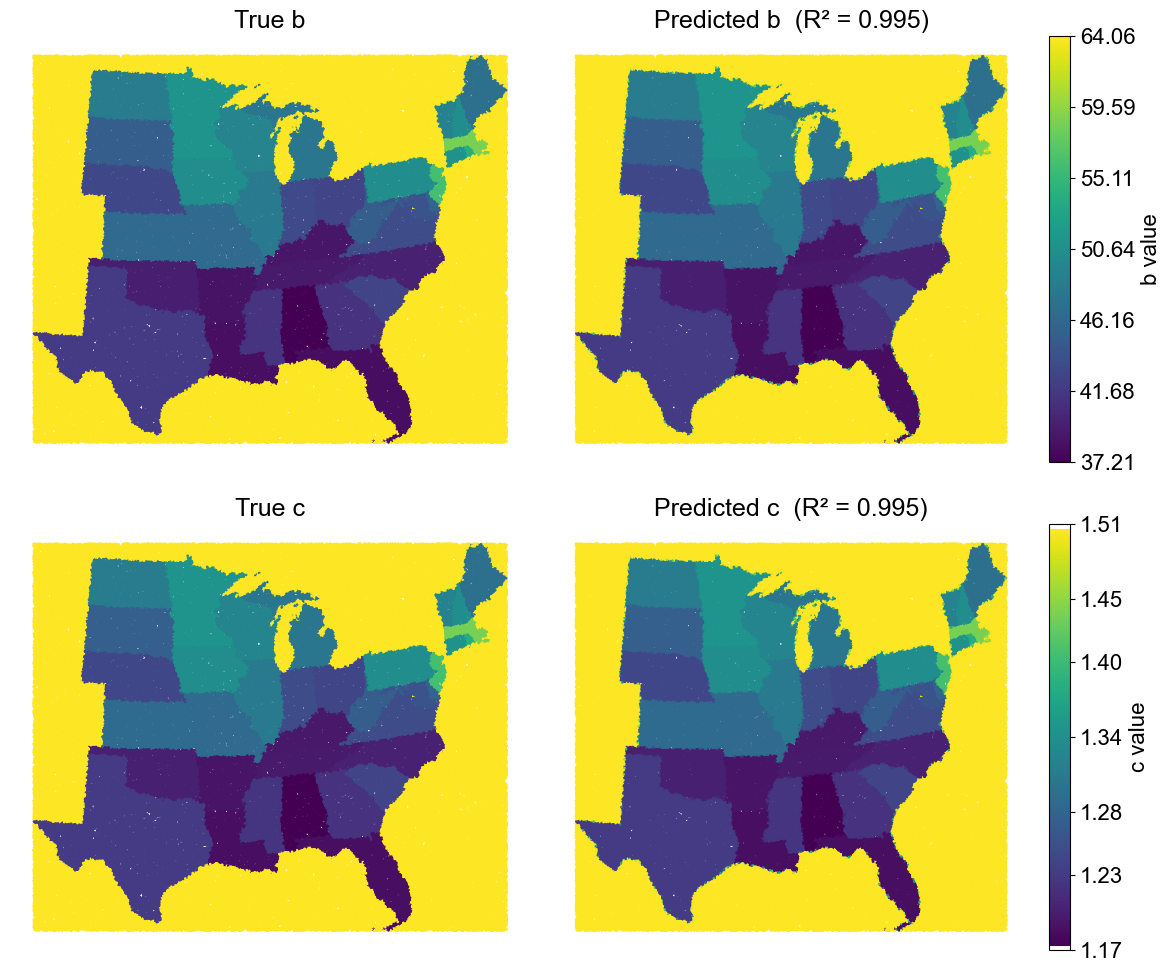

In [61]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

# Coordinates
x = X_test_bc[:, 0]
y = X_test_bc[:, 1]

# True / predicted
b_true = y_test_bc[:, 0]
c_true = y_test_bc[:, 1]
b_pred = y_pred_bc[:, 0]
c_pred = y_pred_bc[:, 1]

# Optional: mask NaNs (strongly recommended for LinearNDInterpolator)
# mask = ~np.isnan(b_pred) & ~np.isnan(c_pred)

# x, y = x[mask], y[mask]
# b_true, c_true = b_true[mask], c_true[mask]
# b_pred, c_pred = b_pred[mask], c_pred[mask]

# R²
r2_b = r2_score(b_true, b_pred)
r2_c = r2_score(c_true, c_pred)

# Shared color limits
vmin_b, vmax_b = np.min(b_true), np.max(b_true)
vmin_c, vmax_c = np.min(c_true), np.max(c_true)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- b: true ---
sc_b_true = axes[0, 0].scatter(
    x, y, s=0.8, c=b_true,
    cmap='viridis', vmin=vmin_b, vmax=vmax_b
)
axes[0, 0].set_title("True b",  fontsize = 18, fontweight='normal')
axes[0, 0].axis('off')

# --- b: predicted ---
sc_b_pred = axes[0, 1].scatter(
    x, y, s=0.8, c=b_pred,
    cmap='viridis', vmin=vmin_b, vmax=vmax_b
)
axes[0, 1].set_title(f"Predicted b  (R² = {r2_b:.3f})",  fontsize = 18, fontweight='normal')
axes[0, 1].axis('off')

# --- c: true ---
sc_c_true = axes[1, 0].scatter(
    x, y, s=0.8, c=c_true,
    cmap='viridis', vmin=vmin_c, vmax=vmax_c
)
axes[1, 0].set_title("True c",  fontsize = 18, fontweight='normal')
axes[1, 0].axis('off')

# --- c: predicted ---
sc_c_pred = axes[1, 1].scatter(
    x, y, s=0.8, c=c_pred,
    cmap='viridis', vmin=vmin_c, vmax=vmax_c
)
axes[1, 1].set_title(f"Predicted c  (R² = {r2_c:.3f})", fontsize = 18, fontweight='normal')
axes[1, 1].axis('off')

# Colorbars (only for predicted → cleaner)
cbar_b = fig.colorbar(sc_b_pred, ax=axes[0, 1], fraction=0.05, pad=0.04)
cbar_b.set_label("b value")

cbar_c = fig.colorbar(sc_c_pred, ax=axes[1, 1], fraction=0.05, pad=0.04)
cbar_c.set_label("c value")

# Optional custom ticks
cbar_b.set_ticks(np.round(np.linspace(np.round(vmin_b,2), np.round(vmax_b,2), 7), 2))
cbar_c.set_ticks(np.round(np.linspace(np.round(vmin_c,2), np.round(vmax_c,2), 7), 2))

plt.tight_layout()
plt.savefig(
    "bc_interpolation_map_performance.png",
    dpi=800,
    transparent=True
)
plt.show()


# BC Acrylic Acid

In [33]:
in_bc_AA = np.load("../bc_coef/X_data_for_AA_Coef_2.npy")
out_bc_AA = np.load("../bc_coef/outputs_AA_Coef_2.npy")

In [34]:
X_train_bc_AA, X_test_bc_AA, y_train_bc_AA, y_test_bc_AA = train_test_split(
    in_bc_AA, out_bc_AA, test_size=0.2, random_state=42
)

In [35]:
%%time
lin_interpolation_bc_AA = LinearNDInterpolator(X_train_bc_AA, y_train_bc_AA)
y_pred_bc_AA = lin_interpolation_bc_AA(X_test_bc_AA)#lin_int(X_test_bc)
y_pred_bc_AA[:,0] = np.nan_to_num(y_pred_bc_AA[:,0], nan = np.nanmax(y_pred_bc_AA[:,0]))
y_pred_bc_AA[:,1] = np.nan_to_num(y_pred_bc_AA[:,1], nan = np.nanmax(y_pred_bc_AA[:,1]))
print(r2_score(y_test_bc_AA,y_pred_bc_AA))

0.9948004085414952
CPU times: user 21.3 s, sys: 91.7 ms, total: 21.4 s
Wall time: 21.7 s


In [36]:
r2_b_AA = r2_score(y_test_bc_AA[:, 0], y_pred_bc_AA[:, 0])
r2_c_AA = r2_score(y_test_bc_AA[:, 1], y_pred_bc_AA[:, 1])

print(f"R2 (b): {r2_b_AA:.4f}")
print(f"R2 (c): {r2_c_AA:.4f}")

R2 (b): 0.9947
R2 (c): 0.9949


In [37]:
def b_c_AA_vectorized(coords):
    """
    coords: array of shape (N, 2) or (PopSize, N, 2)
    """
    # Assuming lin_interpolation_bc can handle multidimensional inputs
    y = lin_interpolation_bc_AA(coords) 
    
    B_MIN = np.nanmin(y_pred_bc_AA[:, 0])
    C_MIN = np.nanmin(y_pred_bc_AA[:, 1])

    
    # Extract b and c (assuming y is [..., 2])
    b = np.nan_to_num(y[..., 0], nan=B_MIN)
    c = np.nan_to_num(y[..., 1], nan=C_MIN)
    
    return b, c

# Succinic Acid

In [38]:
in_bc_SA = np.load("../bc_coef/X_data_for_Succinic_Coef_2.npy")
out_bc_SA = np.load("../bc_coef/outputs_Succinic_Coef_2.npy")

In [39]:
X_train_bc_SA, X_test_bc_SA, y_train_bc_SA, y_test_bc_SA = train_test_split(
    in_bc_SA, out_bc_SA, test_size=0.2, random_state=42
)

In [40]:
%%time
lin_interpolation_bc_SA = LinearNDInterpolator(X_train_bc_SA, y_train_bc_SA)
y_pred_bc_SA = lin_interpolation_bc_SA(X_test_bc_SA)#lin_int(X_test_bc)
y_pred_bc_SA[:,0] = np.nan_to_num(y_pred_bc_SA[:,0], nan = np.nanmax(y_pred_bc_SA[:,0]))
y_pred_bc_SA[:,1] = np.nan_to_num(y_pred_bc_SA[:,1], nan = np.nanmax(y_pred_bc_SA[:,1]))
print(r2_score(y_test_bc_SA,y_pred_bc_SA))

0.9948858707676365
CPU times: user 20.5 s, sys: 191 ms, total: 20.7 s
Wall time: 21 s


In [41]:
r2_b_SA = r2_score(y_test_bc_SA[:, 0], y_pred_bc_SA[:, 0])
r2_c_SA = r2_score(y_test_bc_SA[:, 1], y_pred_bc_SA[:, 1])

print(f"R2 (b): {r2_b_SA:.4f}")
print(f"R2 (c): {r2_c_SA:.4f}")

R2 (b): 0.9948
R2 (c): 0.9950


In [42]:
def b_c_SA_vectorized(coords):
    """
    coords: array of shape (N, 2) or (PopSize, N, 2)
    """
    # Assuming lin_interpolation_bc can handle multidimensional inputs
    y = lin_interpolation_bc_SA(coords) 
    B_MIN = np.nanmin(y_pred_bc_SA[:, 0])
    C_MIN = np.nanmin(y_pred_bc_SA[:, 1])
    # Extract b and c (assuming y is [..., 2])
    b = np.nan_to_num(y[..., 0], nan=B_MIN)
    c = np.nan_to_num(y[..., 1], nan=C_MIN)
    
    return b, c

# Potassium sorbate

In [43]:
in_bc_KS = np.load("../bc_coef/X_data_for_Potassium_Sorbate_Coef.npy")
out_bc_KS = np.load("../bc_coef/outputs_Potassium_Sorbate_Coef.npy")

In [45]:
X_train_bc_KS, X_test_bc_KS, y_train_bc_KS, y_test_bc_KS = train_test_split(
    in_bc_KS, out_bc_KS, test_size=0.2, random_state=42
)

In [46]:
%%time
lin_interpolation_bc_KS = LinearNDInterpolator(X_train_bc_KS, y_train_bc_KS)
y_pred_bc_KS = lin_interpolation_bc_KS(X_test_bc_KS)#lin_int(X_test_bc)
y_pred_bc_KS[:,0] = np.nan_to_num(y_pred_bc_KS[:,0], nan = np.nanmax(y_pred_bc_KS[:,0]))
y_pred_bc_KS[:,1] = np.nan_to_num(y_pred_bc_KS[:,1], nan = np.nanmax(y_pred_bc_KS[:,1]))
print(r2_score(y_test_bc_KS,y_pred_bc_KS))

0.9928787143585955
CPU times: user 21.6 s, sys: 129 ms, total: 21.8 s
Wall time: 22.1 s


In [47]:
r2_b_KS = r2_score(y_test_bc_KS[:, 0], y_pred_bc_KS[:, 0])
r2_c_KS = r2_score(y_test_bc_KS[:, 1], y_pred_bc_KS[:, 1])

print(f"R2 (b): {r2_b_KS:.4f}")
print(f"R2 (c): {r2_c_KS:.4f}")

R2 (b): 0.9948
R2 (c): 0.9910


In [48]:
def b_c_KS_vectorized(coords):
    """
    coords: array of shape (N, 2) or (PopSize, N, 2)
    """
    # Assuming lin_interpolation_bc can handle multidimensional inputs
    y = lin_interpolation_bc_KS(coords) 

    B_MIN = np.nanmin(y_pred_bc_KS[:, 0])
    C_MIN = np.nanmin(y_pred_bc_KS[:, 1])
    
    # Extract b and c (assuming y is [..., 2])
    b = np.nan_to_num(y[..., 0], nan=B_MIN)
    c = np.nan_to_num(y[..., 1], nan=C_MIN)
    
    return b, c

# Lactic Acid

In [49]:
in_bc_LA = np.load("../bc_coef/X_data_for_Lactic_Acid_Coef_2.npy")
out_bc_LA = np.load("../bc_coef/outputs_Lactic_Acid_Coef_2.npy")

In [50]:
X_train_bc_LA, X_test_bc_LA, y_train_bc_LA, y_test_bc_LA = train_test_split(
    in_bc_LA, out_bc_LA, test_size=0.2, random_state=42
)

In [51]:
%%time
lin_interpolation_bc_LA = LinearNDInterpolator(X_train_bc_LA, y_train_bc_LA)
y_pred_bc_LA = lin_interpolation_bc_LA(X_test_bc_LA)#lin_int(X_test_bc)
y_pred_bc_LA[:,0] = np.nan_to_num(y_pred_bc_LA[:,0], nan = np.nanmax(y_pred_bc_LA[:,0]))
y_pred_bc_LA[:,1] = np.nan_to_num(y_pred_bc_LA[:,1], nan = np.nanmax(y_pred_bc_LA[:,1]))
print(r2_score(y_test_bc_LA,y_pred_bc_LA))

0.9949713029129169
CPU times: user 21.7 s, sys: 120 ms, total: 21.8 s
Wall time: 22.1 s


In [52]:
r2_b_LA = r2_score(y_test_bc_LA[:, 0], y_pred_bc_LA[:, 0])
r2_c_LA = r2_score(y_test_bc_LA[:, 1], y_pred_bc_LA[:, 1])

print(f"R2 (b): {r2_b_LA:.4f}")
print(f"R2 (c): {r2_c_LA:.4f}")

R2 (b): 0.9950
R2 (c): 0.9949


In [53]:
def b_c_LA_vectorized(coords):
    """
    coords: array of shape (N, 2) or (PopSize, N, 2)
    """
    # Assuming lin_interpolation_bc can handle multidimensional inputs
    y = lin_interpolation_bc_LA(coords) 

    B_MIN = np.nanmin(y_pred_bc_LA[:, 0])
    C_MIN = np.nanmin(y_pred_bc_LA[:, 1])
    
    # Extract b and c (assuming y is [..., 2])
    b = np.nan_to_num(y[..., 0], nan=B_MIN)
    c = np.nan_to_num(y[..., 1], nan=C_MIN)
    
    return b, c

# US_map

In [60]:
import geopandas as gpd

file_path = '../maps/USA-rainfedStates.shp'
USA_rainfed = gpd.read_file(file_path)
USA_rainfed = USA_rainfed.to_crs('EPSG:5070')# distances are in meters
# Great_Lakes
file_path = '../maps/Great_Lakes/GL250515_lam.shp'
GL = gpd.read_file(file_path) 
GL = GL.to_crs('EPSG:5070')

# USA without great lakes
USA_rainfed = gpd.overlay(USA_rainfed, GL, how="difference")

In [124]:
from shapely.geometry import Point
from shapely.prepared import prep
import shapely

# 1. Get the boundary line of the US map. Combine into one shape and simplify
# Ensure USA_map is in the same CRS as your X, Y coordinates!
# Tolerance = 2000 means it can deviate by up to 2km from the original line
usa_simple = USA_rainfed.geometry.unary_union.simplify(2000)

## Using a buffer 
# 1. Simplify and then shrink the US shape by 5km inland
# Note: buffer(-5000) only works correctly if your CRS is in meters (like EPSG:5070)
usa_shrunk = usa_simple.buffer(-40000) 

# 2. Extract the new internal boundary
us_internal_boundary_geom = usa_shrunk.boundary

# 3. Prepare the shrunk shape for fast "contains" checks
us_shrunk_prepared = prep(usa_shrunk)

# def get_boundary_distance_fast(xy):
#     p = Point(xy[0], xy[1])
    
#     # Check: Is it inside the shrunk zone (at least 5km from the coast)?
#     if us_shrunk_prepared.contains(p):
#         return 0.0
#     else:
#         # If it's in the 5km 'buffer zone' OR truly outside the US, 
#         # return the distance to the internal safety line.
#         return float(us_internal_boundary_geom.distance(p))

def get_boundary_distance_signed(xy):
    """
    Returns NEGATIVE distance if inside (safe).
    Returns POSITIVE distance if outside (violation).
    """
    p = Point(xy[0], xy[1])
    
    # Calculate distance to the boundary line
    # (This is always a positive float)
    dist = float(us_internal_boundary_geom.distance(p))
    
    # Check if the point is inside the safe zone
    if us_shrunk_prepared.contains(p):
        # Point is SAFE. Return negative distance.
        # As you move deeper inside, this becomes a larger negative number.
        return -dist
    else:
        # Point is OUTSIDE. Return positive distance.
        return dist

def get_boundary_distance_vectorized(centers):
    """
    Vectorized Signed Distance Function.
    - Negative: Inside (Safe)
    - Positive: Outside (Violation)
    
    centers: array of shape (2,) or (N, 2)
    """
    # 1. Ensure centers is a 2D array for consistent processing
    centers_2d = np.atleast_2d(centers)
    
    # 2. Convert to Shapely Points
    points = shapely.points(centers_2d)
    
    # 3. Vectorized Distance to the boundary (always positive)
    # This calculates the distance from every point to the safety line
    dists = shapely.distance(points, us_internal_boundary_geom)
    
    # 4. Vectorized 'Inside' check
    is_inside = us_shrunk_prepared.contains(points)
    
    # 5. Apply the Sign: Inside points become negative
    # We use np.where: if is_inside is True, use -dist, else use dist
    signed_dists = np.where(is_inside, -dists, dists)
    
    # 6. Return shape matching the input
    if np.ndim(centers) == 1:
        return float(signed_dists[0])
    return signed_dists

# Multi-product configurations

In [63]:
# Example Market Prices (USD per unit)
MARKET_PRICES = {
    'EtOH': np.mean((2.68, 3)), #USD per gal
    'AA': np.mean((1.40,1.65)), # USD/kg
    'SA': np.mean((3.23,3.29 )), # USD/kg
    'KS': 7.12 , # USD/kg
    'LA': np.mean((1.13,5.10)) # USD/kg
}

In [64]:
## Target size for each configuration

REFINERY_CONFIG = [
    {'type': 'EtOH', 'target': 320}, # Index 0 ## in MMgal/yr
    {'type': 'EtOH', 'target': 320}, # Index 1 ## in MMgal/yr
    {'type': 'EtOH', 'target': 320}, # Index 2 ## in MMgal/yr
    {'type': 'AA',   'target': 426},  # Index 3 ## in 10^6 kg/yr
    {'type': 'SA',   'target': 26.5},  # Index 4 ## in 10^6 kg/yr
    {'type': 'KS',   'target': 20},  # Index 5 ## in 10^6 kg/yr
    {'type': 'LA',   'target': 250},  # Index 6 ## in 10^6 kg/yr
]

In [84]:
# Conversion factor: mass of biomass (metric tons/yr) to volume of product 
# e.g., 0.38 kg ethanol / kg biomass
PRODUCT_CONFIG = {
    'EtOH': {
        'market_price': np.mean((2.68, 3)),         # USD/gal
        'a_coeff': 11.07,               # The specific 'a' for MSP eq
        'conv_factor': ethanol_conversion_factor / gal_to_MMgal,          # ethanol_conversion_factor
        'target_demand': 320,      # Total system target (MMgal)
        'bc_func': b_c_vectorized # Function pointer to RBF/Coeffs
    },
    'AA': {
        'market_price': np.mean((1.40,1.65)), # USD/kg
        'a_coeff': 4.15, 
        'conv_factor': 0.000245528, # to transform from metric ton of feedstock to 10^6kg per yr of product
        'target_demand': 426.0,
        'bc_func': b_c_AA_vectorized
    },
    'SA': {
        'market_price': np.mean((3.23,3.29 )),# USD/kg
        'a_coeff': 3.32,
        'conv_factor': 0.000216572, # to transform from metric ton of feedstock to 10^6kg per yr of product
        'target_demand': 26.5,
        'bc_func': b_c_SA_vectorized
    },
    'KS': {
        'market_price': 7.12,# USD/kg
        'a_coeff': 15.7,
        'conv_factor': 6.57157E-05, # to transform from metric ton of feedstock to 10^6kg per yr of product
        'target_demand': 20.0,
        'bc_func': b_c_KS_vectorized
    },
    'LA': {
        'market_price': np.mean((1.13,5.10)),# USD/kg
        'a_coeff': 3.3,
        'conv_factor': 0.00032046, # to transform from metric ton of feedstock to 10^6kg per yr of product
        'target_demand': 250.0,
        'bc_func': b_c_LA_vectorized
    }
}

# The sequence of the 7 refineries 
REFINERY_ASSIGNMENT = ['EtOH', 'EtOH', 'EtOH', 'AA', 'SA', 'KS', 'LA']

In [96]:
def get_directional_radius_np(angles, radii_4):
    """
    Robust directional radius interpolation.
    """
    angles_data = np.linspace(0, 2 * np.pi, 4, endpoint=False)
    
    # Case 1: Multiple refineries/pairs (2D array of radii)
    if radii_4.ndim == 2:
        # If we have (N, 8) angles and (N, 4) radii
        if angles.ndim == 2:
            return np.array([np.interp(a, angles_data, r, period=2*np.pi) 
                             for a, r in zip(angles, radii_4)])
        # If we have (N,) angles and (N, 4) radii
        return np.array([np.interp(a, angles_data, r, period=2*np.pi) 
                         for a, r in zip(angles, radii_4)])
    
    # Case 2: Single refinery (1D array of 4 radii)
    # angles can be a single float or an array of angles (like sample_angles)
    return np.interp(angles, angles_data, radii_4, period=2*np.pi)
    
## This is to be able to ask the model to use circular collection areas instead of irregular (circular = True)
def expand_simultaneous_vars(x, n_refineries, circular=False):
    """Expands optimizer vector to full (N, 6) matrix."""
    if circular:
        # x is (N*3,) -> [x1, y1, R1, x2, y2, R2...]
        x_r = x.reshape((n_refineries, 3))
        # Replicate R 4 times to fill r1, r2, r3, r4
        radii_expanded = np.repeat(x_r[:, 2:3], 4, axis=1) 
        return np.hstack([x_r[:, :2], radii_expanded]) # Returns (N, 6)
    else:
        return x.reshape((n_refineries, 6))

In [97]:
# --- GLOBAL CONSTANTS & PRE-CALCULATIONS ---
N_total = len(REFINERY_ASSIGNMENT)

# Create the index map ONCE here
product_indices_map = {
    p_type: np.where(np.array(REFINERY_ASSIGNMENT) == p_type)[0] 
    for p_type in set(REFINERY_ASSIGNMENT)
}

# Pre-vectorize your config values for the evaluator
cfg_a = np.array([PRODUCT_CONFIG[p]['a_coeff'] for p in REFINERY_ASSIGNMENT])
cfg_conv = np.array([PRODUCT_CONFIG[p]['conv_factor'] for p in REFINERY_ASSIGNMENT])
cfg_price = np.array([PRODUCT_CONFIG[p]['market_price'] for p in REFINERY_ASSIGNMENT])



In [87]:
import pandas as pd

def analyze_portfolio_performance(layout_n7):
    """
    Analyzes an (N, 7) layout and returns a detailed DataFrame of performance.
    """
    N_total = len(REFINERY_ASSIGNMENT)
    results = []
    
    total_portfolio_revenue = 0

    for i, p_type in enumerate(REFINERY_ASSIGNMENT):
        cfg = PRODUCT_CONFIG[p_type]
        row = layout_n7[i:i+1, :]
        centers = row[:, :2]
        s_i = row[0, 6]  # Activation level
        
        # 1. Physical Calculations
        row_norm = (row[:, :6] - X_min) / (X_max - X_min)
        raw_yield_tons_km2 = predict_batch_rbf_size(
            row_norm, model_size_total, scale_size_total, y2_min, y2_max
        )[0]
        
        area_km2 = calculate_areas_vectorized(row[:, :6].T, 4)[0] / 1e6
        total_feedstock_tons = raw_yield_tons_km2 * area_km2 * s_i
        
        # 2. Production Volume
        # (MMgal for EtOH, 10^6 kg for others)
        effective_volume = total_feedstock_tons * cfg['conv_factor']

        # 3. Economic Calculations
        b, c = cfg['bc_func'](centers)
        
        # Ensure b and c are scalars (they often come out as arrays from vectorized functions)
        b = b.item() if hasattr(b, 'item') else b
        c = c.item() if hasattr(c, 'item') else c

        cost_pred = predict_batch_rbf_costs(
            row_norm, model_costs_total, scale_costs_total, y1_min, y1_max
        )[0]
        
        # Feedstock cost per unit mass
        cost_per_kg = (cost_pred * area_km2) / max(total_feedstock_tons * ton_to_kg, 1e-6)
        
        # MSP = a*(Feedstock Cost) + b/Size + c
        msp = (cfg['a_coeff'] * cost_per_kg) + (b / max(effective_volume, 1e-6)) + c
        
        # --- CRITICAL FIX: Ensure msp and unit_profit are floats before rounding ---
        if isinstance(msp, np.ndarray): msp = msp.item()
        
        unit_profit = cfg['market_price'] - msp
        if isinstance(unit_profit, np.ndarray): unit_profit = unit_profit.item()
            
        extra_revenue = unit_profit * effective_volume
        if isinstance(extra_revenue, np.ndarray): extra_revenue = extra_revenue.item()
            
        total_portfolio_revenue += extra_revenue

        results.append({
            'Refinery': f"{i+1}_{p_type}",
            'Product': p_type,
            'Activation (s)': round(float(s_i), 3),
            'Area (km2)': round(float(area_km2), 2),
            'Feedstock (Tons)': round(float(total_feedstock_tons), 0),
            'Prod Volume': round(float(effective_volume), 2),
            'Unit': 'MMgal' if p_type == 'EtOH' else '10^6 kg',
            'MSP ($)': round(float(msp), 3),
            'Market Price ($)': float(cfg['market_price']),
            'Profit/Unit ($)': round(float(unit_profit), 3),
            'Extra Revenue ($)': round(float(extra_revenue), 2)
        })
        
        
    df = pd.DataFrame(results)
    
    # Add a summary row for Total Revenue
    print(f"\n{'='*50}")
    print(f"PORTFOLIO ANALYSIS SUMMARY")
    print(f"{'='*50}")
    print(f"Total Extra Revenue: ${total_portfolio_revenue:.2f}")
    print(f"Target Demand Fulfillment:")
    
    # Check demand fulfillment vs targets
    for p in PRODUCT_CONFIG.keys():
        actual = df[df['Product'] == p]['Prod Volume'].sum()
        target = PRODUCT_CONFIG[p]['target_demand']
        pct = (actual / target) * 100
        print(f" - {p}: {actual:.2f} / {target} ({pct:.1f}%)")
        
    return df

In [88]:
import matplotlib.patches as patches

def plot_multiproduct_results(best_x, USE_CIRCULAR=False):
    # Determine if we are handling an (N,7) layout from Pass 2 or (N,6) from Pass 1
    # best_x might be flat, so let's normalize it
    N_total = len(REFINERY_ASSIGNMENT)
    
    if len(best_x.shape) == 1:
        # If it's the flat output from minimize
        if len(best_x) == N_total * 7:
            layouts = best_x.reshape((N_total, 7))
        else:
            layouts = expand_simultaneous_vars(best_x, N_total, USE_CIRCULAR)
    else:
        layouts = best_x

    # Define colors for each product
    colors = {
        'EtOH': '#1f77b4', # Blue
        'AA': '#ff7f0e',   # Orange
        'SA': '#2ca02c',   # Green
        'KS': '#d62728',   # Red
        'LA': '#9467bd'    # Purple
    }
    
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # --- 1. GEOGRAPHICAL CONTEXT (The Background) ---
    # Plot the US Rainfed boundary
    if 'USA_rainfed' in globals():
        USA_rainfed.boundary.plot(ax=ax, color='black', linewidth=1.0, alpha=0.4, zorder=1)
    
    # Plot the raw feedstock potential points
    if 'inputs' in globals():
        ax.scatter(inputs[:,0], inputs[:,1], c='gray', alpha=0.05, s=0.01, zorder=0)#, label='Feedstock Potential', zorder=0)

    # --- 2. REFINERY PLOTTING ---
    for i, p_type in enumerate(REFINERY_ASSIGNMENT):
        row = layouts[i]
        color = colors[p_type]
        
        # Determine activation (s) if present, otherwise default to 1.0
        s_val = row[6] if len(row) > 6 else 1.0
        
        # Plot the center
        ax.scatter(row[0], row[1], c=color, marker='x', s=60, zorder=5)
        
        # Generate the shape
        if USE_CIRCULAR:
            circle = patches.Circle((row[0], row[1]), row[2], color=color, 
                                    alpha=0.3 * s_val, zorder=4)
            ax.add_patch(circle)
        else:
            angles = np.linspace(0, 2*np.pi, 100)
            # Use columns 2 through 6 for radii
            r_points = get_directional_radius_np(angles, row[2:6])
            px = row[0] + r_points * np.cos(angles)
            py = row[1] + r_points * np.sin(angles)
            ax.fill(px, py, color=color, alpha=0.3 * s_val, zorder=4)

    # --- 3. FORMATTING ---
    ax.set_title("Multi-Product Portfolio: Geographical Distribution & Feedstock Alignment", fontsize=14)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    
    # Custom legend
    from matplotlib.lines import Line2D
    custom_lines = [Line2D([0], [0], color=colors[k], lw=4, alpha=0.4) for k in colors.keys()]
    # Add a proxy for the feedstock dots
    custom_lines.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=5, alpha=0.2))
    
    legend_labels = list(colors.keys()) #+ ['Feedstock Potential']
    ax.legend(custom_lines, legend_labels, loc='upper left', title="Legend")
    
    plt.grid(True, linestyle='--', alpha=0.3)
    
    # Zoom the plot to the data bounds if possible
    # if 'inputs' in globals():
    #     ax.scatter(inputs[:,0], inputs[:,1], c='gray', alpha=0.05, s=0.01, label='Feedstock Potential', zorder=0)
    # if 'inputs' in globals():
    #     ax.set_xlim(inputs[:,0].min() - 50000, inputs[:,0].max() + 50000)
    #     ax.set_ylim(inputs[:,1].min() - 50000, inputs[:,1].max() + 50000)
        
    plt.show()

## Sequential multi-product approach

In [89]:
# --- GLOBAL CONSTANTS & PRE-CALCULATIONS ---
N_total = len(REFINERY_ASSIGNMENT)

# Create the index map ONCE here
product_indices_map = {
    p_type: np.where(np.array(REFINERY_ASSIGNMENT) == p_type)[0] 
    for p_type in set(REFINERY_ASSIGNMENT)
}

# order refineries to 
# The sequence of the 7 refineries in your 'x' array
REFINERY_ASSIGNMENT = ['KS','EtOH', 'EtOH', 'EtOH', 'AA', 'SA',  'LA']
# REFINERY_ASSIGNMENT = ['EtOH', 'EtOH', 'EtOH', 'AA', 'SA', 'KS', 'LA']

# Pre-vectorize your config values for the evaluator
cfg_a = np.array([PRODUCT_CONFIG[p]['a_coeff'] for p in REFINERY_ASSIGNMENT])
cfg_conv = np.array([PRODUCT_CONFIG[p]['conv_factor'] for p in REFINERY_ASSIGNMENT])
cfg_price = np.array([PRODUCT_CONFIG[p]['market_price'] for p in REFINERY_ASSIGNMENT])
targets = np.array([PRODUCT_CONFIG[p_type]['target_demand'] for p_type in REFINERY_ASSIGNMENT])

In [90]:
def check_size_multi(x_single_raw, refinery_index):
    """Constraint function for trust-constr polish phase."""
    this_target = targets[refinery_index]
    _, prod_val = calculate_single_refinery_metrics(np.append(x_single_raw, 1.0), refinery_index)
    return float((prod_val - this_target) / this_target)

In [91]:
def smooth_cost_log_penalty(cost_per_kg,
                            soft_limit=0.5,
                            alpha=0.5,
                            max_penalty=50.0):
    """
    Smoothly penalize costs above soft_limit using log growth.
    Never produces inf.
    """

    excess = np.maximum(cost_per_kg - soft_limit, 0.0)

    # Scale excess so log grows slowly
    penalty = alpha * np.log1p(excess)

    # Cap the penalty (CRITICAL)
    penalty = np.minimum(penalty, max_penalty)

    return cost_per_kg + penalty

In [98]:
## overlap constraints as 2 terms
def seq_overlap_term1(x_new_raw, fixed_list):
    """
    Term 1: Mean radius clearance between the NEW refinery and all FIXED refineries.
    Returns: Array of (distance - sum of mean radii). Positive = OK.
    """
    if not fixed_list:
        return np.array([1000.0])
    
    # x_new: [x, y, r1, r2, r3, r4]
    cx_new, cy_new = x_new_raw[0], x_new_raw[1]
    r_mean_new = np.mean(x_new_raw[2:6])
    
    penalties = []
    for fixed_x in fixed_list:
        # Distance between centers
        dist = np.sqrt((cx_new - fixed_x[0])**2 + (cy_new - fixed_x[1])**2)
        
        # Mean radius of the fixed refinery
        r_mean_fixed = np.mean(fixed_x[2:6])
        
        # Clearance
        penalties.append(dist - (r_mean_new + r_mean_fixed))
        
    return np.array(penalties)

def seq_overlap_term2(x_new_raw, fixed_list):
    """
    Term 2: Directional clearance using the 4-parameter irregular geometry.
    Returns: Array of (distance - sum of directional radii). Positive = OK.
    """
    if not fixed_list:
        return np.array([1000.0])

    cx_new, cy_new = x_new_raw[0], x_new_raw[1]
    radii_new = x_new_raw[2:6]
    
    penalties = []
    for fixed_x in fixed_list:
        dx = fixed_x[0] - cx_new
        dy = fixed_x[1] - cy_new
        dist = np.sqrt(dx**2 + dy**2)
        
        # 1. Angle from NEW to FIXED
        angle_to_fixed = np.arctan2(dy, dx) % (2 * np.pi)
        # 2. Angle from FIXED to NEW (opposite direction)
        angle_to_new = (angle_to_fixed + np.pi) % (2 * np.pi)
        
        # Directional radii using your interpolation logic
        r_new_pointing_at_fixed = get_directional_radius_np(angle_to_fixed, radii_new)
        r_fixed_pointing_at_new = get_directional_radius_np(angle_to_new, fixed_x[2:6])
        
        # Exact Clearance
        penalties.append(dist - (r_new_pointing_at_fixed + r_fixed_pointing_at_new))
        
    return np.array(penalties)

In [99]:
def calculate_single_refinery_metrics(x_single_full, refinery_index):
    p_type = REFINERY_ASSIGNMENT[refinery_index]
    
    # 1. Get Product-Specific Configs
    this_conv = cfg_conv[refinery_index]
    this_price = cfg_price[refinery_index]
    this_a = cfg_a[refinery_index]
    bc_getter = PRODUCT_CONFIG[p_type]['bc_func'] # Get the function pointer
    
    # 2. Spatial Setup
    center = x_single_full[:2].reshape(1, 2) # [1, 2] for the BC function
    x_spatial = x_single_full[:6].reshape(1, 6)
    s_val = x_single_full[6] 
    x_norm = (x_spatial - lb_unit) / (ub_unit - lb_unit)
    
    # 3. Predictions
    size_yield = predict_batch_rbf_size(x_norm, model_size_total, scale_size_total, y2_min, y2_max)
    cost_per_area = predict_batch_rbf_costs(x_norm, model_costs_total, scale_costs_total, y1_min, y1_max)
    area = calculate_areas_vectorized(x_spatial.T, 4) / 1e6 # km2
    
    # 4. Production & Costs
    feedstock = size_yield.flatten()[0] * area.flatten()[0] * s_val
    actual_production = (feedstock * this_conv)
    safe_actual_production = np.maximum(actual_production, 1e-6)
    
    total_cost = (cost_per_area.flatten()[0] * area.flatten()[0])
    safe_feedstock = np.maximum(feedstock, 1e-6)
    
    # Cost per kg (Feedstock collection cost)
    cost_per_kg = total_cost / (safe_feedstock * ton_to_kg)
    
    # Apply your smooth penalty
    smooth_cost_per_kg = smooth_cost_log_penalty(
        cost_per_kg,
        soft_limit=0.5,
        alpha=0.8,
        max_penalty=40.0
    )  

    # 5. --- BC Function for specific product ---
    # Call the product-specific function directly for this center
    b_val, c_val = bc_getter(center)
    
    # Ensure scalars (bc_funcs often return arrays)
    b_scalar = b_val.flatten()[0]
    c_scalar = c_val.flatten()[0]
    
    # 6. --- Compute MSP and Revenue ---
    # MSP = a * (Feedstock Cost) + (Fixed Cost / Volume) + Other Costs
    msp = this_a * smooth_cost_per_kg + (b_scalar / safe_actual_production) + c_scalar
    
    # Revenue = (Selling Price - MSP) * Volume
    revenue = (this_price - msp) * safe_actual_production
    
    return float(revenue), float(actual_production)

In [100]:
def sequential_overlap_term2_targeted(x_new_raw, fixed_list, n_angles=16):
    """
    Term 2: Sampling around the NEW refinery boundary in the 
    SPECIFIC direction of each FIXED refinery.
    """
    if not fixed_list:
        return np.array([1000.0])
    
    x_new = x_new_raw[:2]
    radii_new = x_new_raw[2:6]
    penalties = []

    for fixed_x in fixed_list:
        # 1. Find the main vector from New (i) to Fixed (j)
        dx = fixed_x[0] - x_new[0]
        dy = fixed_x[1] - x_new[1]
        center_angle = np.arctan2(dy, dx)
        
        # 2. Create 8 angles centered around that vector (e.g., +/- 90 degrees)
        # This focuses all 8 points on the side facing the other refinery
        sample_angles = np.linspace(center_angle - np.pi/2, 
                                    center_angle + np.pi/2, 
                                    n_angles)
        
        # 3. Points on boundary of New (i)
        r_samples_i = get_directional_radius_np(sample_angles, radii_new)
        pts_x = x_new[0] + r_samples_i * np.cos(sample_angles)
        pts_y = x_new[1] + r_samples_i * np.sin(sample_angles)
        
        # 4. Vector from Fixed (j) center to these new boundary points
        # This is the (xi + ri(theta)cos(theta) - xj) part of Eq. S13
        v_j_to_pts_x = pts_x - fixed_x[0]
        v_j_to_pts_y = pts_y - fixed_x[1]
        
        # 5. Calculate theta' (Angle from j's perspective)
        theta_prime = np.arctan2(v_j_to_pts_y, v_j_to_pts_x)
        
        # 6. Distance from Fixed center to boundary points
        dist_pts_to_j = np.sqrt(v_j_to_pts_x**2 + v_j_to_pts_y**2)
        
        # 7. Radius of Fixed (j) at theta'
        r_j_at_theta_prime = get_directional_radius_np(theta_prime, fixed_x[2:6])
        
        # Eq. S13 Check: Distance must be >= r_j(theta')
        # We return the clearance (Distance - Radius)
        clearance = dist_pts_to_j - r_j_at_theta_prime
        
        # We take the minimum clearance (the most "overlapping" point) for this pair
        penalties.append(np.min(clearance))
        
    return np.array(penalties)


def sequential_overlap_term2_global(x_new_raw, fixed_list, n_angles=16):
    """
    Term 2: Global boundary sampling.
    Matches the simultaneous logic exactly for sequential placement.
    """
    if not fixed_list:
        return np.array([1000.0])
    
    x_i = x_new_raw[:2]
    radii_i = x_new_raw[2:6]
    penalties = []
    
    # Global angles: 0, 45, 90, ... 
    sample_angles = np.linspace(0, 2 * np.pi, n_angles, endpoint=False)
    
    # 1. Generate points on the boundary of the NEW refinery (i)
    r_i_samples = get_directional_radius_np(sample_angles, radii_i)
    pts_i_x = x_i[0] + r_i_samples * np.cos(sample_angles)
    pts_i_y = x_i[1] + r_i_samples * np.sin(sample_angles)

    for fixed_x in fixed_list:
        x_j = fixed_x[:2]
        radii_j = fixed_x[2:6]
        
        # 2. Distance from the 8 boundary points of i to the center of j
        dist_pts_i_to_cj = np.sqrt((pts_i_x - x_j[0])**2 + (pts_i_y - x_j[1])**2)
        
        # 3. Radius of j in the direction of those boundary points
        # (xi + ri(theta)cos(theta) - xj)
        angles_to_pts = np.arctan2(pts_i_y - x_j[1], pts_i_x - x_j[0]) % (2 * np.pi)
        r_j_towards_i = get_directional_radius_np(angles_to_pts, radii_j)
        
        # 4. Clearance: Point-to-Center distance - Neighbor's Radius
        clearance_vals = dist_pts_i_to_cj - r_j_towards_i
        
        # We take the minimum (the most "overlapping" point) for this pair
        penalties.append(np.min(clearance_vals))
        
    return np.array(penalties)


def sequential_overlap_term1(x_new_raw, fixed_list):
    """
    Term 1: Center-to-center distance minus directional radii.
    Checks the 'straight-line' overlap between centers.
    """
    if not fixed_list:
        return np.array([1000.0])
    
    x_new = x_new_raw[:2]
    radii_new = x_new_raw[2:6]
    penalties = []

    for fixed_x in fixed_list:
        dx = fixed_x[0] - x_new[0]
        dy = fixed_x[1] - x_new[1]
        dist_centers = np.sqrt(dx**2 + dy**2)
        
        # Angle from new (i) to fixed (j)
        angle_i_to_j = np.arctan2(dy, dx) % (2 * np.pi)
        # Angle from fixed (j) to new (i)
        angle_j_to_i = (angle_i_to_j + np.pi) % (2 * np.pi)
        
        r_i_dir = get_directional_radius_np(angle_i_to_j, radii_new)
        r_j_dir = get_directional_radius_np(angle_j_to_i, fixed_x[2:6])
        
        # Clearance: dist - (sum of radii)
        penalties.append(dist_centers - (r_i_dir + r_j_dir))
        
    return np.array(penalties)

def get_boundary_distance_signed_fixed(xy):
    p = Point(xy[0], xy[1])
    dist = float(us_internal_boundary_geom.distance(p))
    
    # Let's make: Positive = Safe inside, Negative = Outside
    if us_shrunk_prepared.contains(p):
        return dist  # Return how far inside we are (positive)
    else:
        return -dist # Return how far outside we are (negative)

In [101]:
def calculate_single_refinery_metrics_modified(x_single_full, refinery_index):
    p_type = REFINERY_ASSIGNMENT[refinery_index]
    
    # 1. Get Product-Specific Configs
    this_conv = cfg_conv[refinery_index]
    this_price = cfg_price[refinery_index]
    this_a = cfg_a[refinery_index]
    bc_getter = PRODUCT_CONFIG[p_type]['bc_func'] # Get the function pointer
    
    # 2. Spatial Setup
    center = x_single_full[:2].reshape(1, 2) # [1, 2] for the BC function
    x_spatial = x_single_full[:6].reshape(1, 6)
    s_val = x_single_full[6] 
    x_norm = (x_spatial - lb_unit) / (ub_unit - lb_unit)
    
    # 3. Predictions
    size_yield = predict_batch_rbf_size(x_norm, model_size_total, scale_size_total, y2_min, y2_max)
    cost_per_area = predict_batch_rbf_costs(x_norm, model_costs_total, scale_costs_total, y1_min, y1_max)
    area = calculate_areas_vectorized(x_spatial.T, 4) / 1e6 # km2
    
    # 4. Production & Costs
    feedstock = size_yield.flatten()[0] * area.flatten()[0] * s_val
    actual_production = (feedstock * this_conv)
    safe_actual_production = np.maximum(actual_production, 1e-6)
    
    total_cost = (cost_per_area.flatten()[0] * area.flatten()[0])
    safe_feedstock = np.maximum(feedstock, 1e-6)
    
    # Cost per kg (Feedstock collection cost)
    cost_per_kg = total_cost / (safe_feedstock * ton_to_kg)
    
    # Apply your smooth penalty
    smooth_cost_per_kg = smooth_cost_log_penalty(
        cost_per_kg,
        soft_limit=0.5,
        alpha=0.8,
        max_penalty=40.0
    )  

    # 5. --- BC Function for specific product ---
    # Call the product-specific function directly for this center
    b_val, c_val = bc_getter(center)
    
    # Ensure scalars (bc_funcs often return arrays)
    b_scalar = b_val.flatten()[0]
    c_scalar = c_val.flatten()[0]
    
    # 6. --- Compute MSP and Revenue ---
    # MSP = a * (Feedstock Cost) + (Fixed Cost / Volume) + Other Costs
    msp = this_a * smooth_cost_per_kg + (b_scalar / safe_actual_production) + c_scalar
    
    # Revenue = (Selling Price - MSP) * Volume
    revenue = (this_price - msp) * safe_actual_production
    
    return float(revenue), float(actual_production), float(msp)


def objective_multi_product_sequential_mod(x_new_raw, refinery_index, lambda_size=1e4, lambda_overlap=1e2, lambda_boundary=5e3,
                                           guidance_factor=100.0):
    global fixed_refineries
    
    # 1. Calculate Revenue, Production, and MSP
    # We append 1.0 to handle the 's_val' activation if necessary for your helper
    rev, size_val, msp_val = calculate_single_refinery_metrics_modified(np.append(x_new_raw, 1.0), refinery_index)
    
    # 2. Size Penalty (Target Demand)
    this_target = targets[refinery_index]
    size_diff = (size_val - this_target) / this_target
    size_penalty = lambda_size * (size_diff**2)
    
    # 3. Overlap Penalty (Targeted Terms)
    overlap_penalty = 0
    if fixed_refineries:
        # Check Term 1: Directional Center-to-Center
        ov1 = sequential_overlap_term1(x_new_raw, fixed_refineries)
        
        # Check Term 2: Eq. S13 Targeted Boundary Sampling (8 angles)
        ov2 = sequential_overlap_term2_targeted(x_new_raw, fixed_refineries, n_angles=8)
        
        # Sum squared violations (only penalize when clearance < 0)
        violation_sum = np.sum(np.maximum(0, -ov1)**2) + np.sum(np.maximum(0, -ov2)**2)
        overlap_penalty = lambda_overlap * violation_sum
    
    # 4. MSP Guidance (The "Scent" to high-yield/low-cost areas)
    # This helps KS and SA refineries avoid mediocre zones
    msp_guidance = guidance_factor * msp_val
    
    # 5. NEW: Area-Outside-Boundary Penalty
    # Sample 4 cardinal points on the refinery boundary
    angles = np.array([0, np.pi/2, np.pi, 3*np.pi/2])
    r_vals = get_directional_radius_np(angles, x_new_raw[2:6])
    pts_x = x_new_raw[0] + r_vals * np.cos(angles)
    pts_y = x_new_raw[1] + r_vals * np.sin(angles)
    
    boundary_violation = 0
    for px, py in zip(pts_x, pts_y):
        # We use the same signed distance function
        dist_inside = get_boundary_distance_signed_fixed([px, py])
        # If dist_inside is negative, the point is OUTSIDE
        boundary_violation += np.maximum(0, -dist_inside)**2
    
    boundary_penalty = lambda_boundary * boundary_violation

    
    total_obj = -rev + size_penalty + overlap_penalty + boundary_penalty + msp_guidance

    return float(total_obj)

In [102]:
REFINERY_ASSIGNMENT = ['EtOH', 'EtOH', 'EtOH', 'AA','LA' , 'SA', 'KS']

# Pre-vectorize your config values for the evaluator
cfg_a = np.array([PRODUCT_CONFIG[p]['a_coeff'] for p in REFINERY_ASSIGNMENT])
cfg_conv = np.array([PRODUCT_CONFIG[p]['conv_factor'] for p in REFINERY_ASSIGNMENT])
cfg_price = np.array([PRODUCT_CONFIG[p]['market_price'] for p in REFINERY_ASSIGNMENT])
targets = np.array([PRODUCT_CONFIG[p_type]['target_demand'] for p_type in REFINERY_ASSIGNMENT])

In [103]:
%%time
# List of "difficult" products that need extra exploration
STUBBORN_PRODUCTS = ['KS', 'SA']
SUB_TRIALS_COUNT = 10

N_total = len(REFINERY_ASSIGNMENT)
    
# -------------------------------
# Bounds for spatial variables only (x,y,..)
# -------------------------------
# lb = np.tile(np.concatenate(([-340000], X_min[1:6])), N_total) 
lb = np.tile( X_min[:6], N_total) 
ub = np.tile(X_max[:6], N_total)
lb_unit = X_min[:6]
ub_unit = X_max[:6]

bounds_single = list(zip(lb_unit, ub_unit))

best_overall_revenue = -np.inf
best_overall_portfolio = None
N_trials = 5 # small for testing (used 50 for analysis, Wall time: 6h 43min 12s)

for trial in range(N_trials):
    print(f"\n{'='*50}\nSTARTING SEQUENTIAL TRIAL {trial + 1}\n{'='*50}")
    fixed_refineries = []
    trial_revenue = 0
    trial_feasible = True

    for k in range(N_total):
        p_type = REFINERY_ASSIGNMENT[k]
        
        # --- NEW SUB-TRIAL LOGIC ---
        if p_type in STUBBORN_PRODUCTS:
            print(f"--- [Trial {trial+1}] Mini-Multi-Start for {p_type} (5 attempts) ---")
            best_sub_res = None
            
            for sub in range(SUB_TRIALS_COUNT):
                res_de_sub = differential_evolution(
                    objective_multi_product_sequential_mod,
                    bounds=bounds_single,
                    args=(k, 1e4, 1e3),
                    popsize=15,
                    maxiter=70, # Slightly lower maxiter to keep it fast
                    seed=trial * 100 + k * 10 + sub # Unique seed per sub-trial
                )
                if best_sub_res is None or res_de_sub.fun < best_sub_res.fun:
                    best_sub_res = res_de_sub
            
            res_de = best_sub_res
        else:
            # Standard single-pass for larger refineries
            print(f"--- [Trial {trial+1}] Optimizing {p_type} ({k+1}/{N_total}) ---")
            res_de = differential_evolution(
                objective_multi_product_sequential_mod,
                bounds=bounds_single,
                args=(k, 1e4, 1e3),
                popsize=15,
                maxiter=100,
                seed=trial * 100 + k
            )

        # --- Phase 2: Trust-Region Polish (Remains the same) ---
        nl_constraints_seq = [
            # NonlinearConstraint(lambda x, fr=fixed_refineries: sequential_overlap_con(x, fr), 0.0, np.inf),
     
            # Basic directional check
            NonlinearConstraint(lambda x, fr=fixed_refineries: sequential_overlap_term1(x, fr), 0.0, np.inf),
            # Eq. S13 Targeted Sampling
            NonlinearConstraint(lambda x, fr=fixed_refineries: sequential_overlap_term2_targeted(x, fr, n_angles=8), 0.0, np.inf),
            
            # ... other constraints ...
            NonlinearConstraint(lambda x, idx=k: check_size_multi(x, idx), -0.02, 0.02),
            NonlinearConstraint(lambda x: get_boundary_distance_signed_fixed(x[:2]), 10000.0, np.inf)
        ]
        
        res_final = minimize(
            objective_multi_product_sequential_mod,
            res_de.x,
            method='trust-constr',
            bounds=Bounds(lb_unit, ub_unit),
            constraints=nl_constraints_seq,
            args=(k, 0, 0),
            options={'maxiter': 2500, 'verbose': 0}
        )
        
        if res_final.constr_violation > 0.1:
            print(f"⚠️ Warning: {p_type} high violation ({res_final.constr_violation:.2e})")
            trial_feasible = False
            
        fixed_refineries.append(res_final.x)
        
        # Final revenue check for this step
        rev_val, _ = calculate_single_refinery_metrics(np.append(res_final.x, 1.0), k)
        trial_revenue += rev_val

    print(f"Trial {trial+1} Summary: Revenue = ${trial_revenue:.2f}M | Feasible: {trial_feasible}")
    
    if trial_feasible and trial_revenue > best_overall_revenue:
        best_overall_revenue = trial_revenue
        best_overall_portfolio = list(fixed_refineries)
        print("🌟 NEW CHAMPION PORTFOLIO FOUND!")

if best_overall_portfolio:
    fixed_refineries = best_overall_portfolio
    print(f"\nFinal Best Revenue: ${best_overall_revenue:.2f}M")


STARTING SEQUENTIAL TRIAL 1
--- [Trial 1] Optimizing EtOH (1/7) ---
--- [Trial 1] Optimizing EtOH (2/7) ---
--- [Trial 1] Optimizing EtOH (3/7) ---
--- [Trial 1] Optimizing AA (4/7) ---
--- [Trial 1] Optimizing LA (5/7) ---
--- [Trial 1] Mini-Multi-Start for SA (5 attempts) ---
--- [Trial 1] Mini-Multi-Start for KS (5 attempts) ---
Trial 1 Summary: Revenue = $703.89M | Feasible: True
🌟 NEW CHAMPION PORTFOLIO FOUND!

STARTING SEQUENTIAL TRIAL 2
--- [Trial 2] Optimizing EtOH (1/7) ---
--- [Trial 2] Optimizing EtOH (2/7) ---
--- [Trial 2] Optimizing EtOH (3/7) ---
--- [Trial 2] Optimizing AA (4/7) ---
--- [Trial 2] Optimizing LA (5/7) ---
--- [Trial 2] Mini-Multi-Start for SA (5 attempts) ---
--- [Trial 2] Mini-Multi-Start for KS (5 attempts) ---


KeyboardInterrupt: 

In [82]:
if best_overall_portfolio:
    # 1. Convert list of (6,) arrays into an (N, 7) matrix
    # We add 1.0 as the 7th column (Activation 's') for all refineries
    final_layout_matrix = np.array([np.append(res, 1.0) for res in best_overall_portfolio])
    
    # 2. Run the Graphical Analysis
    print("\n" + "="*50)
    print("FINAL PORTFOLIO PERFORMANCE REPORT")
    print("="*50)
    df_performance = analyze_portfolio_performance(final_layout_matrix)
    display(df_performance)
    
    # 3. Generate the Geographical Plot
    # Set USE_CIRCULAR=False since you used 4-radii geometry
    plot_multiproduct_results(final_layout_matrix, USE_CIRCULAR=False)


else:
    print("❌ No feasible portfolio found to analyze. Try increasing N_trials or relaxing constraints.")

❌ No feasible portfolio found to analyze. Try increasing N_trials or relaxing constraints.


In [165]:
import os
import numpy as np

# 1. Create the directory if it doesn't exist
folder_name = "Opt_multi_2perc_seq"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)
    print(f"Created directory: {folder_name}")

if best_overall_portfolio is not None:
    # 2. Save Raw Coordinates (the optimizer output)
    # We store the list as a numpy array
    coords_path = os.path.join(folder_name, "best_coords_50trials_05.npy")
    np.save(coords_path, np.array(best_overall_portfolio))
    
    # 3. Save the Refinery Assignment (the order of products)
    assignment_path = os.path.join(folder_name, "assignment_order_50trials_05.npy")
    np.save(assignment_path, np.array(REFINERY_ASSIGNMENT))
    
    # 4. Generate and Save the Performance DataFrame
    # (Assuming final_layout_matrix was created as discussed)
    final_layout_matrix = np.array([np.append(res, 1.0) for res in best_overall_portfolio])
    df_performance = analyze_portfolio_performance(final_layout_matrix)
    
    csv_path = os.path.join(folder_name, "performance_report_50trials_05.csv")
    df_performance.to_csv(csv_path, index=False)
    
    print(f"✅ All results saved in /{folder_name}")
    print(f"   - Coordinates: best_coords.npy")
    print(f"   - Report: performance_report.csv")
else:
    print("⚠️ No portfolio found. Saving aborted.")


PORTFOLIO ANALYSIS SUMMARY
Total Extra Revenue: $732.85
Target Demand Fulfillment:
 - EtOH: 975.63 / 320 (304.9%)
 - AA: 434.52 / 426.0 (102.0%)
 - SA: 27.03 / 26.5 (102.0%)
 - KS: 20.40 / 20.0 (102.0%)
 - LA: 255.00 / 250.0 (102.0%)
✅ All results saved in /Opt_multi_2perc_seq
   - Coordinates: best_coords.npy
   - Report: performance_report.csv


## Simultaneous multi-product approach

In [105]:
# Create a simple global dictionary to track the best components
best_components = {"rev": 0, "size": 0, "overlap": 0, "grav": 0, "score": float('inf')}

def objective_portfolio_simultaneous_fixed(x_flat, lambda_size=100, lambda_overlap=0.5, gravity_weight = 0.001):
    global best_components
    n_ref = len(REFINERY_ASSIGNMENT)
    x_reshaped = x_flat.reshape(n_ref, 6)
    centers = x_reshaped[:, :2]
    
    port_revenue = 0
    port_size_penalty = 0
    port_overlap_penalty = 0

    
    
    # 1. Economic Signal
    for i in range(n_ref):
        rev, prod, msp = calculate_single_refinery_metrics_modified(np.append(x_reshaped[i], 1.0), i)
        port_revenue += rev # This is the "pull" toward hotspots
        
        target = targets[i]
        # Quadratic size penalty ensures they hit the MMgal marks
        # port_size_penalty += lambda_size * (((prod - target) / target)**2)
        port_size_penalty += lambda_size * (prod - target)**2

    # 2. Overlap Penalty (Increased weight to 0.5)
    raw_clearances = simultaneous_constraints_func_only_overlaps(x_flat)
    for val in raw_clearances:
        if val < 0:
            port_overlap_penalty += lambda_overlap * (abs(val) / 1000)

    # 3. Linear Gravity (The 'Clustering' Force)
    # We want a penalty that scales linearly with distance so the 'pull' never weakens
    total_dist_km = 0
    for i in range(n_ref):
        for j in range(i + 1, n_ref):
            total_dist_km += np.linalg.norm(centers[i] - centers[j]) / 1000
    
    # This says: 'I am willing to lose $0.1M in revenue to bring refineries 1km closer'
    # gravity_penalty = gravity_weight * total_dist_km 

    # 4. Hard Boundary Wall
    dist_to_border = np.array([get_boundary_distance_signed_fixed(c) for c in centers])
    if np.any(dist_to_border < 0):
        return 1e9 # Reject immediately if outside US

    # Calculate components
    neg_rev = -port_revenue
    size_pen = port_size_penalty
    over_pen = port_overlap_penalty
    grav_pen = gravity_weight * total_dist_km # Example gravity

    # return -port_revenue + port_size_penalty + port_overlap_penalty + gravity_penalty
    total_score = neg_rev + size_pen + over_pen + grav_pen
    
    # Track the best one we've seen
    # if total_score < best_components["score"]:
    #     best_components = {
    #         "rev": port_revenue,
    #         "size": size_pen,
    #         "overlap": over_pen,
    #         "grav": grav_pen,
    #         "score": total_score
    #     }
        
    return total_score

In [106]:
def simultaneous_constraints_func_only_overlaps(x_flat):
    """
    Calculates the 'clearance' between all unique pairs of refineries.
    Positive = Gap between them
    Negative = Overlap in meters
    """
    n_ref = len(REFINERY_ASSIGNMENT)
    x_reshaped = x_flat.reshape(n_ref, 6)
    centers = x_reshaped[:, :2]
    radii = x_reshaped[:, 2:6]
    
    all_clearances = []

    # Iterate through unique pairs (i, j)
    for i in range(n_ref):
        for j in range(i + 1, n_ref):
            # 1. Term 1: Center-to-Center clearance
            dx, dy = centers[j] - centers[i]
            dist = np.sqrt(dx**2 + dy**2)
            
            # Use arctan2 to find the directional radii along the line connecting centers
            ang_ij = np.arctan2(dy, dx)
            ang_ji = (ang_ij + np.pi) % (2 * np.pi)
            
            r_i = get_directional_radius_np(ang_ij, radii[i])
            r_j = get_directional_radius_np(ang_ji, radii[j])
            
            # Clearance = Distance - Sum of Radii
            all_clearances.append(dist - (r_i + r_j))

            # 2. Term 2: Sampling boundary of i vs center of j
            # We use 8 points here to keep the objective function fast
            sample_angles = np.linspace(0, 2*np.pi, 16, endpoint=False)
            r_i_samples = get_directional_radius_np(sample_angles, radii[i])
            
            px = centers[i, 0] + r_i_samples * np.cos(sample_angles)
            py = centers[i, 1] + r_i_samples * np.sin(sample_angles)
            
            # Distance from boundary points of i to center of j
            d_pts = np.sqrt((px - centers[j, 0])**2 + (py - centers[j, 1])**2)
            
            # Radius of j back towards those boundary points
            ang_back = np.arctan2(py - centers[j, 1], px - centers[j, 0])
            r_j_back = get_directional_radius_np(ang_back, radii[j])
            
            # Clearance = PointDist - NeighborRadius
            all_clearances.extend(d_pts - r_j_back)

    return np.array(all_clearances)

In [107]:
# 3. Size Constraints (Each refinery must hit its target)
def simultaneous_size_constraints_raw(x_flat):
    n_ref = len(REFINERY_ASSIGNMENT)
    x_reshaped = x_flat.reshape(n_ref, 6)
    violations = np.zeros(n_ref)
    
    for i in range(n_ref):
        _, prod, _ = calculate_single_refinery_metrics_modified(np.append(x_reshaped[i], 1.0), i)
        # Raw difference in MMgal
        violations[i] = prod - targets[i]
        
    return violations

def simultaneous_constraints_func(x_flat):
    n_ref = len(REFINERY_ASSIGNMENT)
    x_reshaped = x_flat.reshape(n_ref, 6)
    centers = x_reshaped[:, :2]
    radii = x_reshaped[:, 2:6]
    
    all_clearances = []

    # 1. Pairwise Overlap Constraints (Term 1 & Term 2)
    for i in range(n_ref):
        for j in range(i + 1, n_ref):
            # Term 1: Center-to-Center
            dx, dy = centers[j] - centers[i]
            dist = np.sqrt(dx**2 + dy**2)
            ang_ij = np.arctan2(dy, dx)
            ang_ji = (ang_ij + np.pi) % (2 * np.pi)
            
            c1 = dist - (get_directional_radius_np(ang_ij, radii[i]) + 
                         get_directional_radius_np(ang_ji, radii[j]))
            all_clearances.append(c1)

            # Term 2: Global Boundary (Simplified for Polish)
            # Checking 16 points on i against j
            sample_angles = np.linspace(0, 2*np.pi, 16, endpoint=False)
            r_i = get_directional_radius_np(sample_angles, radii[i])
            px = centers[i, 0] + r_i * np.cos(sample_angles)
            py = centers[i, 1] + r_i * np.sin(sample_angles)
            
            d_pts = np.sqrt((px - centers[j, 0])**2 + (py - centers[j, 1])**2)
            ang_back = np.arctan2(py - centers[j, 1], px - centers[j, 0])
            r_j_back = get_directional_radius_np(ang_back, radii[j])
            
            all_clearances.extend(d_pts - r_j_back)

    # 2. Boundary Constraints (Center stay in US)
    for i in range(n_ref):
        all_clearances.append(get_boundary_distance_signed_fixed(centers[i]))

    return np.array(all_clearances)

In [108]:
from scipy.optimize import differential_evolution, minimize, Bounds, NonlinearConstraint

In [109]:
def print_step_breakdown(xk, convergence=None):
    print(f"\n>>> [Step Component Breakdown]")
    print(f"    Revenue:  ${best_components['rev']:.2f}M")
    print(f"    Size Pen: {best_components['size']:.2f}")
    print(f"    Overlap:  {best_components['overlap']:.2f}")
    print(f"    Gravity:  {best_components['grav']:.2f}")
    print(f"    TOTAL f(x): {best_components['score']:.2f}")

In [283]:
%%time

# 1. Setup Bounds (N_total * 6)
# x_flat is [x, y, r_north, r_south, r_east, r_west] * 7
full_lb = np.tile(lb_unit, N_total)
full_ub = np.tile(ub_unit, N_total)

best_final_revenue = -np.inf
best_final_coords = None

def obj_wrapper_de(x, *args):
    # args[0] = targets, args[1] = lambda_size
    # DE Phase: Use lambda_size = 100
    return objective_portfolio_simultaneous_fixed(x, lambda_size=0.005, gravity_weight=0.001, lambda_overlap = 0.1)

def obj_wrapper_polish(x, *args):
    # Polish Phase: Use lambda_size = 1e6 (The "Strict" mode)
    # We remove gravity here so the solver can focus purely on Size and Revenue
    return objective_portfolio_simultaneous_fixed(x, lambda_size=1e6, gravity_weight=0.0)

BASE_OFFSET = 500
# Running trials to ensure we find the global maximum
for trial in range(25): 
    print(f"\n--- [SIMULTANEOUS TRIAL {trial+1}] ---")
    
    # Phase 1: Global Exploration (Differential Evolution)
    # We increase popsize because we have 42 dimensions
    res_de = differential_evolution(
        # objective_portfolio_simultaneous_fixed,
        obj_wrapper_de,
        bounds=list(zip(full_lb, full_ub)),
        popsize=20,       # 20 * 42 vars = 840 individuals per generation
        maxiter=150,      # More iterations to settle clusters
        # mutation=(0.4, 0.9), 
        # recombination=0.8,
        # init='latinhypercube',
        # callback=print_step_breakdown,
        seed=trial +BASE_OFFSET,
        disp=False,
        polish=False      # We handle polishing manually in Phase 2
    )
    
    # Phase 2: Local Refinement (Trust-Region)
    # Now we re-introduce the hard constraints for the "perfect" final layout
    nl_constraints = [
        # Pairwise Overlaps + Boundary Clearance >= 0
        NonlinearConstraint(simultaneous_constraints_func, 0.0, np.inf),
        # Individual Size targets within 1% (0.01)
        # NonlinearConstraint(simultaneous_size_constraints, -0.01, 0.01)
        NonlinearConstraint(simultaneous_size_constraints_raw, -2.0, 2.0)
    ]
    
    print("Beginning Trust-Region Polish...")
    # res_polish = minimize(
    #     objective_portfolio_simultaneous_fixed,
    #     res_de.x,
    #     method='trust-constr',
    #     bounds=Bounds(full_lb, full_ub),
    #     constraints=nl_constraints,
    #     options={
    #         'maxiter': 1000,
    #         'verbose': 1,
    #         'xtol': 1e-6
    #     }
    # )
    res_polish = minimize(
    obj_wrapper_polish, # Use a wrapper with much higher lambda_size here
    res_de.x,
    method='trust-constr',
    bounds=Bounds(full_lb, full_ub),
    constraints=nl_constraints,
    options={
        'maxiter': 3000,      # Increase from 1000
        'xtol': 1e-8, 
        'gtol': 1e-8,
        'barrier_tol': 1e-8   # Tighten the constraint barrier
        }
    )
    # Note: Objective returns negative revenue, so we flip it back
    current_revenue = -res_polish.fun
    print(f"Trial {trial+1} Final Revenue: ${current_revenue:.2f}M")
    
    if current_revenue > best_final_revenue:
        best_final_revenue = current_revenue
        best_final_coords = res_polish.x
        print("🏆 NEW PORTFOLIO CHAMPION!")

print(f"\nOptimization Complete. Best Revenue: ${best_final_revenue:.2f}M")


--- [SIMULTANEOUS TRIAL 1] ---
Beginning Trust-Region Polish...
Trial 1 Final Revenue: $-27999461.59M
🏆 NEW PORTFOLIO CHAMPION!

--- [SIMULTANEOUS TRIAL 2] ---
Beginning Trust-Region Polish...
Trial 2 Final Revenue: $-236640009.44M

--- [SIMULTANEOUS TRIAL 3] ---
Beginning Trust-Region Polish...
Trial 3 Final Revenue: $-3829615643.30M

--- [SIMULTANEOUS TRIAL 4] ---
Beginning Trust-Region Polish...
Trial 4 Final Revenue: $-23377939553.63M

--- [SIMULTANEOUS TRIAL 5] ---
Beginning Trust-Region Polish...


/Users/bianco3/opt/anaconda3/envs/TorchML/lib/python3.9/site-packages/scipy/optimize/_differentiable_functions.py:504: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)
/Users/bianco3/opt/anaconda3/envs/TorchML/lib/python3.9/site-packages/scipy/optimize/_differentiable_functions.py:231: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


Trial 5 Final Revenue: $535.21M
🏆 NEW PORTFOLIO CHAMPION!

--- [SIMULTANEOUS TRIAL 6] ---
Beginning Trust-Region Polish...
Trial 6 Final Revenue: $539.62M
🏆 NEW PORTFOLIO CHAMPION!

--- [SIMULTANEOUS TRIAL 7] ---
Beginning Trust-Region Polish...
Trial 7 Final Revenue: $548.21M
🏆 NEW PORTFOLIO CHAMPION!

--- [SIMULTANEOUS TRIAL 8] ---
Beginning Trust-Region Polish...
Trial 8 Final Revenue: $405.43M

--- [SIMULTANEOUS TRIAL 9] ---
Beginning Trust-Region Polish...
Trial 9 Final Revenue: $-16018150.14M

--- [SIMULTANEOUS TRIAL 10] ---
Beginning Trust-Region Polish...
Trial 10 Final Revenue: $-218797318.56M

--- [SIMULTANEOUS TRIAL 11] ---
Beginning Trust-Region Polish...
Trial 11 Final Revenue: $-4594555.44M

--- [SIMULTANEOUS TRIAL 12] ---
Beginning Trust-Region Polish...
Trial 12 Final Revenue: $-4148858.01M

--- [SIMULTANEOUS TRIAL 13] ---
Beginning Trust-Region Polish...
Trial 13 Final Revenue: $515.11M

--- [SIMULTANEOUS TRIAL 14] ---
Beginning Trust-Region Polish...
Trial 14 Final Re


FINAL PORTFOLIO PERFORMANCE REPORT

PORTFOLIO ANALYSIS SUMMARY
Total Extra Revenue: $583.74
Target Demand Fulfillment:
 - EtOH: 960.00 / 320 (300.0%)
 - AA: 426.00 / 426.0 (100.0%)
 - SA: 26.50 / 26.5 (100.0%)
 - KS: 20.00 / 20.0 (100.0%)
 - LA: 250.00 / 250.0 (100.0%)


,Refinery,Product,Activation (s),Area (km2),Feedstock (Tons),Prod Volume,Unit,MSP ($),Market Price ($),Profit/Unit ($),Extra Revenue ($)
0,1_EtOH,EtOH,1.0,93032.33,3539823.0,320.0,MMgal,2.797,2.840,0.043,13.70
1,2_EtOH,EtOH,1.0,82680.18,3539823.0,320.0,MMgal,2.724,2.840,0.116,37.05
2,3_EtOH,EtOH,1.0,124307.36,3539823.0,320.0,MMgal,2.586,2.840,0.254,81.21
3,4_AA,AA,1.0,47807.46,1735036.0,426.0,10^6 kg,1.476,1.525,0.049,20.68
4,5_LA,LA,1.0,55951.93,780129.0,250.0,10^6 kg,1.597,3.115,1.518,379.40
5,6_SA,SA,1.0,11843.27,122361.0,26.5,10^6 kg,1.346,3.260,1.914,50.73
6,7_KS,KS,1.0,31376.87,304341.0,20.0,10^6 kg,7.071,7.120,0.049,0.99


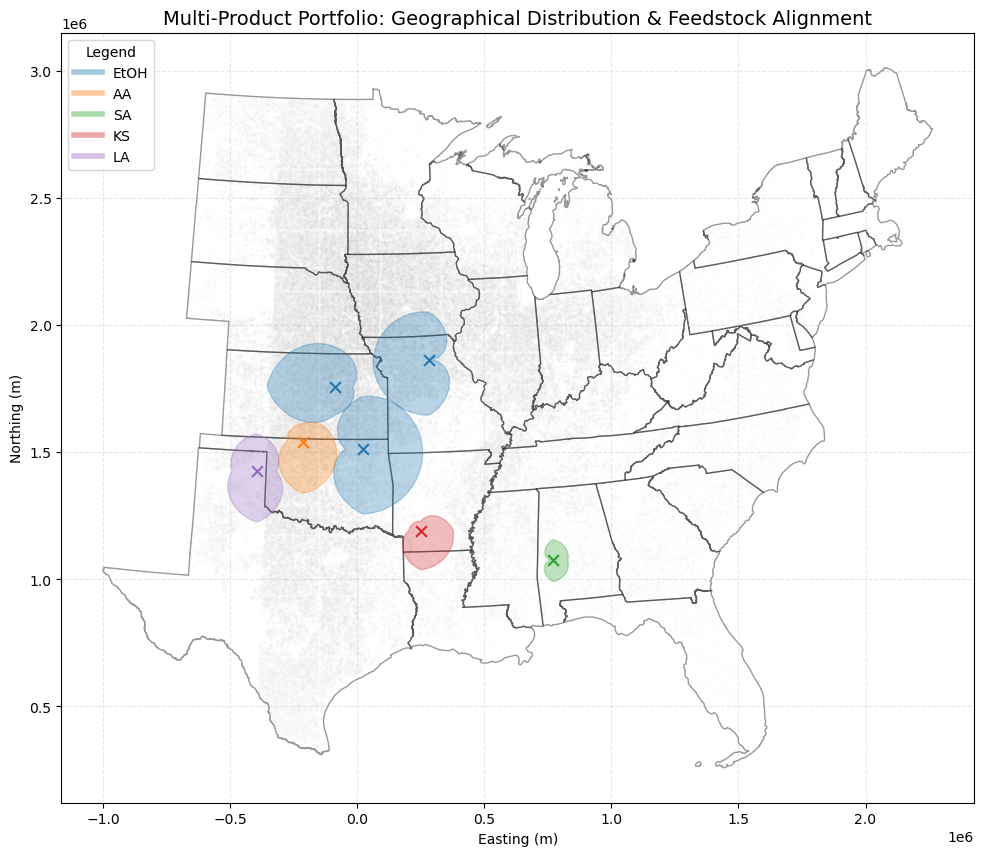

In [284]:
if best_final_coords is not None:
    # 1. Reshape the flat (42,) into (7, 6)
    spatial_coords = best_final_coords.reshape(7, 6)
    
    # 2. Add the 1.0 activation column to make it (7, 7)
    final_layout_matrix = np.hstack([spatial_coords, np.ones((7, 1))])
    
    # 3. Report and Plot
    print("\n" + "="*50)
    print("FINAL PORTFOLIO PERFORMANCE REPORT")
    print("="*50)
    df_performance = analyze_portfolio_performance(final_layout_matrix)
    display(df_performance)
    
    plot_multiproduct_results(final_layout_matrix, USE_CIRCULAR=False)

In [282]:
import os
import numpy as np

# 1. Create the directory
folder_name = "Opt_multi_2perc_sim"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)
    print(f"Created directory: {folder_name}")

if best_final_coords is not None:
    # 2. Reshape and Prepare Matrix
    # We turn the flat (42,) into (7, 6) then add the activation column (7, 7)
    spatial_coords = best_final_coords.reshape(7, 6)
    final_layout_matrix = np.hstack([spatial_coords, np.ones((7, 1))])
    
    # 3. Save Raw Flat Coordinates (best for reloading into optimizer)
    coords_path = os.path.join(folder_name, "best_coords_40trials_400_sim.npy")
    np.save(coords_path, best_final_coords)
    
    # 4. Save the Final Layout Matrix (best for plotting later)
    matrix_path = os.path.join(folder_name, "final_layout_matrix_40trials_400_sim.npy")
    np.save(matrix_path, final_layout_matrix)
    
    # 5. Save the Refinery Assignment
    assignment_path = os.path.join(folder_name, "assignment_order_40trials_400_sim.npy")
    np.save(assignment_path, np.array(REFINERY_ASSIGNMENT))
    
    # 6. Generate and Save the Performance Report
    df_performance = analyze_portfolio_performance(final_layout_matrix)
    csv_path = os.path.join(folder_name, "performance_report_40trials_400_sim.csv")
    df_performance.to_csv(csv_path, index=False)
    
    # 7. Print Summary
    print("\n" + "="*50)
    print("FINAL PORTFOLIO SAVED SUCCESSFULLY")
    print("="*50)
    print(f"✅ Directory: /{folder_name}")
    print(f"    - Flat Coords: best_coords_simultaneous.npy")
    print(f"    - Layout Matrix: final_layout_matrix.npy")
    print(f"    - CSV Report: performance_report.csv")
    
    # Optional: Display the report one last time
    display(df_performance)

else:
    print("⚠️ No best_final_coords found. Saving aborted.")


PORTFOLIO ANALYSIS SUMMARY
Total Extra Revenue: $589.83
Target Demand Fulfillment:
 - EtOH: 960.00 / 320 (300.0%)
 - AA: 426.00 / 426.0 (100.0%)
 - SA: 26.50 / 26.5 (100.0%)
 - KS: 20.00 / 20.0 (100.0%)
 - LA: 250.00 / 250.0 (100.0%)

FINAL PORTFOLIO SAVED SUCCESSFULLY
✅ Directory: /Opt_multi_2perc_sim
    - Flat Coords: best_coords_simultaneous.npy
    - Layout Matrix: final_layout_matrix.npy
    - CSV Report: performance_report.csv


,Refinery,Product,Activation (s),Area (km2),Feedstock (Tons),Prod Volume,Unit,MSP ($),Market Price ($),Profit/Unit ($),Extra Revenue ($)
0,1_EtOH,EtOH,1.0,131719.78,3539823.0,320.0,MMgal,2.606,2.840,0.234,74.79
1,2_EtOH,EtOH,1.0,98013.12,3539823.0,320.0,MMgal,2.648,2.840,0.192,61.52
2,3_EtOH,EtOH,1.0,80605.73,3539823.0,320.0,MMgal,2.783,2.840,0.057,18.18
3,4_AA,AA,1.0,80544.23,1735036.0,426.0,10^6 kg,1.538,1.525,-0.013,-5.58
4,5_LA,LA,1.0,42318.94,780129.0,250.0,10^6 kg,1.555,3.115,1.560,390.01
5,6_SA,SA,1.0,5486.18,122361.0,26.5,10^6 kg,1.363,3.260,1.897,50.27
6,7_KS,KS,1.0,30512.35,304341.0,20.0,10^6 kg,7.088,7.120,0.032,0.64


# Single-product Optimization

## Simultaneous single-product approach

In [127]:
import numpy as np
from scipy.optimize import differential_evolution, minimize, NonlinearConstraint, Bounds


In [111]:
## This is to be able to ask the model to use circular collection areas instead of irregular (circular = True)
def expand_simultaneous_vars(x, n_refineries, circular=False):
    """Expands optimizer vector to full (N, 6) matrix."""
    if circular:
        # x is (N*3,) -> [x1, y1, R1, x2, y2, R2...]
        x_r = x.reshape((n_refineries, 3))
        # Replicate R 4 times to fill r1, r2, r3, r4
        radii_expanded = np.repeat(x_r[:, 2:3], 4, axis=1) 
        return np.hstack([x_r[:, :2], radii_expanded]) # Returns (N, 6)
    else:
        return x.reshape((n_refineries, 6))

## Only when Target mode is True
def expand_simultaneous_vars_active(x, n_refineries, circular=False):
    """
    Expands flat vector to (N, 7) matrix: [x, y, r1, r2, r3, r4, s]
    Input x shape: (N * 4) if circular else (N * 7)
    """
    if circular:
        # x = [x1, y1, R1, s1, x2, y2, R2, s2...]
        x_r = x.reshape((n_refineries, 4))
        centers = x_r[:, :2]
        radii_expanded = np.repeat(x_r[:, 2:3], 4, axis=1)
        activations = x_r[:, 3:4]
        return np.hstack([centers, radii_expanded, activations])
    else:
        # x = [x1, y1, r1, r2, r3, r4, s1...]
        return x.reshape((n_refineries, 7))

In [113]:

## New overlap constraint with more strict overlapping rule
def get_directional_radius_np(angles_target, radii_4):
    """Interpolates radius in a specific direction using East, North, West, South radii."""
    # 0=East, pi/2=North, pi=West, 3pi/2=South
    angles_data = np.linspace(0, 2 * np.pi, 4, endpoint=False) 
    return np.interp(angles_target, angles_data, radii_4, period=2*np.pi)



In [114]:
## If target_mode = True
def objective_unified_active(x, lambda_size, is_polish=False, return_components=False, 
                             circular=False, S_target_individual=400, strict_size_constraint=True,
                             data_gap=True, boundary=True, target_mode=False, S_total_target=1500):
    global N
    
    # 1. Expand variables
    data = expand_simultaneous_vars_active(x, N, circular)
    centers, activations = data[:, :2], data[:, 6]
    
    # --- SAFETY: Force activations to be 0-1 range regardless of optimizer overshoot ---
    # activations = np.clip(activations, 0.0, 1.0)
    activations = np.ones_like(activations) # force them to be all = 1

    # 2. Geography Guardrail
    if boundary:
        dist_vals = get_boundary_distance_vectorized(centers)
        total_violation = np.sum(np.maximum(0, dist_vals))
        if total_violation > 0:
            return 1e8 + total_violation * 10000

    # 3. Predictions
    # Force X_norm to be exactly [0, 1] to prevent RBF extrapolation errors
    X_norm = np.clip((data[:, :6] - X_min) / (X_max - X_min), 0.0, 1.0)
    
    cost_pred = np.maximum(0.1, predict_batch_rbf_costs(X_norm, model_costs_total, scale_costs_total, y1_min, y1_max))
    size_pred = np.maximum(0.1, predict_batch_rbf_size(X_norm, model_size_total, scale_size_total, y2_min, y2_max))
    areas_preds = np.maximum(0.1, calculate_areas_vectorized(data[:, :6].T, 4)/1e6)

    # 4. Effective Size
    raw_size_mmgal = size_pred * areas_preds * ethanol_conversion_factor / gal_to_MMgal
    effective_size_mmgal = raw_size_mmgal #* activations
    total_prod = np.sum(effective_size_mmgal)

    # 5. Numerical Stabilizer
    if total_prod < 1e-2:
        return 1e7 # Hard wall if system is "dead"

    # 6. Economics (Weighted MSP)
    denom_raw = np.maximum(raw_size_mmgal, 1e-3)
    
    # Unit Cost calculation
    # cost_per_ton = (Total Operating Cost) / (Total Tons)
    tons_denominator = (denom_raw * (gal_to_MMgal/ethanol_conversion_factor) * ton_to_kg)
    cost_per_ton = (cost_pred * areas_preds) / np.maximum(tons_denominator, 1e-6)
    
    b_vals, c_vals = b_c_vectorized(centers)
    
    # Calculate Individual MSP
    individual_msp = a * cost_per_ton + (b_vals / denom_raw) + c_vals
    
    # --- CRITICAL FIX: Clip BEFORE the weighted sum ---
    individual_msp = np.clip(individual_msp, 0.1, 500.0) 
    
    # Weighted Average System MSP
    # Formula: sum(Cost_i * Production_i) / Total_Production
    system_msp = np.sum(individual_msp * effective_size_mmgal) / total_prod

    # 7. Penalties
    # # 7. STRICT TOTAL SIZE PENALTY (with +/- 5 MMgal Slack)
    # slack = 5.0
    # diff = total_prod - S_total_target
    
    # # Calculate how much we are outside the [target-5, target+5] window
    # # If within window, violation = 0. If outside, violation = magnitude of error
    # size_violation = np.maximum(0, np.abs(diff) - slack)

    size_penalty = 0.0
    slack = 2.0 # Tightened slack for individual targets

    # PATH A: SYSTEM TOTAL (Only if target_mode is True)
    if target_mode:
        # System Target: Force total_prod to equal S_total_target
        sys_diff = np.abs(total_prod - S_total_target)
        sys_violation = np.maximum(0, sys_diff - 5.0) # 5 MMgal slack for system
        size_penalty += lambda_size * (sys_violation / S_total_target)**2

    # PATH B: INDIVIDUAL SIZES
    if strict_size_constraint:
        # Case 1: MUST EQUAL Target (e.g. exactly 400)
        indiv_diff = np.abs(effective_size_mmgal - S_target_individual)
        indiv_violation = np.maximum(0, indiv_diff - slack)
    else:
        # Case 2: MUST NOT EXCEED Target (e.g. <= 400)
        # Only penalize if size > S_target_individual
        indiv_violation = np.maximum(0, effective_size_mmgal - S_target_individual)

    # Add normalized individual penalties
    size_penalty += lambda_size * np.sum((indiv_violation / S_target_individual)**2)

    
    # # We use a quadratic penalty on the violation so it scales with lambda_size
    # # Normalizing by S_total_target keeps the gradient magnitude stable
    # size_penalty = lambda_size * (size_violation / S_total_target)**2
    
    # Sparsity: Keep s_i away from 0.5
    sparsity_push = 1000.0 * np.sum(activations * (1.0 - activations)) # CHANGED 10 TO 1000

    total_objective = system_msp + size_penalty + sparsity_push
    
    # # Inequality: Only penalize if total_prod > S_total_target
    # overage = np.maximum(0.0, total_prod - S_total_target)
    # size_penalty = lambda_size * (overage / S_total_target)**2
    
    # # Sparsity: Keep s_i away from 0.5
    # sparsity_push = 10.0 * np.sum(activations * (1.0 - activations))

    # total_objective = system_msp + size_penalty + sparsity_push
    
    # --- FINAL SAFETY GATE ---
    # If anything went wrong (NaN or negative), return a massive number
    if not np.isfinite(total_objective) or total_objective < 0:
        return 1e9

    # if return_components: 
    #     return float(system_msp), float(size_penalty + sparsity_push)


        # --- UPDATE THIS SECTION AT THE END OF YOUR FUNCTION ---
    if return_components: 
        # Calculate Feedstock vs Refinery components of the MSP
        # a * cost_per_ton is roughly the feedstock/logistics part
        # (b_vals / denom_raw) + c_vals is the refinery CAPEX/OPEX part
        feedstock_component = np.sum((a * cost_per_ton) * effective_size_mmgal) / total_prod
        refinery_component = np.sum(((b_vals / denom_raw) + c_vals) * effective_size_mmgal) / total_prod
        
        return float(system_msp), float(feedstock_component), float(refinery_component), effective_size_mmgal, areas_preds

    # return float(total_objective)
        
    return float(total_objective)

In [115]:
def overlap_con_mod(x, N, target = False):
    # SAFETY: If only one refinery, there is zero overlap violation.
    if N < 2:
        return np.array([0.0]) # Return a single 'safe' value

    x_r = expand_simultaneous_vars(x, N, circular=USE_CIRCULAR)
        
    penalties = []
    

    for i in range(N):
        for j in range(i + 1, N):
            # 1. Basic Geometry
            dx = x_r[j, 0] - x_r[i, 0]
            dy = x_r[j, 1] - x_r[i, 1]
            dist_centers = np.sqrt(dx**2 + dy**2)

            if USE_CIRCULAR:
                # ---- CIRCULAR CASE (Simple) ----
                r_i = x_r[i, 2]
                r_j = x_r[j, 2]
                penalties.append(dist_centers - (r_i + r_j))

            else:
                # ---- IRREGULAR CASE (Two-Step Check) ----
                # Term 1: Directional Radii along the center-to-center line
                angle_i_to_j = np.arctan2(dy, dx) % (2 * np.pi)
                angle_j_to_i = (angle_i_to_j + np.pi) % (2 * np.pi)

                r_i_dir = get_directional_radius_np(angle_i_to_j, x_r[i, 2:])
                r_j_dir = get_directional_radius_np(angle_j_to_i, x_r[j, 2:])
                
                term1 = dist_centers - (r_i_dir + r_j_dir)

                # Term 2: Boundary Sampling (Simulating the "diff2" from your Torch code)
                # We check if the boundary of refinery i contains the center of j, and vice versa.
                # To keep it fast for SciPy, we sample 8 cardinal angles around each refinery.
                sample_angles = np.linspace(0, 2*np.pi, 16, endpoint=False)
                
                # Check points on boundary of i vs center of j
                r_i_samples = get_directional_radius_np(sample_angles, x_r[i, 2:])
                pts_i_x = x_r[i, 0] + r_i_samples * np.cos(sample_angles)
                pts_i_y = x_r[i, 1] + r_i_samples * np.sin(sample_angles)
                
                dist_pts_i_to_cj = np.sqrt((pts_i_x - x_r[j, 0])**2 + (pts_i_y - x_r[j, 1])**2)
                
                # We need the radius of j in the direction of these boundary points to check overlap
                angles_to_pts = np.arctan2(pts_i_y - x_r[j, 1], pts_i_x - x_r[j, 0]) % (2 * np.pi)
                r_j_towards_i = get_directional_radius_np(angles_to_pts, x_r[j, 2:])
                
                term2_i = np.min(dist_pts_i_to_cj - r_j_towards_i)

                # Combine: The constraint is the minimum (strictest) of these clearances
                # If any are negative, the whole thing is a violation.
                penalties.append(min(term1, term2_i))

    return np.array(penalties)

def objective_unified_mod(x, lambda_size, is_polish=False, return_components=False, 
                      circular=False, S_target_individual=400, strict_size_constraint=True,
                      data_gap=True, boundary=True, target_mode=False, S_total_target=1500,
                      lambda_overlap = 1e-3):
    global N

    if np.any(np.isnan(x)) or np.any(np.isinf(x)):
        return 1e8 # Extreme penalty for non-finite inputs
         
    x_reshaped = expand_simultaneous_vars(x, N, circular)
    centers = x_reshaped[:, :2]

    # --- 1. GEOGRAPHIC CHECK ---
    if boundary:
        dist_vals = get_boundary_distance_vectorized(centers)
        total_violation = np.sum(np.maximum(0, dist_vals))
        if total_violation > 0:
            return (2500.0, 1e7 + total_violation * 5000) if return_components else 1e7 + total_violation * 5000

    # --- 2. PREDICTIONS ---
    X_norm = (x_reshaped - X_min) / (X_max - X_min)
    cost_pred = predict_batch_rbf_costs(X_norm, model_costs_total, scale_costs_total, y1_min, y1_max)
    size_pred = predict_batch_rbf_size(X_norm, model_size_total, scale_size_total, y2_min, y2_max)
    areas_preds = calculate_areas_vectorized(x_reshaped.T, 4)/1e6

    # raw_size is the physical potential of the site
    raw_size_mmgal = size_pred * areas_preds * ethanol_conversion_factor / gal_to_MMgal
    
    # --- 3. ACTIVE MASKING ---
    # We ignore refineries smaller than 10.0 MMgal for the system target.
    # This forces the optimizer to either "commit" to a refinery or kill it.
    # active_mask = raw_size_mmgal > 10.0
    # effective_size_mmgal = np.where(active_mask, raw_size_mmgal, 0.0)
    # total_system_production = np.sum(effective_size_mmgal)
    effective_size_mmgal = raw_size_mmgal
    total_system_production = np.sum(raw_size_mmgal)

    # --- 4. ECONOMICS ---
    # Note: Use raw_size for unit math to avoid division by zero, 
    # but we only care about the MSP of active sites.
    safe_raw_size = np.maximum(raw_size_mmgal, 1e-6)
    cost_per_ton = (cost_pred * areas_preds) / (safe_raw_size * (gal_to_MMgal/ethanol_conversion_factor) * ton_to_kg)
    
    b_vals, c_vals = b_c_vectorized(centers)
    individual_msp = a * cost_per_ton + (b_vals / safe_raw_size) + c_vals
    
    if total_system_production < 1.0:
        system_msp = 2500.0 # Penalty for no production
    else:
        # Weighted average of ONLY active refineries
        # system_msp = np.sum(individual_msp[active_mask] * effective_size_mmgal[active_mask]) / total_system_production
        system_msp = np.sum(individual_msp * effective_size_mmgal) / total_system_production

    # --- 5. PENALTIES ---
    size_penalty = 0
    if not target_mode:
        # Standard: Every refinery must hit S_target_individual
        size_diff = (raw_size_mmgal - S_target_individual) / S_target_individual
        size_penalty = lambda_size * np.sum(size_diff**2 if strict_size_constraint else np.maximum(0, size_diff)**2)
    else:
        # Target Mode: System total vs S_total_target
        total_diff = (total_system_production - S_total_target) / S_total_target
        size_penalty = lambda_size * (total_diff**2)
        
        # Individual Ceiling: No single site > individual cap
        size_penalty += lambda_size * np.sum(np.maximum(0, raw_size_mmgal - S_target_individual)**2)

    # Overlap and Data Gap
    overlap_penalty = 0
    if N > 1 and not is_polish:
        penalties = overlap_con_mod(x, N)
        overlap_penalty = lambda_overlap * np.sum(np.maximum(0, -penalties)**2)

    data_gap_penalty = 0
    if data_gap:
        # data_gap_penalty = 1e6 * np.sum(np.maximum(0, 0.08 - cost_per_ton[active_mask])**2)
        data_gap_penalty = 1e6 * np.sum(np.maximum(0, 0.08 - cost_per_ton)**2)

    total_penalty = size_penalty + overlap_penalty + data_gap_penalty

    # if np.random.rand() < 0.001: 
    #     print(f"\n[DEBUG SNAPSHOT]")
    #     print(f"  System MSP:      {system_msp:12.2f}")
    #     print(f"  Size Penalty:    {size_penalty:12.2f}")
    #     print(f"  Overlap Penalty: {overlap_penalty:12.2f}")
    #     print(f"  Data Gap Pen:    {data_gap_penalty:12.2f}")
    #     print(f"  TOTAL Objective: {system_msp + total_penalty:12.2f}")
    #     # if 'boundary_penalty' in locals():
    #     #     print(f"  Boundary Pen:    {boundary_penalty:12.2f}")

    if return_components:
        return float(system_msp), float(total_penalty)
    return float(system_msp + total_penalty)

In [117]:
def size_con_sim_flex(x, circular=False, S_target_individual=400, 
                      strict_size_constraint=True, target_mode=False, S_total_target=1500):
    # 1. Predictions (N refineries at once)
    x_reshaped = expand_simultaneous_vars(x, N, circular)
    X_norm = (x_reshaped - X_min) / (X_max - X_min)
    
    size_pred = predict_batch_rbf_size(X_norm, model_size_total, scale_size_total, y2_min, y2_max)
    areas_preds = calculate_areas_vectorized(x_reshaped.T, 4)/1e6
    size_mmgal = size_pred * areas_preds * ethanol_conversion_factor / gal_to_MMgal
    
    if not target_mode:
        # --- MODE A: N INDIVIDUAL TARGETS ---
        # Returns an array of N violations
        if strict_size_constraint:
            # Must be exactly S_target_individual
            return size_mmgal - S_target_individual
        else:
            # Must be <= S_target_individual
            return np.maximum(0, size_mmgal - S_target_individual)
            
    else:
        # --- MODE B: TOTAL SYSTEM TARGET ---
        # 1. Calculate the System Violation (Scalar)
        total_capacity = np.sum(size_mmgal)
        if strict_size_constraint:
            # System must hit exactly S_total_target
            system_violation = total_capacity - S_total_target
        else:
            # System must be <= S_total_target
            system_violation = np.maximum(0, total_capacity - S_total_target)
            
        # 2. Individual Ceiling Violation (Array of N)
        # Even in target mode, we usually don't want any single refinery 
        # to exceed the individual cap.
        individual_ceilings = np.maximum(0, size_mmgal - S_target_individual)
        
        # Combine: System scalar concatenated with individual array
        # This gives the optimizer N+1 constraints to satisfy
        return np.concatenate(([system_violation], individual_ceilings))

In [118]:
class StopIfNoImprovement:
    def __init__(self, obj_fun, args=(), patience=30, atol=1e-4):
        self.obj_fun = obj_fun
        self.args = args
        self.patience = patience
        self.atol = atol
        self.best = np.inf
        self.counter = 0

    def __call__(self, xk, convergence):
        f = self.obj_fun(xk, *self.args)

        if self.best - f > self.atol:
            self.best = f
            self.counter = 0
        else:
            self.counter += 1

        # Returning True tells SciPy to stop
        return self.counter >= self.patience



In [119]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

def plot_optimization_results_mod(history, n=1, target_mode=True):
    # 1. Handle Input (Detecting if it's the wrapper dict or the raw history)
    if isinstance(history, dict) and 'History' in history:
        h = history['History']
    else:
        h = history

    fig, ax = plt.subplots(figsize=(12, 10))

    # 2. Background Layer: Feedstock Potential
    if 'inputs' in globals():
        ax.scatter(inputs[:,0], inputs[:,1], c='gray', alpha=0.05, s=0.01, label='Feedstock Potential', zorder=0)

    # 3. Feasibility Filtering
    costs = np.array(h['costs'])
    feasibility = np.array(h['feasibility'])
    results = h['results']
    feasible_idx = np.where(feasibility == True)[0]
    
    if len(feasible_idx) == 0:
        print("WARNING: No feasible solutions found. Plotting best available.")
        sorted_indices = np.argsort(costs)
        ax.set_title("UNFEASIBLE SOLUTIONS (Failed Constraints)")
    else:
        # Sort feasible trials by cost
        feasible_costs = costs[feasible_idx]
        sorted_indices = feasible_idx[np.argsort(feasible_costs)]
        ax.set_title(f"Best Feasible Layout (Cost: {costs[sorted_indices[0]]:.4f} $/gal)")

    # 4. Color Palette (Fixed per refinery index)
    # Ref 0: Blue, Ref 1: Orange, Ref 2: Green, Ref 3: Red, Ref 4: Purple, etc.
    refinery_colors = list(mcolors.TABLEAU_COLORS.values()) 

    # 5. Plotting Loop (Top n trials)
    for ii, idx in enumerate(sorted_indices[:n]):
        trial_vars = results[idx] # Shape (N, 7) or (N, 6)
        
        for k in range(trial_vars.shape[0]):
            # --- Activation Check (Target Mode) ---
            # --- Replacement for the radii_data logic in Step 5 ---
            if target_mode:
                s_val = trial_vars[k, -1]
                if s_val < 0.1: continue # Skip if refinery is "off"
                # Slice only the 4 shape params: index 2, 3, 4, 5
                radii_data = trial_vars[k, 2:6] if not USE_CIRCULAR else trial_vars[k, 2:3]
            else:
                s_val = 1.0
                # FIX: Change 2: to 2:6 to avoid grabbing the 's' parameter at index 6
                radii_data = trial_vars[k, 2:6] if not USE_CIRCULAR else trial_vars[k, 2:3]

            x_center, y_center = trial_vars[k, 0], trial_vars[k, 1]
            current_color = refinery_colors[k % len(refinery_colors)]

            # --- Drawing Geometry ---
            if not USE_CIRCULAR:
                angles_plot = np.linspace(0, 2 * np.pi, 100)
                r_interpolated = get_directional_radius_np(angles_plot, radii_data)
                
                x_s = x_center + r_interpolated * np.cos(angles_plot)
                y_s = y_center + r_interpolated * np.sin(angles_plot)
                
                # Plot Fill and Outline
                ax.fill(x_s, y_s, color=current_color, alpha=0.15, zorder=2)
                ax.plot(x_s, y_s, color=current_color, lw=2, alpha=0.8, 
                        label=f"Ref {k+1} (Active)" if ii == 0 else "", zorder=3)
            else:
                r_val = radii_data[0]
                circle = plt.Circle((x_center, y_center), r_val, color=current_color, 
                                    alpha=0.15, ec=current_color, lw=2, zorder=2)
                ax.add_patch(circle)

            # Center point
            ax.scatter(x_center, y_center, color=current_color, s=40, edgecolors='k', zorder=5)

    # 6. Geographic Boundary Layer
    if 'USA_rainfed' in globals():
        USA_rainfed.boundary.plot(ax=ax, color='black', linewidth=1.0, alpha=0.4, zorder=1)

    # Formatting
    ax.set_aspect('equal')
    ax.set_xlabel("X Coordinate (m)")
    ax.set_ylabel("Y Coordinate (m)")
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1), fontsize='small')
    plt.tight_layout()
    plt.show()

In [120]:
import time
import math

In [121]:
def pass1_fixed_s(N_val, S_total_target, circular = False, indiv_target = 400, 
                 strict = True, target_mode = False, seed = 0, seed_offset = 0):
    global N
    N = N_val
    # 1. Setup Bounds (N * 6)
    
    # 1. Determine number of spatial parameters per refinery
    # Irregular: 6 (x, y, r1, r2, r3, r4)
    # Circular: 3 (x, y, R)
    n_params = 3 if circular else 6
    
    lb_unit = X_min[:n_params]
    ub_unit = X_max[:n_params]
    
    lb = np.tile(lb_unit, N_val)
    ub = np.tile(ub_unit, N_val)
    
    # Use the correct size for bounds
    bounds = list(zip(lb, ub))

    # 2. Objective Wrapper (Inject s=1.0)
    def obj_wrapper(x_spatial, *args):
        x_full = np.hstack([x_spatial.reshape((N_val, 6)), np.ones((N_val, 1))]).flatten()
        return objective_unified_active(x_full, *args)

## Args objective_unified_active(x, lambda_size, is_polish=False, return_components=False, 
                             # circular=False, S_target_individual=400, strict_size_constraint=True,
                             # data_gap=True, boundary=True, target_mode=False, S_total_target=1500):

### Args  objective_unified(x, lambda_size, is_polish=False, return_components=False, 
                     #  circular=False, S_target=400, strict_size_constraint=True,
                     # data_gap = True, boundary = True):

    # 3. Global Phase (DE)
    result_de = differential_evolution(
        # obj_wrapper,
        objective_unified_mod,
        bounds=bounds,
        args=(10.0, False, False, circular, indiv_target, strict, True, True, 
              target_mode, S_total_target, 1e-11), # Last True or False is target mode
        ## Cambie strict size to True y target mode to False
        maxiter=250, popsize=30,
        mutation=(0.5, 1.0), #see if worth including
        seed=seed + seed_offset
    )

    # 4. Phase 2: Local Polish (trust-constr)
    # IMPORTANT: We must wrap constraints so they "see" the s=1.0 we are holding fixed
    def con_wrapper(x_spatial, constraint_func):
        x_full = np.hstack([x_spatial.reshape((N_val, 6)), np.ones((N_val, 1))]).flatten()
        return constraint_func(x_full)

    nl_constraints = []
        # Overlap
        # NonlinearConstraint(lambda x: con_wrapper(x, lambda x_f: overlap_con(x_f, True)), 0.0, np.inf),
        # # Boundary
        # NonlinearConstraint(
        #     lambda x: con_wrapper(x, lambda x_f: get_boundary_distance_vectorized(
        #         expand_simultaneous_vars_active(x_f, N_val, False)[:, :2])),
        #     lb=-np.inf, ub=-100000.0
        # ),
        # # Size (Note: target_mode=True here to use your S_total_target logic)
        # # def size_con_sim_active(x, circular=False, S_target_individual=400, 
        # #                 strict_size_constraint=True, target_mode=True, S_total_target=1500):
        # NonlinearConstraint(
        #     lambda x: con_wrapper(x, lambda x_f: size_con_sim_active(x_f, False, 400, True, False, S_total_target)),
        #     ## Cambie strict size to True y Target mode to False
        #     lb=np.append([-5.0], np.full(N_val, -np.inf)), 
        #     ub=np.append([5.0], np.zeros(N_val))
        # )

    # 1. Overlap (Using the corrected active-aware version)
    # if N > 1:
    #     nl_constraints.append(
    #         NonlinearConstraint(lambda x: overlap_con(x, target=target_mode), 0.0, np.inf)
    #     )
    if N_val > 1:
        nl_constraints.append(
            # Pass N_val into the overlap function
            NonlinearConstraint(lambda x: overlap_con_mod(x, N_val, target=target_mode), 0.0, np.inf)
        )

    nl_constraints.append(
        NonlinearConstraint(
            lambda x: get_boundary_distance_vectorized(x.reshape(N_val, n_params)[:, :2]),
            lb=-np.inf, ub=-100000.0
        )
    )

    num_constraints = 1 + N_val if target_mode else N_val

    # nl_constraints.append(
    #     NonlinearConstraint(
    #         lambda x: size_con_sim_flex(x, circular, indiv_target, strict, target_mode, S_total_target),
    #         lb=np.full(num_constraints, -5.0), # Array of lower bounds
    #         ub=np.full(num_constraints, 5.0)   # Array of upper bounds
    #     )
    # )
    if target_mode:
        # lb/ub for [System_Total, Ref_1_Ceiling, Ref_2_Ceiling...]
        # System Total: ±5.0 MMgal tolerance
        # Individual: -infinity to 0.0 (meaning it can be small, just not > 400)
        lower_bounds = np.concatenate([[-5.0], np.full(N_val, -np.inf)])
        upper_bounds = np.concatenate([[5.0], np.zeros(N_val)])
    else:
        # Standard Mode: Each ref must be ±5.0 MMgal from indiv_target
        lower_bounds = np.full(N_val, -5.0)
        upper_bounds = np.full(N_val, 5.0)

    nl_constraints.append(
        NonlinearConstraint(
            lambda x: size_con_sim_flex(x, circular, indiv_target, strict, target_mode, S_total_target),
            lb=lower_bounds,
            ub=upper_bounds
        )
    )

# def size_con_sim_flex(x, circular=False, S_target_individual=400, 
#                       strict_size_constraint=True, target_mode=False, S_total_target=1500)

    result_final = minimize(
        # obj_wrapper,
        objective_unified_mod,
        result_de.x,
        method='trust-constr',
        bounds=Bounds(lb, ub),
        constraints=nl_constraints,
        args=(10, True, False, circular, indiv_target, strict, True, True, target_mode, S_total_target,0),
  
        ## Cambie strict size to True y Target mode to False
        # options={'maxiter': 4000, 'verbose': 1}
        options={'maxiter': 4000, 'verbose': 1, 'xtol': 1e-6, 'gtol': 1e-6}
    )

    return result_final

In [122]:
import os


--- TRIAL 1 (Patience: 0/200) ---


/Users/bianco3/opt/anaconda3/envs/TorchML/lib/python3.9/site-packages/scipy/optimize/_trustregion_constr/equality_constrained_sqp.py:203: UserWarning: Singular Jacobian matrix. Using SVD decomposition to perform the factorizations.
  Z, LS, Y = projections(A, factorization_method)
/Users/bianco3/opt/anaconda3/envs/TorchML/lib/python3.9/site-packages/scipy/optimize/_trustregion_constr/equality_constrained_sqp.py:80: UserWarning: Singular Jacobian matrix. Using SVD decomposition to perform the factorizations.
  Z, LS, Y = projections(A, factorization_method)


`xtol` termination condition is satisfied.
Number of iterations: 432, function evaluations: 10374, CG iterations: 1005, optimality: 6.27e-06, constraint violation: 0.00e+00, execution time: 2e+01 s.
✅ Feasible. Score: 2.755365
⭐ New Best Found! (Improvement: inf)
Trial 1 Score: 2.755365

--- TRIAL 2 (Patience: 0/200) ---
`xtol` termination condition is satisfied.
Number of iterations: 1360, function evaluations: 34086, CG iterations: 6402, optimality: 2.52e-06, constraint violation: 0.00e+00, execution time: 6.7e+01 s.
✅ Feasible. Score: 2.675149
⭐ New Best Found! (Improvement: 0.080215)
Trial 2 Score: 2.675149

Optimization Finished. Best Feasible Score: 2.675149


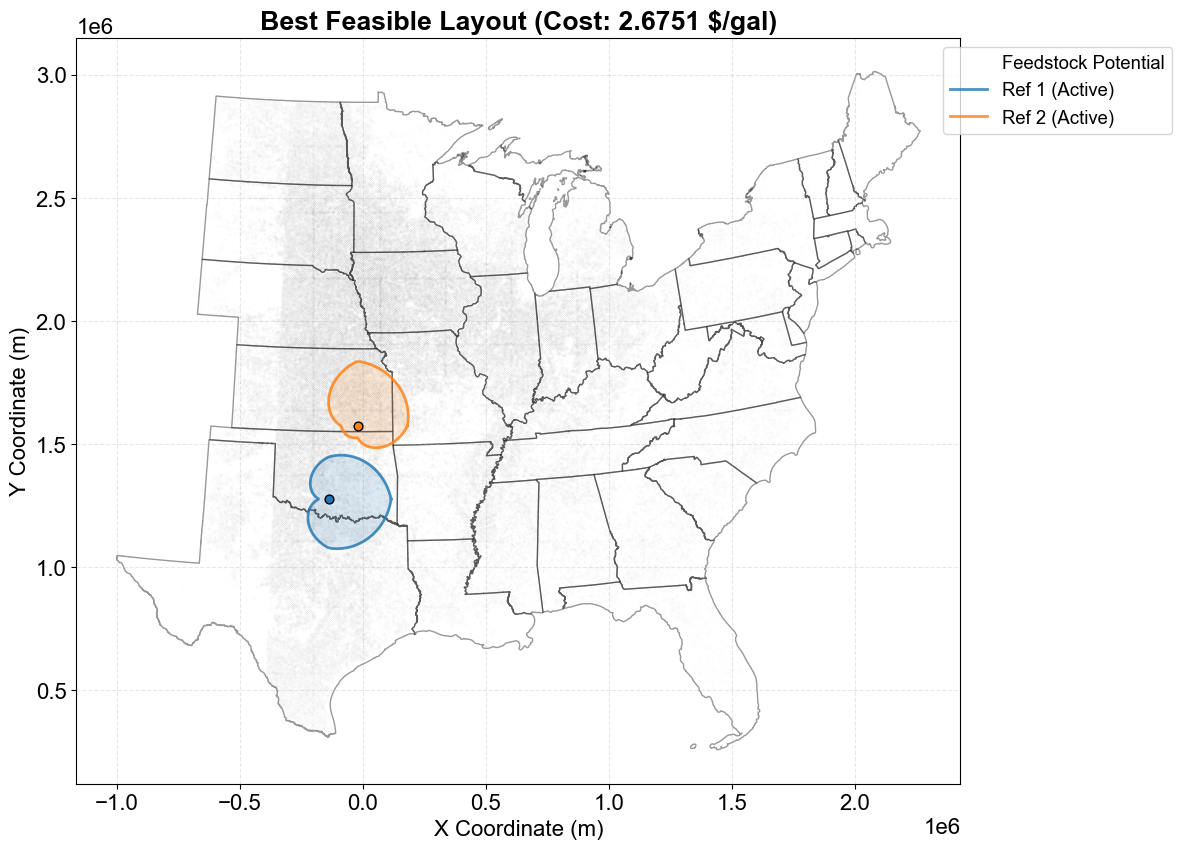

📁 Created folder: Outputs_2perc_Sim_vs_Seq
💾 Results saved to: Outputs_2perc_Sim_vs_Seq/history_570_sim_0.pkl
CPU times: user 5min 2s, sys: 1.11 s, total: 5min 3s
Wall time: 5min 6s


In [123]:
%%time

# --- Configuration ---

N_test = 2
target = 570
trial_num = 2 # small for testing
USE_CIRCULAR = False
indiv_target = 400
strict = False
target_mode = True

# --- Patience & Tracking Setup ---
patience = 200             # Number of trials to wait for improvement
min_delta = 1e-4        # Minimum improvement to reset patience
best_feasible_score = np.inf
best_layout_overall = None
patience_counter = 0
seed_offset = 0 #1500+29+80

history = {
    'costs': [],
    'feasibility': [],
    'results': []
}

for i in range(trial_num):
    print(f"\n--- TRIAL {i+1} (Patience: {patience_counter}/{patience}) ---")
    
    try:
        # 1. Attempt the optimization
        res1 = pass1_fixed_s(N_test, target, USE_CIRCULAR, indiv_target, 
                             strict, target_mode, seed=i, seed_offset=seed_offset) 
        
    except np.linalg.LinAlgError as e:
        # 2. Handle the SVD/Linear Algebra crash gracefully
        print(f"💥 TRIAL {i+1} CRASHED: Numerical singularity (LinAlgError). Skipping...")
        history['costs'].append(999.0)
        history['feasibility'].append(False)
        history['results'].append(None) # Or a dummy array of zeros
        patience_counter += 1
        continue # Move to the next iteration of the loop
        
    except Exception as e:
        # 3. Optional: Catch any other unexpected errors to keep the loop alive
        print(f"⚠️ Unexpected error at trial {i+1}: {e}")
        history['costs'].append(999.0)
        history['feasibility'].append(False)
        history['results'].append(None)
        patience_counter += 1
        continue

    # --- SUCCESSFUL EXECUTION PATH ---
    # (The rest of your logic remains the same, but now it only runs if no error occurred)
    
    if res1.constr_violation > 1.0:
        print(f"❌ Infeasible (Violation: {res1.constr_violation:.2f})")
        history['costs'].append(999)
        history['feasibility'].append(False)
        
        n_params = 3 if USE_CIRCULAR else 6
        raw_spatial = res1.x.reshape(N_test, n_params)
        if USE_CIRCULAR:
            spatial_coords = np.hstack([raw_spatial[:, :2], np.tile(raw_spatial[:, 2:], 4)])
        else:
            spatial_coords = raw_spatial
        history['results'].append(np.hstack([spatial_coords, np.ones((N_test, 1))]))
        
        patience_counter += 1 
        
    else:    
        print(f"✅ Feasible. Score: {res1.fun:.6f}")
        
        n_params = 3 if USE_CIRCULAR else 6
        raw_spatial = res1.x.reshape(N_test, n_params)
        if USE_CIRCULAR:
            spatial_coords = np.hstack([raw_spatial[:, :2], np.tile(raw_spatial[:, 2:], 4)])
        else:
            spatial_coords = raw_spatial
            
        final_layout = np.hstack([spatial_coords, np.ones((N_test, 1))])
    
        history['costs'].append(res1.fun)
        history['feasibility'].append(True)
        history['results'].append(final_layout)
        
        if res1.fun < (best_feasible_score - min_delta):
            print(f"⭐ New Best Found! (Improvement: {best_feasible_score - res1.fun:.6f})")
            best_feasible_score = res1.fun
            best_layout_overall = final_layout
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"⌛ No significant improvement.")

    if patience_counter >= patience:
        print(f"\n🛑 Early stopping triggered after {i+1} trials.")
        break
    
    print(f"Trial {i+1} Score: {res1.fun:.6f}")

print("\n" + "="*30)
if best_layout_overall is not None:
    print(f"Optimization Finished. Best Feasible Score: {best_feasible_score:.6f}")
else:
    print("Optimization Finished. No feasible solution found.")

# After the loop, call your function
plot_optimization_results_mod(history, n=1, target_mode=target_mode)

# # --- Directory and Filename Setup ---
# output_dir = "Outputs_2perc_Circ_vs_Irr"
# if not os.path.exists(output_dir):
#     os.makedirs(output_dir)
#     print(f"📁 Created folder: {output_dir}")

# shape_str = "circ" if USE_CIRCULAR else "irr"
# filename = f"history_N{N_test}_{shape_str}.pkl"
# save_path = os.path.join(output_dir, filename)

output_dir = "Outputs_2perc_Sim_vs_Seq"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"📁 Created folder: {output_dir}")

shape_str = "sim" 
filename = f"history_{target}_{shape_str}_{seed_offset}.pkl"
save_path = os.path.join(output_dir, filename)

# --- Save Results ---
with open(save_path, 'wb') as f:
    pickle.dump(history, f)
print(f"💾 Results saved to: {save_path}")

In [643]:
# Extract the best feasible result from history
costs = np.array(history['costs'])
feasibility = np.array(history['feasibility'])
feasible_idx = np.where(feasibility == True)[0]

if len(feasible_idx) > 0:
    best_idx = feasible_idx[np.argmin(costs[feasible_idx])]
    best_layout = history['results'][best_idx]
    print(f"Analyzing Trial {best_idx + 1} (Score: {costs[best_idx]:.4f})")
else:
    print("No feasible solution found to analyze.")

Analyzing Trial 139 (Score: 2.7038)


In [644]:
# 1. Get the results of the best feasible trial
costs = np.array(history['costs'])
feasibility = np.array(history['feasibility'])
feasible_idx = np.where(feasibility == True)[0]

if len(feasible_idx) > 0:
    # Find the index of the trial with the lowest cost
    best_trial_idx = feasible_idx[np.argsort(costs[feasible_idx])[0]]
    best_layout = history['results'][best_trial_idx] # Shape (N, 7)
    
    print(f"--- Production Sizes for Best Trial (Trial {best_trial_idx + 1}) ---")
    
    # 2. Pass the layout through the prediction functions
    # We strip the 's' parameter (column 6) for the spatial prediction
    x_spatial = best_layout[:, :6]
    # s_params = best_layout[:, 6]
    
    # Normalize and Predict
    X_norm = (x_spatial - X_min[:6]) / (X_max[:6] - X_min[:6])
    size_pred = predict_batch_rbf_size(X_norm, model_size_total, scale_size_total, y2_min, y2_max)
    
    # Calculate Areas (using your existing function)
    # Note: ensure calculate_areas_vectorized handles (N, 6) or (6, N) accordingly
    areas_preds = calculate_areas_vectorized(x_spatial.T, 4) / 1e6
    
    # Final Capacity Calculation: Potential * Area * Conversion * Scale(s)
    sizes_mmgal = size_pred * areas_preds * ethanol_conversion_factor / gal_to_MMgal #* s_params
    
    for i, size in enumerate(sizes_mmgal):
        print(f"Refinery {i+1}: {size:.2f} MMgal/yr")
    
    print(f"Total System: {np.sum(sizes_mmgal):.2f} MMgal/yr")
else:
    print("No feasible trials found to report sizes.")

--- Production Sizes for Best Trial (Trial 139) ---
Refinery 1: 337.06 MMgal/yr
Refinery 2: 283.77 MMgal/yr
Refinery 3: 326.10 MMgal/yr
Total System: 946.93 MMgal/yr


In [520]:
# 1. Configuration and Folder Setup
folder_name = "Opt_2perc_Target"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)
    print(f"Created folder: {folder_name}")

# 3. Save the results to the folder
file_path = os.path.join(folder_name, "optimization_history_N4_v1.pkl")
with open(file_path, 'wb') as f:
    pickle.dump(history, f)

print(f"\n✅ All {trial_num} trials saved to: {file_path}")


✅ All 25 trials saved to: Opt_2perc_Target/optimization_history_N4_v1.pkl


In [518]:
def generate_refinery_report(layout, target):
    # Call the updated objective function
    msp, f_comp, r_comp, individual_caps, individual_areas = objective_unified_active(
        layout.flatten(), 0.1, True, True, False, 400, False, True, True, True, target
    )

    print("\n" + "="*50)
    print(f"      FINAL REFINERY REPORT (Target: {target} MMgal)")
    print("="*50)
    total_size = 0
    active_areas = []
    
    for i in range(len(individual_caps)):
        s_val = layout.reshape(-1, 7)[i, -1]
        cap = individual_caps[i]
        area = individual_areas[i]
        
        if s_val > 0.1:
            active_areas.append(area)
            total_size += cap
            status = "✅ ACTIVE"
        else:
            status = "❌ INACTIVE"
            
        print(f"Refinery {i+1}: {status}")
        print(f"  - Activation (s): {s_val:.2%}")
        print(f"  - Output:         {cap:.2f} MMgal")
        print(f"  - Collection Area:  {area:.2f} km²")
        print("-" * 30)
        
    avg_area = np.mean(active_areas) if active_areas else 0
    
    print(f"\nTOTAL SYSTEM MSP: ${msp:.4f} /gal")
    print(f"  ▶ Average Collection Area: {avg_area:.2f} km²")
    print(f"  ▶ Avg Yield Efficiency:    {np.sum(individual_caps)/avg_area if avg_area > 0 else 0:.4f} MMgal/km²")
    print(f"  ▶ Total size: {total_size:.4f} MMgal")
    print(f"  ▶ Feedstock & Logistics: ${f_comp:.4f} ({ (f_comp/msp)*100 :.1f}%)")
    print(f"  ▶ Refinery CAPEX/OPEX:   ${r_comp:.4f} ({ (r_comp/msp)*100 :.1f}%)")

    # # Visualize the Area vs Output
    # fig, ax1 = plt.subplots(figsize=(10, 5))
    # indices = np.arange(len(individual_caps)) + 1
    
    # ax1.bar(indices - 0.2, individual_caps, 0.4, label='Output (MMgal)', color='skyblue')
    # ax1.set_ylabel('Biofuel Output (MMgal)', color='blue')
    
    # ax2 = ax1.twinx()
    # ax2.bar(indices + 0.2, individual_areas, 0.4, label='Area (km²)', color='salmon')
    # ax2.set_ylabel('Collection Area (km²)', color='red')
    
    # plt.title("Refinery Scale: Production vs. Land Requirement")
    # plt.xticks(indices)
    # plt.show()
    
    # # Visual Breakdown
    # fig, ax = plt.subplots(figsize=(10, 6))
    # labels = ['Feedstock/Logistics', 'Refinery CAPEX/OPEX']
    # # ax.pie([f_comp, r_comp], labels=labels, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
    # ax.set_title("MSP Cost Drivers")
    # plt.show()

# Run the analysis on the best layout found in your 25 trials
generate_refinery_report(best_layout, target)


      FINAL REFINERY REPORT (Target: 1500 MMgal)
Refinery 1: ✅ ACTIVE
  - Activation (s): 100.00%
  - Output:         395.02 MMgal
  - Collection Area:  131298.43 km²
------------------------------
Refinery 2: ✅ ACTIVE
  - Activation (s): 100.00%
  - Output:         313.50 MMgal
  - Collection Area:  161222.37 km²
------------------------------
Refinery 3: ✅ ACTIVE
  - Activation (s): 100.00%
  - Output:         389.76 MMgal
  - Collection Area:  103498.05 km²
------------------------------
Refinery 4: ✅ ACTIVE
  - Activation (s): 100.00%
  - Output:         400.00 MMgal
  - Collection Area:  135884.44 km²
------------------------------

TOTAL SYSTEM MSP: $2.7712 /gal
  ▶ Average Collection Area: 132975.82 km²
  ▶ Avg Yield Efficiency:    0.0113 MMgal/km²
  ▶ Total size: 1498.2808 MMgal
  ▶ Feedstock & Logistics: $1.4021 (50.6%)
  ▶ Refinery CAPEX/OPEX:   $1.3691 (49.4%)


In [250]:
%%time
# --- Constants ---
S_target = 200
N = 5
n_vars = 6
a = 11.07

# Precompute repeated constants
X_min_tile = np.tile(X_min, N)
X_max_tile = np.tile(X_max, N)
range_tile = X_max_tile - X_min_tile

# --- Gradient Boost prediction function ---
def predict_batch_gb(X_norm_batch, model, y_min, y_max):
    """
    X_norm_batch: shape (N, n_vars), already normalized
    Returns real values
    """
    X_norm_batch = np.atleast_2d(X_norm_batch)
    yn_pred = model.predict(X_norm_batch)
    log_y_pred = (1.0 - yn_pred) * (y_max - y_min) + y_min
    y_real = np.exp(log_y_pred)
    return y_real

# --- Objective function ---
def objective(x):
    X_norm = (x - X_min_tile) / range_tile
    X_norm = X_norm.reshape((N, n_vars))

    # Predict all costs and sizes in one call
    cost_pred = predict_batch_gb(X_norm, model_costs, y1_min, y1_max)
    size_pred = predict_batch_gb(X_norm, model_size, y2_min, y2_max)

    cost = cost_pred / (size_pred * ton_to_kg)
    size = size_pred * ethanol_conversion_factor / gal_to_MMgal

    # Compute b and c for all points
    bc_vals = np.array([b_c(x[i*n_vars:i*n_vars+2]) for i in range(N)])
    b_vals, c_vals = bc_vals[:,0], bc_vals[:,1]

    tot_cost = np.sum(a*cost + b_vals/size + c_vals)
    return tot_cost

# --- Constraints ---
def size_constraint(x, i):
    X_norm = (x - X_min_tile) / range_tile
    X_norm = X_norm.reshape((N, n_vars))
    size_pred = predict_batch_gb(X_norm[i:i+1], model_size, y2_min, y2_max)[0]
    size = size_pred * ethanol_conversion_factor / gal_to_MMgal
    return size - S_target

def no_overlap_constraint(x, i, j):
    dist = np.sqrt((x[i*n_vars]-x[j*n_vars])**2 + (x[i*n_vars+1]-x[j*n_vars+1])**2)
    r1 = np.mean(x[i*n_vars+2:(i+1)*n_vars])
    r2 = np.mean(x[j*n_vars+2:(j+1)*n_vars])
    return dist - r1 - r2

# --- Bounds ---
bounds = [(xmin, xmax) for xmin, xmax in zip(X_min, X_max)] * N

# --- Constraints list ---
constraints = (
    [{'type': 'eq', 'fun': lambda x, i=i: size_constraint(x, i)} for i in range(N)] +
    [{'type': 'ineq', 'fun': lambda x, i=i, j=j: no_overlap_constraint(x, i, j)}
     for i in range(N) for j in range(i)]
)

# --- Optimization ---
N_init = 50
opt_vars_sim = np.zeros((N_init, N, n_vars))
cost_vars_sim = np.zeros(N_init)

for n in range(N_init):
    np.random.seed(n)
    x0 = np.concatenate([X[np.random.randint(100000)] for _ in range(N)])
    
    res = minimize(
        objective,
        x0,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-6, 'maxiter': 500}
    )
    
    opt_vars_sim[n] = res.x.reshape((N, n_vars))
    cost_vars_sim[n] = res.fun
    print(f"run {n}, success={res.success}, cost={res.fun}")


run 0, success=False, cost=8.999106044084492
run 1, success=False, cost=8.329981885986255
run 2, success=False, cost=7.972240654114011
run 3, success=False, cost=8.678773225243164
run 4, success=False, cost=8.25538806308437
run 5, success=False, cost=8.803723394456734
run 6, success=False, cost=7.581809402441436
run 7, success=False, cost=8.063422126382765
run 8, success=False, cost=7.838918159599027
run 9, success=False, cost=9.867240007715639
run 10, success=False, cost=8.35322261740319
run 11, success=False, cost=7.4764160556857275
run 12, success=False, cost=8.539414946454007
run 13, success=False, cost=8.734770752371176
run 14, success=False, cost=7.471005682269967
run 15, success=False, cost=8.807740297491582
run 16, success=False, cost=9.684212779667785
run 17, success=False, cost=8.086246070689104
run 18, success=False, cost=7.928823762899322
run 19, success=False, cost=10.441509626976115
run 20, success=False, cost=7.65787039784264
run 21, success=False, cost=8.906944354831797

[87900.89626816 61734.34334047 79380.16222084 56912.15989152
 57073.08440683]
[67751.06218638 54196.69307421 61545.27264855 62130.88896346
 75064.36870706]
[91158.63245037 56825.52367492 80552.68796349 43522.17680124
 60086.71215873]
[71743.32991484 43365.98117809 62266.15097023 59251.29600248
 79027.86782138]
[71016.53567672 77088.90713296 90824.4685933  79402.48653494
 87653.3329933 ]


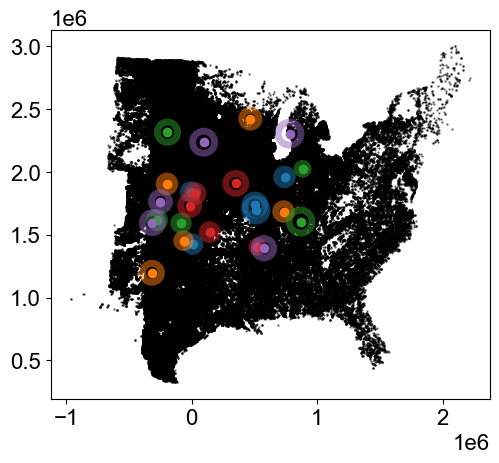

In [251]:
colors = list(mcolors.TABLEAU_COLORS)

fig, ax = plt.subplots()
ax.scatter(X[:,0],X[:,1],c='k',alpha = 0.5, s = 0.5)
for ii,i in enumerate(np.argsort(cost_vars_sim)[:5]):
    
    x = opt_vars_sim[i,:,0]
    y = opt_vars_sim[i,:,1]
    r = np.mean(opt_vars_sim[i][:,2:],axis = -1)
    print(r)
    # for j in range(N):
    #     cost, size = cost_size(opt_vars[i][j*n_vars:j*n_vars+n_vars])
    #     b,c = b_c(opt_vars[i][j*n_vars:j*n_vars+2])
    #     print(cost, size, cost+b/size+c)
    # scatter centers
    ax.scatter(x, y, color = colors[ii])

    # draw circles
    for xi, yi, ri in zip(x, y, r):
        circ = Circle((xi, yi), ri, fill=False, linewidth=5.0, color = colors[ii],alpha = 0.5)
        ax.add_patch(circ)

ax.set_aspect('equal')   # IMPORTANT for circles

plt.show()

In [255]:
# 1️⃣ Get the indices of the 5 smallest costs
top5_idx = np.argsort(cost_vars_sim)[:5]
print("Top 5 indices:", top5_idx)

# 2️⃣ Filter the optimized variables for these top 5
top5_opt_vars = opt_vars_sim[top5_idx]  # shape (5, N, n_vars)

# 3️⃣ Calculate real costs and sizes using gradient boosting
top5_costs = []
top5_sizes = []

# 2️⃣ Prepare array to store objectives per refinery
top5_objectives_per_refinery = np.zeros((5, N))

for n, x_sol in enumerate(top5_opt_vars):
    for i in range(N):
        # Normalize features
        X_norm = (x_sol[i] - X_min) / (X_max - X_min)

        # Predict cost and size with gradient boosting
        cost_pred = predict_batch_gb(X_norm, model_costs, y1_min, y1_max)
        size_pred = predict_batch_gb(X_norm, model_size, y2_min, y2_max)

        # Convert to real-world units
        cost_real = cost_pred / (size_pred * ton_to_kg)   # $/kg
        size_real = size_pred * ethanol_conversion_factor / gal_to_MMgal  # MMgal/yr

        # Calculate b and c for this point
        b, c = b_c(x_sol[i][:2])

        # Compute objective for this refinery
        a = 11.07
        top5_objectives_per_refinery[n, i] = a * cost_real + b / size_real + c

print("Objective values for each refinery in the top 5 solutions:")
print(top5_objectives_per_refinery)



Top 5 indices: [44 14 11 25 43]
Objective values for each refinery in the top 5 solutions:
[[1.51963673 1.44204208 1.51640633 1.5180899  1.46866984]
 [1.74865629 1.45160205 1.42463819 1.42090304 1.42520611]
 [1.35565175 1.50847223 1.43529228 1.6238293  1.55317049]
 [1.40286121 1.63576048 1.43694219 1.61796807 1.42573496]
 [1.464417   1.34393553 1.78491084 1.49018471 1.45581757]]


/var/folders/fg/n4ts742d2ls_47tpj0bp79yh0000gp/T/ipykernel_5043/339636347.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  top5_objectives_per_refinery[n, i] = a * cost_real + b / size_real + c
/var/folders/fg/n4ts742d2ls_47tpj0bp79yh0000gp/T/ipykernel_5043/339636347.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  top5_objectives_per_refinery[n, i] = a * cost_real + b / size_real + c
/var/folders/fg/n4ts742d2ls_47tpj0bp79yh0000gp/T/ipykernel_5043/339636347.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before 

## Sequential single-product approach

In [125]:
## For circular areas
def inflate_vars(x_current, circular=False):
    """
    Inflates optimization variables to the full 6-variable set.
    If circular, x_current is [x, y, R].
    If irregular, x_current is [x, y, r1, r2, r3, r4].
    """
    if circular:
        # Create a 6-element array: [x, y, R, R, R, R]
        return np.array([x_current[0], x_current[1], 
                         x_current[2], x_current[2], 
                         x_current[2], x_current[2]])
    return x_current

In [126]:
def sequential_overlap_con(x_new_raw, fixed_list, circular=False, use_mean_radius=False):
    """
    Enhanced overlapping constraint for sequential optimization using two-term logic.
    Positive result = Clear / Negative result = Overlap.
    """
    x_new = inflate_vars(x_new_raw, circular)
    
    if not fixed_list:
        return np.array([1000.0]) # Return a large positive value (feasible)
    
    penalties = []
    
    # We sample a few angles to check for "side-swipe" overlaps
    # 8 samples is a good balance between speed and geometric rigor
    sample_angles = np.linspace(0, 2 * np.pi, 16, endpoint=False)
    
    for fixed_x in fixed_list:
        # 1. Basic Geometry
        dx, dy = x_new[0] - fixed_x[0], x_new[1] - fixed_x[1]
        dist_centers = np.sqrt(dx**2 + dy**2)
        
        if use_mean_radius or circular:
            # --- SIMPLE CIRCULAR CHECK ---
            r_new = np.mean(x_new[2:]) if not circular else x_new[2]
            r_fixed = np.mean(fixed_x[2:]) if not circular else fixed_x[2]
            penalties.append(dist_centers - (r_new + r_fixed))
        
        else:
            # --- ENHANCED IRREGULAR CHECK (Two-Term) ---
            
            # TERM 1: Center-to-Center directional radii
            angle_new_to_fixed = np.arctan2(-dy, -dx) % (2 * np.pi)
            angle_fixed_to_new = np.arctan2(dy, dx) % (2 * np.pi)
            
            r_new_dir = get_directional_radius_np(angle_new_to_fixed, x_new[2:])
            r_fixed_dir = get_directional_radius_np(angle_fixed_to_new, fixed_x[2:])
            
            term1 = dist_centers - (r_new_dir + r_fixed_dir)
            
            # TERM 2: Boundary Sampling (Checking if edges "poke" into the other)
            # Sample points on the boundary of the NEW refinery
            r_new_samples = get_directional_radius_np(sample_angles, x_new[2:])
            pts_new_x = x_new[0] + r_new_samples * np.cos(sample_angles)
            pts_new_y = x_new[1] + r_new_samples * np.sin(sample_angles)
            
            # Distance from these boundary points to the FIXED refinery center
            dist_pts_to_fixed_center = np.sqrt((pts_new_x - fixed_x[0])**2 + (pts_new_y - fixed_x[1])**2)
            
            # Radius of the FIXED refinery in the direction of those boundary points
            angles_fixed_to_pts = np.arctan2(pts_new_y - fixed_x[1], pts_new_x - fixed_x[0]) % (2 * np.pi)
            r_fixed_towards_new = get_directional_radius_np(angles_fixed_to_pts, fixed_x[2:])
            
            # Clearance: if dist < r_fixed_towards_new, it's an overlap
            term2 = np.min(dist_pts_to_fixed_center - r_fixed_towards_new)
            
            # The constraint value is the "tightest" (minimum) of the two checks
            penalties.append(min(term1, term2))
        
    return np.array(penalties)

In [588]:
## when target_mode = False: the objective is to site N refineries (S_total_target is not used), 
## when target_mode = True: the objective is to site k refineries to meet the S_total_target capacity; 
## in both cases, S_target_individual is the maximum size allowed for each individual refinery if stric_size_constraint = False,
## or the strict size if stric_size_constraint = True (not allowed for target_mode = True).

def objective_sequential(x_new_raw, lambda_size=1e4, lambda_overlap=0, use_mean_radius=False, 
                         return_components=False, circular=False, S_target_individual=400, 
                         stric_size_constraint=True, target_mode=False, S_total_target=1500):
    
    global fixed_refineries 
    x_new = inflate_vars(x_new_raw, circular)
    xy = x_new[:2]
    
    # --- 1. GEOGRAPHIC CHECK (Early Exit) ---
    dist_signed = get_boundary_distance_signed(xy)
    if dist_signed > 0:
        boundary_penalty = 1e7 + (dist_signed * 5000)
        dummy_econ = 2500.0 
        if return_components: return float(dummy_econ), float(boundary_penalty)
        return float(dummy_econ + boundary_penalty)
        
    # --- 2. DATA PREDICTIONS ---
    x_reshaped = x_new.reshape((1, 6))
    X_norm = (x_reshaped - X_min) / (X_max - X_min)
    
    cost_pred_raw = predict_batch_rbf_costs(X_norm, model_costs_total, scale_costs_total, y1_min, y1_max)
    size_pred_raw = predict_batch_rbf_size(X_norm, model_size_total, scale_size_total, y2_min, y2_max)
    areas_preds = calculate_areas_vectorized(x_reshaped.T, 4)/1e6

    preds_cost_tot = cost_pred_raw * areas_preds
    preds_size_tot = size_pred_raw * areas_preds

    # --- 3. DATA GAP PENALTY ---
    min_credible_cost = 0.076
    safe_size = np.maximum(preds_size_tot, 1e-3)
    cost_per_ton_raw = preds_cost_tot / (safe_size * ton_to_kg)
    
    violation = np.maximum(0, min_credible_cost - cost_per_ton_raw)
    if cost_pred_raw < 0: violation += abs(cost_pred_raw)
    if size_pred_raw < 0: violation += abs(size_pred_raw)
    data_gap_penalty = 1e4 * (violation**2)
        
    # --- 4. ECONOMIC CALCULATION ---
    cost_per_ton = np.maximum(cost_per_ton_raw, 0.076)   
    size_mmgal_new = (np.maximum(preds_size_tot, 1e-6) * ethanol_conversion_factor / gal_to_MMgal)[0]
    
    b_vals, c_vals = b_c_vectorized(x_reshaped[:, :2])
    econ_cost_new = a * cost_per_ton[0] + (b_vals[0] / size_mmgal_new) + c_vals[0]

    # --- 5. WEIGHTED SYSTEM AVERAGE LOGIC ---
    # We calculate the fixed refineries' metrics to know the current total capacity
    current_system_vol = 0
    if not fixed_refineries:
        system_msp = econ_cost_new
        current_system_vol = 0
    else:
        fixed_arr = np.array(fixed_refineries)
        X_norm_fixed = (fixed_arr - X_min) / (X_max - X_min)
        c_p_fixed = predict_batch_rbf_costs(X_norm_fixed, model_costs_total, scale_costs_total, y1_min, y1_max)
        s_p_fixed = predict_batch_rbf_size(X_norm_fixed, model_size_total, scale_size_total, y2_min, y2_max)
        areas_preds_fixed = calculate_areas_vectorized(fixed_arr.T, 4)/1e6

        size_fixed = s_p_fixed * areas_preds_fixed * ethanol_conversion_factor / gal_to_MMgal
        cost_ton_fixed = (c_p_fixed * areas_preds_fixed) / (s_p_fixed * areas_preds_fixed * ton_to_kg)
        b_f, c_f = b_c_vectorized(fixed_arr[:, :2])
        msp_fixed = a * cost_ton_fixed + (b_f / size_fixed) + c_f
        
        current_system_vol = np.sum(size_fixed)
        total_revenue = np.sum(msp_fixed * size_fixed) + (econ_cost_new * size_mmgal_new)
        total_vol = current_system_vol + size_mmgal_new
        system_msp = total_revenue / total_vol
    
    # --- 6. FLEXIBLE PENALTIES ---
    # Check if target is already hit
    remaining_needed = max(0, S_total_target - current_system_vol)

    if target_mode and remaining_needed <= 0.1:
        # If target met, force this refinery to zero size/area
        size_penalty = 1e6 * (size_mmgal_new**2)
        # return a very high value so the optimizer doesn't place anything here
        return float(2500.0 + size_penalty) 

    if not target_mode:
        # Standard Mode: Every refinery tries to hit S_target_individual
        size_diff = (size_mmgal_new - S_target_individual) / S_target_individual
        size_penalty = lambda_size * (size_diff**2)
    else:
        # Target Mode: Allowed to be between 0.1 and min(Cap, Remaining)
        upper_limit = min(S_target_individual, remaining_needed)
        over_cap = np.maximum(0, size_mmgal_new - upper_limit)
        # Nudge to be at least "something" if we still need capacity
        under_gap = np.maximum(0, upper_limit - size_mmgal_new)
        size_penalty = (lambda_size * 10 * over_cap**2) + (1.0 * under_gap**2)
    
    overlap_penalty = 0
    if lambda_overlap > 0 and fixed_refineries:
        overlaps = sequential_overlap_con(x_new_raw, fixed_refineries, circular, use_mean_radius)
        overlap_penalty = lambda_overlap * 1e-3 * np.sum(np.maximum(0, -overlaps))

    total_penalty = size_penalty + overlap_penalty + data_gap_penalty
    
    if return_components:
        return float(system_msp), float(total_penalty)
        
    return float(system_msp + total_penalty)

In [127]:
def size_con_sequential_flex(x_new_raw, circular=False, S_target_individual=400, 
                        strict_size_constraint=True, target_mode=False, S_total_target=1500):
    global fixed_refineries
    
    # 1. Prediction Logic (Same as before)
    x_new = inflate_vars(x_new_raw, circular)
    x_reshaped = x_new.reshape(1, -1) 
    X_norm = (x_reshaped - X_min) / (X_max - X_min)
    
    size_pred = predict_batch_rbf_size(X_norm, model_size_total, scale_size_total, y2_min, y2_max)
    areas_preds = calculate_areas_vectorized(x_reshaped.T, 4)/1e6
    size_mmgal = (size_pred * areas_preds * ethanol_conversion_factor / gal_to_MMgal)[0]

    # 2. Flexible Constraint Logic
    if not target_mode:
        # --- MODE A: FIXED INDIVIDUAL TARGET ---
        if strict_size_constraint:
            return size_mmgal - S_target_individual  # Goal: 0
        else:
            return np.maximum(0, size_mmgal - S_target_individual) # Goal: <= 0
            
    else:
        # --- MODE B: TOTAL SYSTEM TARGET ---
        # Calculate current built capacity
        current_built = 0
        if fixed_refineries:
            f_arr = np.array(fixed_refineries)
            f_norm = (f_arr - X_min) / (X_max - X_min)
            f_s = predict_batch_rbf_size(f_norm, model_size_total, scale_size_total, y2_min, y2_max)
            f_a = calculate_areas_vectorized(f_arr.T, 4)/1e6
            current_built = np.sum(f_s * f_a * ethanol_conversion_factor / gal_to_MMgal)
        
        remaining = max(0, S_total_target - current_built)
        
        # The constraint limit is the smaller of the individual cap or the remaining gap
        limit = min(S_target_individual, remaining)
        
        if remaining <= 0.1:
            # Target already met: Refinery MUST be 0
            return size_mmgal 
        else:
            # Still filling: size must be <= limit
            # This returns violation if size > limit
            return np.maximum(0, size_mmgal - limit)


In [128]:
import time

In [129]:
import os
import pickle
import time
import pandas as pd

def run_sequential_optimization(N_total, individual_target, N_trials=20, 
                                USE_CIRCULAR=True, STRICT=False, 
                                USE_MEAN_RADIUS=False, boundary_buffer=100000.0,
                                TARGET = False, S_total_target = None,
                               patience=15):

    output_dir = "Outputs_2perc_seq"
    os.makedirs(output_dir, exist_ok=True)
    
    sz_tag = "strict" if STRICT else "cap"
    geom_tag = "Circ" if USE_CIRCULAR else "Irr"
    target_tag = "_Target" if TARGET else ""
    filename_base = f"SEQ_N{N_total}_S{int(S_total_target)}_{sz_tag}_{geom_tag}{target_tag}"
    
    S_target_individual = individual_target 
    
    history = {'results': [], 'costs': [], 'violations': [], 'feasibility': [], 'times': []}
    best_overall_cost = np.inf
    best_overall_results = None

    # Patience Tracking
    trials_without_improvement = 0

    for trial in range(N_trials):
        print(f"\n========== STARTING SEQUENTIAL TRIAL {trial + 1} ==========")
        start_time = time.time()
        global fixed_refineries 
        fixed_refineries = []
        total_trial_cost = 0
        total_trial_capacity = 0.0 
        max_violation_in_trial = 0.0
        
        for k in range(N_total):
            # --- 1. PRE-CHECK ---
            if TARGET and total_trial_capacity >= (S_total_target - 0.5):
                print(f"Target met with {k} refineries. Breaking trial early.")
                break 

            if TARGET:
                remaining = S_total_target - total_trial_capacity
                print(f"Refinery {k+1}: Total Built: {total_trial_capacity:.1f}, Remaining Gap: {remaining:.1f}")
                
            print(f"--- Optimizing Refinery {k+1}/{N_total} ---")
            
            lb_single = X_min[:3] if USE_CIRCULAR else X_min
            ub_single = X_max[:3] if USE_CIRCULAR else X_max
            bounds_single = list(zip(lb_single, ub_single))

            # Phase 1: DE
            res_de = differential_evolution(
                objective_sequential,
                bounds=bounds_single,
                args=(0.1, 1, USE_MEAN_RADIUS, False, USE_CIRCULAR, S_target_individual, STRICT, TARGET, S_total_target),
                strategy='randtobest1bin', popsize=15, maxiter=200, seed=(trial * N_total) + k,
                polish=False, disp=False
            )
            
            # Phase 2: Polish
            nl_constraints_seq = [
                NonlinearConstraint(lambda x, fr=fixed_refineries: sequential_overlap_con(x, fr, USE_CIRCULAR, USE_MEAN_RADIUS), 0.0, np.inf),
                NonlinearConstraint(lambda x: size_con_sequential_flex(x, USE_CIRCULAR, S_target_individual, STRICT, TARGET, S_total_target), -2.0, 2.0),
                NonlinearConstraint(lambda x: get_boundary_distance_signed(inflate_vars(x, USE_CIRCULAR)[:2]), -np.inf, -boundary_buffer)
            ]
                
            res_final = minimize(
                objective_sequential,
                res_de.x,
                method='trust-constr',
                bounds=Bounds(lb_single, ub_single),
                constraints=nl_constraints_seq,
                args=(0.1, 0, USE_MEAN_RADIUS, False, USE_CIRCULAR, S_target_individual, STRICT, TARGET, S_total_target),
                options={'maxiter': 1500, 'verbose': 1}
            )

            # --- Data Collection for this Refinery ---
            final_blob = inflate_vars(res_final.x, USE_CIRCULAR)
            fixed_refineries.append(final_blob)
            total_trial_cost += res_final.fun
            max_violation_in_trial = max(max_violation_in_trial, res_final.constr_violation)

            if TARGET:
                # Capacity Prediction Logic
                x_reshaped = final_blob.reshape(1, -1)
                X_norm = (x_reshaped - X_min) / (X_max - X_min)
                s_pred = predict_batch_rbf_size(X_norm, model_size_total, scale_size_total, y2_min, y2_max)
                a_pred = calculate_areas_vectorized(x_reshaped.T, 4 if not USE_CIRCULAR else 1)/1e6
                new_size = (s_pred * a_pred * ethanol_conversion_factor / gal_to_MMgal)[0]
                total_trial_capacity += new_size
                
                if new_size < 1.0:
                    print("Optimizer could not find room. Stopping trial.")
                    break

        # --- End of Sequence for this Trial ---
        trial_duration = time.time() - start_time
        is_trial_feasible = max_violation_in_trial < 1.0 

        history['results'].append(np.array(fixed_refineries))
        history['costs'].append(total_trial_cost)
        history['violations'].append(max_violation_in_trial)
        history['feasibility'].append(is_trial_feasible)
        history['times'].append(trial_duration)

        # --- Champion Tracker ---
        if is_trial_feasible:
            if total_trial_cost < (best_overall_cost - 1e-6): # Use small epsilon for float comparison
                best_overall_cost = total_trial_cost
                best_overall_results = np.array(fixed_refineries)
                trials_without_improvement = 0 # Reset counter
                print(f"  ⭐ New Best Feasible Sequence Found! Cost: {best_overall_cost:.4f}")
            else:
                trials_without_improvement += 1
                print(f"  (No improvement. Patience: {trials_without_improvement}/{patience})")
        else:
            trials_without_improvement += 1
            print(f"  (Trial Infeasible. Patience: {trials_without_improvement}/{patience})")

        # --- Early Exit Check ---
        if trials_without_improvement >= patience:
            print(f"\n🛑 EARLY STOPPING: No improvement for {patience} trials. Ending at Trial {trial + 1}.")
            break
        
        print(f"Trial {trial+1} complete: Cost {total_trial_cost:.4f} | Feasible: {is_trial_feasible}")

    # Save full history
    with open(os.path.join(output_dir, f"{filename_base}_full.pkl"), "wb") as f:
        pickle.dump(history, f)
        
    return best_overall_results, best_overall_cost, history

In [666]:
%%time
refinery_counts = [4]
total_system_target = 1500
individual_target = 400
summary_rows = []
USE_CIRCULAR = False
Target_mode = True
Strict = False

master_results = {}

for n_val in refinery_counts:
    # 1. Run the Sequential Optimization
    # Unpack the 3 variables returned by your updated function
    best_layout, best_total_cost, hist = run_sequential_optimization(
        N_total=n_val, 
        individual_target=individual_target,
        N_trials=30, 
        USE_CIRCULAR=USE_CIRCULAR, 
        STRICT=Strict,
        TARGET=Target_mode,
        S_total_target=total_system_target,
        patience = 30
    )

    # --- 3. Store in Master Dictionary ---
    # We use a key like 'N_1', 'N_2' to keep them organized
    run_key = f"N_{n_val}"
    master_results[run_key] = {
        'best_layout': best_layout,
        'best_cost': best_total_cost,
        'full_history': hist,
        'config': {
            'N': n_val,
            'target': total_system_target,
            'circular': USE_CIRCULAR
        }
    }
    
    # 2. Check if a feasible solution was found
    # best_layout will be None if no trial in the 100 met the constraints
    if best_layout is not None:
        print(f"Processing summary for N={n_val} (Feasible Solution Found)")
        
        # --- Vectorized Calculation ---
        x_r = best_layout # This is already the (N, 6) or (N, 4) array
        X_norm = (x_r - X_min) / (X_max - X_min)
        
        # Predict 
        cost_pred = predict_batch_rbf_costs(X_norm, model_costs_total, scale_costs_total, y1_min, y2_min)
        size_pred = predict_batch_rbf_size(X_norm, model_size_total, scale_size_total, y2_min, y2_max)

        # Use 4 radii for Irregular, 1 for Circular
        n_radii = 1 if x_r.shape[1] == 3 else 4
        areas_preds = calculate_areas_vectorized(x_r.T, n_radii) / 1e6

        preds_cost_tot = cost_pred * areas_preds
        preds_size_tot = size_pred * areas_preds
        
        # Convert Units
        size_mmgal = preds_size_tot * ethanol_conversion_factor / gal_to_MMgal
        cost_per_ton = preds_cost_tot / (preds_size_tot * ton_to_kg)
        
        # Spatial Costs
        b_vals, c_vals = b_c_vectorized(x_r[:, :2])
        individual_msp = (a * cost_per_ton) + (b_vals / size_mmgal) + c_vals
        
        # 3. Append to summary rows using ACTUAL number of refineries built
        actual_n = x_r.shape[0] 
        
        for i in range(actual_n):
            summary_rows.append({
                'N_Request': n_val,        
                'N_Actual': actual_n,      
                'Refinery_ID': i + 1,
                'Size_MMgal': size_mmgal[i],
                # 'MSP_usd_gal': individual_msp[i],
                'System_Total_Cost': best_total_cost, 
                'System_Avg_MSP': best_total_cost / actual_n,
                'Type': 'Sequential',
                'X': x_r[i, 0],
                'Y': x_r[i, 1]
            })
    else:
        # This handles the "exit" or skip if unfeasible
        print(f"CRITICAL: No feasible solution found for N={n_val} in 100 trials. Skipping summary.")

# --- 1. Global Setup ---
output_dir = "Outputs_2perc_Sim_vs_Seq"
# output_dir = "Outputs_2perc_Circ_vs_Irr_seq"
os.makedirs(output_dir, exist_ok=True)

N = int(np.array(refinery_counts))

# Final Save
if summary_rows:
    df_final = pd.DataFrame(summary_rows)
    # Ensure directory exists before saving
    # os.makedirs("Outputs_2perc_seq", exist_ok=True)
    df_final.to_csv(f"Outputs_2perc_Sim_vs_Seq/Summary_Sequential_Target{total_system_target}_N{N}.csv", index=False)
    print("Summary saved successfully.")
else:
    print("No data to save.")

# 1. Save the CSV (Human-Readable Summary)
if summary_rows:
    df_final = pd.DataFrame(summary_rows)
    os.makedirs("Outputs_2perc_Sim_vs_Seq", exist_ok=True)
    
    # Dynamic CSV naming based on your settings
    geom_tag = "Circ" if USE_CIRCULAR else "Irr"
    csv_name = f"Summary_SEQ_Target{total_system_target}_{geom_tag}_N{N}.csv"
    df_final.to_csv(f"Outputs_2perc_Sim_vs_Seq/{csv_name}", index=False)
    print(f"✅ Summary CSV saved: {csv_name}")
else:
    print("⚠️ No data to save for CSV.")

# 2. Save the Master History (Raw Optimization Data)
# This uses the 'master_results' dictionary we built in the previous step
if master_results:
    master_filename = f"MASTER_SEQ_Target{total_system_target}_{geom_tag}_N{N}.pkl"
    master_path = os.path.join("Outputs_2perc_Sim_vs_Seq", master_filename)
    
    with open(master_path, 'wb') as f:
        pickle.dump(master_results, f)
    print(f"✅ Master Raw Data saved: {master_filename}")
else:
    print("⚠️ No master results found to save.")






========== STARTING SEQUENTIAL TRIAL 1 ==========
Refinery 1: Total Built: 0.0, Remaining Gap: 1500.0
--- Optimizing Refinery 1/4 ---


/var/folders/fg/n4ts742d2ls_47tpj0bp79yh0000gp/T/ipykernel_43040/171082718.py:105: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(system_msp + total_penalty)
/Users/bianco3/opt/anaconda3/envs/TorchML/lib/python3.9/site-packages/scipy/optimize/_differentiable_functions.py:504: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)


`xtol` termination condition is satisfied.
Number of iterations: 256, function evaluations: 1764, CG iterations: 706, optimality: 1.37e+03, constraint violation: 0.00e+00, execution time:  2.2 s.
Refinery 2: Total Built: 400.0, Remaining Gap: 1100.0
--- Optimizing Refinery 2/4 ---


/Users/bianco3/opt/anaconda3/envs/TorchML/lib/python3.9/site-packages/scipy/optimize/_differentiable_functions.py:231: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


`xtol` termination condition is satisfied.
Number of iterations: 257, function evaluations: 2555, CG iterations: 791, optimality: 4.97e-03, constraint violation: 0.00e+00, execution time:  6.2 s.
Refinery 3: Total Built: 800.0, Remaining Gap: 700.0
--- Optimizing Refinery 3/4 ---
`xtol` termination condition is satisfied.
Number of iterations: 1223, function evaluations: 11249, CG iterations: 5290, optimality: 5.73e-08, constraint violation: 0.00e+00, execution time: 2.9e+01 s.
Refinery 4: Total Built: 1200.0, Remaining Gap: 300.0
--- Optimizing Refinery 4/4 ---
`xtol` termination condition is satisfied.
Number of iterations: 226, function evaluations: 1463, CG iterations: 904, optimality: 1.86e-07, constraint violation: 0.00e+00, execution time:  4.0 s.
  ⭐ New Best Feasible Sequence Found! Cost: 11.1340
Trial 1 complete: Cost 11.1340 | Feasible: True

========== STARTING SEQUENTIAL TRIAL 2 ==========
Refinery 1: Total Built: 0.0, Remaining Gap: 1500.0
--- Optimizing Refinery 1/4 ---


<timed exec>:92: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)


In [667]:
df_final

,N_Request,N_Actual,Refinery_ID,Size_MMgal,MSP_usd_gal,System_Total_Cost,System_Avg_MSP,Type,X,Y
0,4,4,1,399.999964,1.304901,10.766596,2.691649,Sequential,-48339.240620,1.461559e+06
1,4,4,2,399.999912,1.354682,10.766596,2.691649,Sequential,-145172.070339,1.947564e+06
2,4,4,3,399.999817,1.407038,10.766596,2.691649,Sequential,300041.560624,1.841944e+06
3,4,4,4,300.000303,1.397164,10.766596,2.691649,Sequential,728948.598799,1.926434e+06


In [131]:
import matplotlib.colors as mcolors

def plot_sequential_comparative_study(study_data_seq):
    """
    Iterates through sequential study data and generates 
    the final layout map for the best trial of each N.
    """
    # 1. Sort by N to ensure the maps appear in logical order
    study_data_seq = sorted(study_data_seq, key=lambda x: x['N'])
    
    for entry in study_data_seq:
        fname = entry['filename']
        n_val = entry['N']
        best_msp = entry['Best_MSP']
        
        print(f"\n{'='*60}")
        print(f"Generating Map: {fname}")
        print(f"N = {n_val} | System Avg MSP: ${best_msp:.3f}/gal")
        print(f"{'='*60}")
        
        # Since 'entry' already contains 'Best_Layout', we can plot it directly.
        # However, to maintain consistency with your previous workflow, 
        # we can pass the History back to a plotting function.
        
        # Pass the specific history and the number of feasible solutions to show (n=1)
        plot_sequential_best_layout(entry)

def plot_sequential_best_layout(entry):
    """
    Helper to plot a single sequential result from the study_data entry.
    """
    layout = entry['Best_Layout']
    n_val = entry['N']
    
    fig, ax = plt.subplots(figsize=(10, 8))

    if 'inputs' in globals():
        ax.scatter(inputs[:,0], inputs[:,1], c='gray', alpha=0.05, s=0.01, label='Feedstock Potential')
    
    # 1. Plot Geographic Background
    if 'USA_rainfed' in globals():
        USA_rainfed.boundary.plot(ax=ax, color='grey', linewidth=0.5, alpha=0.3)
    
    # 2. Plot Refineries
    # In sequential, we often want to see the order of placement
    colors = list(mcolors.TABLEAU_COLORS.values())
    
    for k in range(n_val):
        x_c, y_c = layout[k, 0], layout[k, 1]
        radii = layout[k, 2:]
        
        # Generate polygon points
        angles = np.linspace(0, 2 * np.pi, 100)
        # Use your directional radius function
        r_plot = get_directional_radius_np(angles, radii)
        
        x_s = x_c + r_plot * np.cos(angles)
        y_s = y_c + r_plot * np.sin(angles)
        
        # Use distinct colors for each sequence step
        color = colors[k % len(colors)]
        
        # Fill and Outline
        ax.fill(x_s, y_s, color=color, alpha=0.2, label=f'Refinery {k+1}')
        ax.plot(x_s, y_s, color=color, lw=1.5, alpha=0.8)
        ax.scatter(x_c, y_c, color=color, s=30, edgecolors='white', zorder=5)
        
        # Add a small number label for the sequence
        ax.text(x_c, y_c, str(k+1), fontsize=10, fontweight='bold', ha='center', va='center')

    ax.set_aspect('equal')
    ax.set_title(f"Sequential Layout: {entry['filename'].replace('_full.pkl','')}\nAvg MSP: ${entry['Best_MSP']:.3f}/gal", fontsize=12)
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small', title="Placement Order")
    
    plt.tight_layout()
    plt.show()



Generating Map: Sequential_N4
N = 4 | System Avg MSP: $2.692/gal


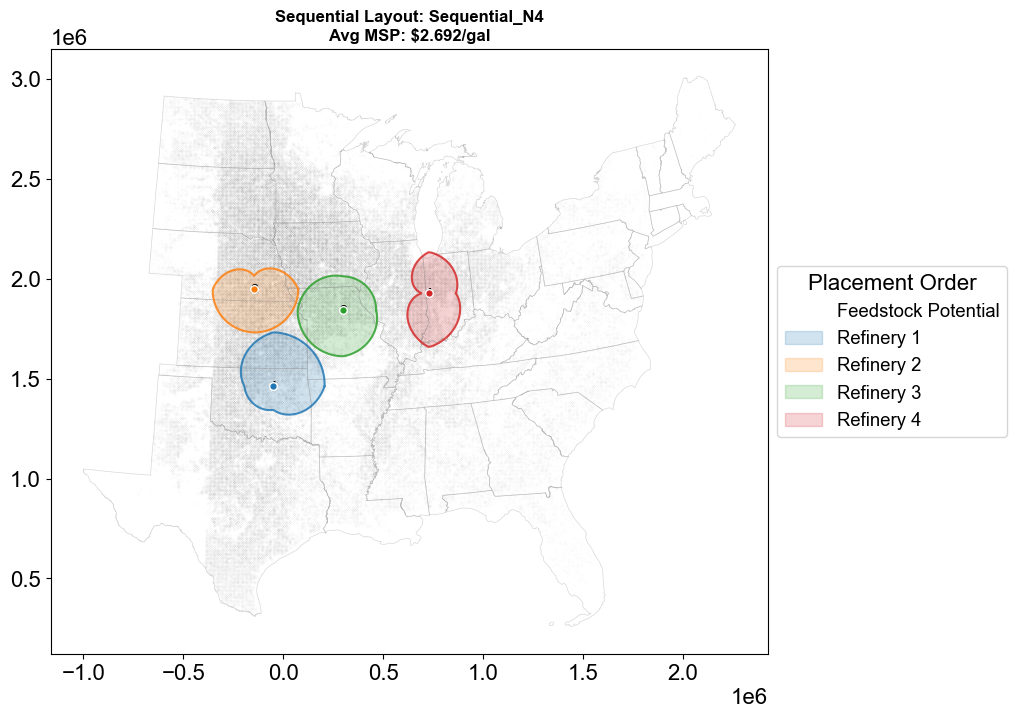

In [668]:
# 1. Transform master_results into a list that 'plot_sequential_comparative_study' understands
study_data_for_plotting = []

for n_key, data in master_results.items():
    if data['best_layout'] is not None:
        study_data_for_plotting.append({
            'N': data['config']['N'],
            'Best_Layout': data['best_layout'],
            'Best_MSP': data['best_cost'] / data['config']['N'], # Assuming best_cost is total system MSP
            'filename': f"Sequential_N{data['config']['N']}"
        })

# 2. Call your existing function
plot_sequential_comparative_study(study_data_for_plotting)

In [546]:
import os
import pickle
import numpy as np
import pandas as pd

def reload_and_analyze_sequential(folder_path="Outputs_2perc_Sim_vs_Seq"):
    all_files = [f for f in os.listdir(folder_path) if f.endswith('.pkl')]
    compiled_results = []
    summary_rows = []
    
    print(f"{'Configuration':<35} | {'N':<3} | {'Sys Avg MSP':<12} | {'Feas Rate'}")
    print("-" * 70)
    
    for fname in sorted(all_files):
        path = os.path.join(folder_path, fname)
        with open(path, 'rb') as f:
            # Sequential files use 'history' directly or as a key
            history = pickle.load(f)
            
        costs = np.array(history['costs'])
        feasibility = np.array(history['feasibility'])
        feasible_idx = np.where(feasibility == True)[0]
        
        if len(feasible_idx) > 0:
            # 1. Identify best trial based on System Total Cost
            best_idx = feasible_idx[np.argmin(costs[feasible_idx])]
            best_layout = history['results'][best_idx]
            n_val = best_layout.shape[0]
            
            # 2. Vectorized Post-Processing for the Best Layout
            x_r = best_layout
            X_norm = (x_r - X_min) / (X_max - X_min)
            
            cost_pred = predict_batch_rbf_costs(X_norm, model_costs_total, scale_costs_total, y1_min, y1_max)
            size_pred = predict_batch_rbf_size(X_norm, model_size_total, scale_size_total, y2_min, y2_max)
            areas_km2 = calculate_areas_vectorized(x_r.T, 4) / 1e6
            
            # Convert to functional units
            size_mmgal = (size_pred * areas_km2) * ethanol_conversion_factor / gal_to_MMgal
            cost_per_ton = (cost_pred * areas_km2) / (size_pred * areas_km2 * ton_to_kg)
            
            b_vals, c_vals = b_c_vectorized(x_r[:, :2])
            individual_msp = (a * cost_per_ton) + (b_vals / size_mmgal) + c_vals
            
            # System-wide metrics
            system_avg_msp = np.sum(individual_msp * size_mmgal) / np.sum(size_mmgal)
            feas_rate = (np.sum(feasibility) / len(feasibility)) * 100
            
            config_name = fname.replace('_full.pkl', '')
            print(f"{config_name[:35]:<35} | {n_val:<3} | {system_avg_msp:<12.4f} | {feas_rate:.1f}%")
            
            # 3. Store for Plotting (compatible with your existing plot functions)
            compiled_results.append({
                'filename': fname,
                'N': n_val,
                'Best_MSP': system_avg_msp,
                'Feasibility_Rate': feas_rate,
                'History': history,
                'Best_Layout': best_layout
            })
            
            # 4. Store for CSV Summary
            for i in range(n_val):
                summary_rows.append({
                    'Config': config_name,
                    'N_Total': n_val,
                    'Refinery_ID': i + 1,
                    'Size_MMgal': size_mmgal[i],
                    'Area_km2': areas_km2[i],
                    'MSP_usd_gal': individual_msp[i],
                    'System_Avg_MSP': system_avg_msp,
                    'X': x_r[i, 0],
                    'Y': x_r[i, 1]
                })

    return compiled_results, pd.DataFrame(summary_rows)

# Execute
study_data_seq, df_summary_seq = reload_and_analyze_sequential()

# Save the comprehensive CSV
df_summary_seq.to_csv("Outputs_2perc_seq/Compiled_Sequential_Analysis_target_Irr.csv", index=False)

Configuration                       | N   | Sys Avg MSP  | Feas Rate
----------------------------------------------------------------------


KeyError: 'costs'